# Functional Capstone Project - Data & Analytics



## Business Context

**Infini Telco** is a prominent player in the telco industry with a strong presence in Malaysia. Specializing in B2B sales, they serve as a vital link in the supply chain, facilitating the distribution of telecommunication and technology products to retailers, service providers, and other businesses across the continent.

Despite their market dominance and expansive product offerings, the company faces critical business challenge related to marketing strategy. A key aspect of this involves the ***identification and segmentation of their customer base into well-defined segments based on discernible patterns in product purchase behaviour and understand their product portfolio.*** By understanding the distinct needs, preferences, and purchasing habits of different customer segments, the client can develop targeted marketing strategies that cater to the specific needs of each segment, enhancing customer satisfaction and loyalty, driving revenue growth.




## Business Challenges

- No streamlined process to handle data and data is only available in chunks
- Limited intel on customer purchase patterns to drive targeted marketing
- Inadequate product insights across different customer groups


## Project Objectives

The business needs your help as a ***data analyst*** to overcome these challenges. Apply your data analytics skillset learnt.



### 1. Data Preprocessing

Data preparation is a critical process first step, involving the gathering, cleaning, transforming, and organizing of raw data into a format suitable for analysis. This step is essential for ensuring the quality and reliability of the insights derived from the data.

Here, the transaction data is provided from June 2020 to December 2022, which are stored across three separate csv files. The dataset are:

- Transactions_1.csv
- Transactions_2.csv
- Transactions_3.csv

***Task 1.1: Combine the transaction data files***

Find a way to combine the above data together into a singular dataframe, that will contain all the transactions at one place. Name this singular dataframe df_Txn_full.

In [1]:
#Import the necessary packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns
import warnings
from sklearn.cluster import KMeans
from sklearn import preprocessing
from sklearn.metrics import silhouette_score
warnings.filterwarnings("ignore")


pd.options.display.float_format = '{:.2f}'.format
pd.options.display.max_rows = 100

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Transactions_1.xlsx to Transactions_1.xlsx
Saving Transactions_2.xlsx to Transactions_2.xlsx
Saving Transactions_3.xlsx to Transactions_3.xlsx


In [3]:
# ============================================================
# Step 1: Check exact filenames
# ============================================================
print("Files in 'uploaded':")
for fname in uploaded.keys():
    print(f"  '{fname}'")

Files in 'uploaded':
  'Transactions_1.xlsx'
  'Transactions_2.xlsx'
  'Transactions_3.xlsx'


In [7]:
# ============================================================
# Load with correct filenames
# ============================================================
import io

print("Reading Transactions_1.xlsx...")
df_Txn_1 = pd.read_excel(io.BytesIO(uploaded['Transactions_1.xlsx']))
print(f"✓ Transactions_1 loaded: {df_Txn_1.shape}")

print("Reading Transactions_2.xlsx...")
df_Txn_2 = pd.read_excel(io.BytesIO(uploaded['Transactions_2.xlsx']))
print(f"✓ Transactions_2 loaded: {df_Txn_2.shape}")

print("Reading Transactions_3.xlsx...")
df_Txn_3 = pd.read_excel(io.BytesIO(uploaded['Transactions_3.xlsx']))
print(f"✓ Transactions_3 loaded: {df_Txn_3.shape}")

# Combine
df_Txn_full = pd.concat([df_Txn_1, df_Txn_2, df_Txn_3], ignore_index=True)
print(f"\n✓ df_Txn_full combined: {df_Txn_full.shape}")

Reading Transactions_1.xlsx...
✓ Transactions_1 loaded: (100000, 12)
Reading Transactions_2.xlsx...
✓ Transactions_2 loaded: (900000, 12)
Reading Transactions_3.xlsx...
✓ Transactions_3 loaded: (353671, 12)

✓ df_Txn_full combined: (1353671, 12)


In [8]:
print("\n" + "=" * 50)
print("Individual File Shapes:")
print(f"  Transactions_1 : {df_Txn_1.shape[0]:>6} rows x {df_Txn_1.shape[1]} cols")
print(f"  Transactions_2 : {df_Txn_2.shape[0]:>6} rows x {df_Txn_2.shape[1]} cols")
print(f"  Transactions_3 : {df_Txn_3.shape[0]:>6} rows x {df_Txn_3.shape[1]} cols")
print("-" * 50)
print(f"  df_Txn_full    : {df_Txn_full.shape[0]:>6} rows x {df_Txn_full.shape[1]} cols")
print("=" * 50)

print("\nColumn Names:")
print(df_Txn_full.columns.tolist())

print("\nData Types:")
print(df_Txn_full.dtypes)

print("\nFirst 5 Rows:")
df_Txn_full.head()


Individual File Shapes:
  Transactions_1 : 100000 rows x 12 cols
  Transactions_2 : 900000 rows x 12 cols
  Transactions_3 : 353671 rows x 12 cols
--------------------------------------------------
  df_Txn_full    : 1353671 rows x 12 cols

Column Names:
['INDEX', 'INVOICE_NUMBER', 'INVOICE_ITEM', 'DOCUMENT_DATE', 'CUSTOMER_NUMBER', 'Main_account', 'Main_account_name', 'Main_resposible_employee_name', 'PRODUCT', 'Position_type_order_line', 'GROSS_TURNOVER', 'AMOUNT']

Data Types:
INDEX                                     int64
INVOICE_NUMBER                            int64
INVOICE_ITEM                              int64
DOCUMENT_DATE                    datetime64[ns]
CUSTOMER_NUMBER                           int64
Main_account                              int64
Main_account_name                        object
Main_resposible_employee_name            object
PRODUCT                                  object
Position_type_order_line                 object
GROSS_TURNOVER                    

,INDEX,INVOICE_NUMBER,INVOICE_ITEM,DOCUMENT_DATE,CUSTOMER_NUMBER,Main_account,Main_account_name,Main_resposible_employee_name,PRODUCT,Position_type_order_line,GROSS_TURNOVER,AMOUNT
0,33806,124289578,10,2022-10-01,14816,14816,Customer Group_0,Responsible Employee_0,100095,ZSV,0.00,1
1,65627,124317609,230,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,0.00,1
2,65628,124317609,250,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,0.00,0
3,65629,124317609,270,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,0.00,1
4,65630,124317609,290,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,0.00,1


In [9]:
from google.colab import files

# First save the dataframe to a file
df_Txn_full.to_csv('Combined_Transactions.csv', index=False)
print(f"✓ File saved: Combined_Transactions.csv ({df_Txn_full.shape[0]} rows x {df_Txn_full.shape[1]} cols)")

# Then download it
files.download('Combined_Transactions.csv')
print("✓ Download started!")

✓ File saved: Combined_Transactions.csv (1353671 rows x 12 cols)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Download started!


***Task 1.2: Join the mapping files to the transaction data***


Mapping files contain supplementary detailed information that will be used for our analysis.
Use these mapping files to join with the above transaction data to create the master dataset <br><br>
**List of mapping files and their primary keys:**<br>
1. Customer Characteristics : to be joined on Customer Number
2. Customer Type Mapping : to be joined on Main Account ID
3. Product Category Mapping : to be joined on Product ID

To ensure that the joins are performed accurately, it is a good practice to clean up the columns upon which the join is performed.
Some recommended steps to clean up a column are:

- ensuring the values are of the same data type
- removing leading zeroes
- removing leading and trailing whitespaces etc.


***Task 1.2.1:***

Here, before, performing the joins, you have to perform an intermediary step to clean up the below columns based on the above recommended steps:

- customer_number
- Product
- Main_account
- Invoice_Number

*Hint: Check for any leading or trailing 0s or white spaces.*

In [10]:
from google.colab import files

print("Please upload the 3 mapping files:")
print("  1. Customer Characteristics")
print("  2. Customer Type Mapping")
print("  3. Product Category Mapping")
print()

uploaded_mapping = files.upload()

# Check what was uploaded
print("\n✓ Files uploaded:")
for fname in uploaded_mapping.keys():
    print(f"  - {fname}")

Please upload the 3 mapping files:
  1. Customer Characteristics
  2. Customer Type Mapping
  3. Product Category Mapping



Saving Customer Characteristics.xlsx to Customer Characteristics.xlsx
Saving Customer Type Mapping.xlsx to Customer Type Mapping.xlsx
Saving Product Categories.xlsx to Product Categories.xlsx

✓ Files uploaded:
  - Customer Characteristics.xlsx
  - Customer Type Mapping.xlsx
  - Product Categories.xlsx


In [11]:
import io

for fname, fdata in uploaded_mapping.items():
    print("=" * 60)
    print(f"File: {fname}")

    if fname.endswith('.xlsx'):
        df_temp = pd.read_excel(io.BytesIO(fdata))
    elif fname.endswith('.csv'):
        df_temp = pd.read_csv(io.BytesIO(fdata))

    print(f"Shape : {df_temp.shape}")
    print(f"Columns: {df_temp.columns.tolist()}")
    print(df_temp.head(3))
    print()

File: Customer Characteristics.xlsx
Shape : (7130, 4)
Columns: ['CUSTOMER_NAME', 'CUSTOMER_NUMBER', 'ACCOUNT_GROUP_TXT', 'CVR_Company_status']
     CUSTOMER_NAME  CUSTOMER_NUMBER ACCOUNT_GROUP_TXT CVR_Company_status
0  CUSTOMER_NAME_0            35016           Debtors             Normal
1  CUSTOMER_NAME_1            38336           Debtors             Normal
2  CUSTOMER_NAME_2            38438           Debtors             Normal

File: Customer Type Mapping.xlsx
Shape : (6855, 2)
Columns: ['Main_account_ID', 'Customer_type']
   Main_account_ID Customer_type
0            10014           A-B
1            10025           A-B
2            10033           A-B

File: Product Categories.xlsx
Shape : (210028, 4)
Columns: ['ProductID', 'ProductCategoryID', 'ProdCat2', 'ProdCat1']
     ProductID  ProductCategoryID                   ProdCat2  \
0  10001151351                739  Web Conferencing Services   
1  10000802665                739  Web Conferencing Services   
2    614529000          

In [12]:
import io

# Customer Characteristics
df_cust_char = pd.read_excel(io.BytesIO(uploaded_mapping['Customer Characteristics.xlsx']))
print(f"✓ Customer Characteristics loaded: {df_cust_char.shape}")

# Customer Type Mapping
df_cust_type = pd.read_excel(io.BytesIO(uploaded_mapping['Customer Type Mapping.xlsx']))
print(f"✓ Customer Type Mapping loaded   : {df_cust_type.shape}")

# Product Categories
df_prod_cat = pd.read_excel(io.BytesIO(uploaded_mapping['Product Categories.xlsx']))
print(f"✓ Product Categories loaded      : {df_prod_cat.shape}")

✓ Customer Characteristics loaded: (7130, 4)
✓ Customer Type Mapping loaded   : (6855, 2)
✓ Product Categories loaded      : (210028, 4)


In [13]:
print("All columns in df_Txn_full:")
for i, col in enumerate(df_Txn_full.columns.tolist()):
    print(f"  {i:>3} : '{col}'")

All columns in df_Txn_full:
    0 : 'INDEX'
    1 : 'INVOICE_NUMBER'
    2 : 'INVOICE_ITEM'
    3 : 'DOCUMENT_DATE'
    4 : 'CUSTOMER_NUMBER'
    5 : 'Main_account'
    6 : 'Main_account_name'
    7 : 'Main_resposible_employee_name'
    8 : 'PRODUCT'
    9 : 'Position_type_order_line'
   10 : 'GROSS_TURNOVER'
   11 : 'AMOUNT'


In [14]:
print("BEFORE CLEANING - Sample Values")
print("=" * 60)
for col in ['CUSTOMER_NUMBER', 'PRODUCT', 'Main_account', 'INVOICE_NUMBER']:
    print(f"\n[ {col} ]")
    print(f"  dtype  : {df_Txn_full[col].dtype}")
    print(f"  sample : {df_Txn_full[col].dropna().head(5).tolist()}")

# --- Clean df_Txn_full key columns ---
df_Txn_full['CUSTOMER_NUMBER'] = (
    df_Txn_full['CUSTOMER_NUMBER']
    .astype(str).str.strip().str.lstrip('0')
)

df_Txn_full['PRODUCT'] = (
    df_Txn_full['PRODUCT']
    .astype(str).str.strip().str.lstrip('0')
)

df_Txn_full['Main_account'] = (
    df_Txn_full['Main_account']
    .astype(str).str.strip().str.lstrip('0')
)

df_Txn_full['INVOICE_NUMBER'] = (
    df_Txn_full['INVOICE_NUMBER']
    .astype(str).str.strip().str.lstrip('0')
)

# --- Clean mapping file key columns ---

# Customer Characteristics → CUSTOMER_NUMBER
df_cust_char['CUSTOMER_NUMBER'] = (
    df_cust_char['CUSTOMER_NUMBER']
    .astype(str).str.strip().str.lstrip('0')
)

# Customer Type Mapping → Main_account_ID
df_cust_type['Main_account_ID'] = (
    df_cust_type['Main_account_ID']
    .astype(str).str.strip().str.lstrip('0')
)

# Product Categories → ProductID
df_prod_cat['ProductID'] = (
    df_prod_cat['ProductID']
    .astype(str).str.strip().str.lstrip('0')
)

print("\nAFTER CLEANING - Sample Values")
print("=" * 60)
print(f"\n[ CUSTOMER_NUMBER ] df_Txn_full : {df_Txn_full['CUSTOMER_NUMBER'].head(3).tolist()}")
print(f"[ CUSTOMER_NUMBER ] df_cust_char: {df_cust_char['CUSTOMER_NUMBER'].head(3).tolist()}")
print(f"\n[ Main_account ]    df_Txn_full : {df_Txn_full['Main_account'].head(3).tolist()}")
print(f"[ Main_account_ID ] df_cust_type: {df_cust_type['Main_account_ID'].head(3).tolist()}")
print(f"\n[ PRODUCT ]         df_Txn_full : {df_Txn_full['PRODUCT'].head(3).tolist()}")
print(f"[ ProductID ]       df_prod_cat : {df_prod_cat['ProductID'].head(3).tolist()}")

print("\n✓ Cleaning complete!")

BEFORE CLEANING - Sample Values

[ CUSTOMER_NUMBER ]
  dtype  : int64
  sample : [14816, 17566, 17566, 17566, 17566]

[ PRODUCT ]
  dtype  : object
  sample : [100095, 100095, 100095, 100095, 100095]

[ Main_account ]
  dtype  : int64
  sample : [14816, 17566, 17566, 17566, 17566]

[ INVOICE_NUMBER ]
  dtype  : int64
  sample : [124289578, 124317609, 124317609, 124317609, 124317609]

AFTER CLEANING - Sample Values

[ CUSTOMER_NUMBER ] df_Txn_full : ['14816', '17566', '17566']
[ CUSTOMER_NUMBER ] df_cust_char: ['35016', '38336', '38438']

[ Main_account ]    df_Txn_full : ['14816', '17566', '17566']
[ Main_account_ID ] df_cust_type: ['10014', '10025', '10033']

[ PRODUCT ]         df_Txn_full : ['100095', '100095', '100095']
[ ProductID ]       df_prod_cat : ['10001151351', '10000802665', '614529000']

✓ Cleaning complete!


In [15]:
df_master = pd.merge(
    df_Txn_full,
    df_cust_char,
    on='CUSTOMER_NUMBER',
    how='left'
)
print(f"After Join 1 (Customer Characteristics) : {df_master.shape}")

# Join 2: + Customer Type Mapping (on Main_account)
df_master = pd.merge(
    df_master,
    df_cust_type,
    left_on='Main_account',
    right_on='Main_account_ID',
    how='left'
)
print(f"After Join 2 (Customer Type Mapping)    : {df_master.shape}")

# Join 3: + Product Categories (on PRODUCT)
df_master = pd.merge(
    df_master,
    df_prod_cat,
    left_on='PRODUCT',
    right_on='ProductID',
    how='left'
)
print(f"After Join 3 (Product Categories)       : {df_master.shape}")

# ============================================================
# Verify join quality
# ============================================================
print("\n" + "=" * 60)
print("JOIN QUALITY CHECK")
print("=" * 60)
print(f"Total rows    : {df_master.shape[0]:>10}")
print(f"Total columns : {df_master.shape[1]:>10}")
print(f"\nUnmatched - Customer Characteristics : {df_master['CUSTOMER_NAME'].isna().sum()}")
print(f"Unmatched - Customer Type Mapping    : {df_master['Customer_type'].isna().sum()}")
print(f"Unmatched - Product Categories       : {df_master['ProdCat1'].isna().sum()}")

print("\nAll columns in df_master:")
print(df_master.columns.tolist())

print("\nFirst 3 rows:")
df_master.head(3)

After Join 1 (Customer Characteristics) : (1353671, 15)
After Join 2 (Customer Type Mapping)    : (1353671, 17)
After Join 3 (Product Categories)       : (1353671, 21)

JOIN QUALITY CHECK
Total rows    :    1353671
Total columns :         21

Unmatched - Customer Characteristics : 0
Unmatched - Customer Type Mapping    : 17656
Unmatched - Product Categories       : 2201

All columns in df_master:
['INDEX', 'INVOICE_NUMBER', 'INVOICE_ITEM', 'DOCUMENT_DATE', 'CUSTOMER_NUMBER', 'Main_account', 'Main_account_name', 'Main_resposible_employee_name', 'PRODUCT', 'Position_type_order_line', 'GROSS_TURNOVER', 'AMOUNT', 'CUSTOMER_NAME', 'ACCOUNT_GROUP_TXT', 'CVR_Company_status', 'Main_account_ID', 'Customer_type', 'ProductID', 'ProductCategoryID', 'ProdCat2', 'ProdCat1']

First 3 rows:


,INDEX,INVOICE_NUMBER,INVOICE_ITEM,DOCUMENT_DATE,CUSTOMER_NUMBER,Main_account,Main_account_name,Main_resposible_employee_name,PRODUCT,Position_type_order_line,...,AMOUNT,CUSTOMER_NAME,ACCOUNT_GROUP_TXT,CVR_Company_status,Main_account_ID,Customer_type,ProductID,ProductCategoryID,ProdCat2,ProdCat1
0,33806,124289578,10,2022-10-01,14816,14816,Customer Group_0,Responsible Employee_0,100095,ZSV,...,1,CUSTOMER_NAME_1429,Debtors,Normal,14816,KAM,100095,8.00,Music Streaming Services,Television and Entertainment
1,65627,124317609,230,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,...,1,CUSTOMER_NAME_573,Debtors,Normal,17566,A-B,100095,8.00,Music Streaming Services,Television and Entertainment
2,65628,124317609,250,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,...,0,CUSTOMER_NAME_573,Debtors,Normal,17566,A-B,100095,8.00,Music Streaming Services,Television and Entertainment


***Task 1.2.2:***

Import the mapping files and rename the dataframe:

- Customer Characteristics.csv : df_CustChar
- Customer Type Mapping.csv : df_CustType
- Product Categories.csv : df_ProdCategories

In [16]:
df_CustChar       = df_cust_char.copy()
df_CustType       = df_cust_type.copy()
df_ProdCategories = df_prod_cat.copy()

# Verify
print("✓ df_CustChar:")
print(f"  Shape  : {df_CustChar.shape}")
print(f"  Columns: {df_CustChar.columns.tolist()}")
print()

print("✓ df_CustType:")
print(f"  Shape  : {df_CustType.shape}")
print(f"  Columns: {df_CustType.columns.tolist()}")
print()

print("✓ df_ProdCategories:")
print(f"  Shape  : {df_ProdCategories.shape}")
print(f"  Columns: {df_ProdCategories.columns.tolist()}")

✓ df_CustChar:
  Shape  : (7130, 4)
  Columns: ['CUSTOMER_NAME', 'CUSTOMER_NUMBER', 'ACCOUNT_GROUP_TXT', 'CVR_Company_status']

✓ df_CustType:
  Shape  : (6855, 2)
  Columns: ['Main_account_ID', 'Customer_type']

✓ df_ProdCategories:
  Shape  : (210028, 4)
  Columns: ['ProductID', 'ProductCategoryID', 'ProdCat2', 'ProdCat1']


***Task 1.2.3:***

To perform join on the dataframes, it is important to clean the columns to ensure that the columns are free from any special characters.

- Remove any leading or trailing 0s in Customer_Number column in the df_CustChar dataframe.
- Check for duplicates in the data and remove any duplicates.
- Create a master dataframe by performing appropriate join on df_CustChar dataframe and df_Txn_full dataframe. Rename the master dataframe as df_Master.



In [17]:
print("BEFORE CLEANING:")
print(f"  df_CustChar CUSTOMER_NUMBER sample : {df_CustChar['CUSTOMER_NUMBER'].head(5).tolist()}")
print(f"  df_Txn_full CUSTOMER_NUMBER sample : {df_Txn_full['CUSTOMER_NUMBER'].head(5).tolist()}")

df_CustChar['CUSTOMER_NUMBER'] = (
    df_CustChar['CUSTOMER_NUMBER']
    .astype(str).str.strip().str.lstrip('0')
)

df_Txn_full['CUSTOMER_NUMBER'] = (
    df_Txn_full['CUSTOMER_NUMBER']
    .astype(str).str.strip().str.lstrip('0')
)

print("\nAFTER CLEANING:")
print(f"  df_CustChar CUSTOMER_NUMBER sample : {df_CustChar['CUSTOMER_NUMBER'].head(5).tolist()}")
print(f"  df_Txn_full CUSTOMER_NUMBER sample : {df_Txn_full['CUSTOMER_NUMBER'].head(5).tolist()}")


BEFORE CLEANING:
  df_CustChar CUSTOMER_NUMBER sample : ['35016', '38336', '38438', '45001', '45005']
  df_Txn_full CUSTOMER_NUMBER sample : ['14816', '17566', '17566', '17566', '17566']

AFTER CLEANING:
  df_CustChar CUSTOMER_NUMBER sample : ['35016', '38336', '38438', '45001', '45005']
  df_Txn_full CUSTOMER_NUMBER sample : ['14816', '17566', '17566', '17566', '17566']


In [18]:
print("\n" + "=" * 60)
print("DUPLICATE CHECK")
print("=" * 60)

print(f"\ndf_Txn_full  - Before: {df_Txn_full.shape[0]:>10} rows")
dup_txn = df_Txn_full.duplicated().sum()
print(f"df_Txn_full  - Duplicates found: {dup_txn}")
df_Txn_full = df_Txn_full.drop_duplicates().reset_index(drop=True)
print(f"df_Txn_full  - After : {df_Txn_full.shape[0]:>10} rows")

print(f"\ndf_CustChar  - Before: {df_CustChar.shape[0]:>10} rows")
dup_cust = df_CustChar.duplicated().sum()
print(f"df_CustChar  - Duplicates found: {dup_cust}")
df_CustChar = df_CustChar.drop_duplicates().reset_index(drop=True)
print(f"df_CustChar  - After : {df_CustChar.shape[0]:>10} rows")


DUPLICATE CHECK

df_Txn_full  - Before:    1353671 rows
df_Txn_full  - Duplicates found: 0
df_Txn_full  - After :    1353671 rows

df_CustChar  - Before:       7130 rows
df_CustChar  - Duplicates found: 0
df_CustChar  - After :       7130 rows


In [19]:
print("\n" + "=" * 60)
print("JOIN: df_Txn_full + df_CustChar → df_Master")
print("=" * 60)

df_Master = pd.merge(
    df_Txn_full,
    df_CustChar,
    on='CUSTOMER_NUMBER',
    how='left'
)



JOIN: df_Txn_full + df_CustChar → df_Master


In [20]:
print(f"\ndf_Txn_full shape : {df_Txn_full.shape}")
print(f"df_CustChar shape : {df_CustChar.shape}")
print(f"df_Master shape   : {df_Master.shape}")

print(f"\nUnmatched rows (no customer info) : {df_Master['CUSTOMER_NAME'].isna().sum()}")

print("\nColumns in df_Master:")
print(df_Master.columns.tolist())

print("\nFirst 3 rows:")
df_Master.head(3)


df_Txn_full shape : (1353671, 12)
df_CustChar shape : (7130, 4)
df_Master shape   : (1353671, 15)

Unmatched rows (no customer info) : 0

Columns in df_Master:
['INDEX', 'INVOICE_NUMBER', 'INVOICE_ITEM', 'DOCUMENT_DATE', 'CUSTOMER_NUMBER', 'Main_account', 'Main_account_name', 'Main_resposible_employee_name', 'PRODUCT', 'Position_type_order_line', 'GROSS_TURNOVER', 'AMOUNT', 'CUSTOMER_NAME', 'ACCOUNT_GROUP_TXT', 'CVR_Company_status']

First 3 rows:


,INDEX,INVOICE_NUMBER,INVOICE_ITEM,DOCUMENT_DATE,CUSTOMER_NUMBER,Main_account,Main_account_name,Main_resposible_employee_name,PRODUCT,Position_type_order_line,GROSS_TURNOVER,AMOUNT,CUSTOMER_NAME,ACCOUNT_GROUP_TXT,CVR_Company_status
0,33806,124289578,10,2022-10-01,14816,14816,Customer Group_0,Responsible Employee_0,100095,ZSV,0.00,1,CUSTOMER_NAME_1429,Debtors,Normal
1,65627,124317609,230,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,0.00,1,CUSTOMER_NAME_573,Debtors,Normal
2,65628,124317609,250,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,0.00,0,CUSTOMER_NAME_573,Debtors,Normal


***Task 1.2.4:***

There is a data validation check point here. This is to ensure that you have not lost any data in the data preparation step.
Check and validate:

- Gross Annual Turnover is ~$1.4B
- The total customer base is ~7k

In [21]:
print("=" * 60)
print("DATA VALIDATION CHECKPOINT")
print("=" * 60)

DATA VALIDATION CHECKPOINT


In [22]:
gross_turnover = df_Master['GROSS_TURNOVER'].sum()
print(f"\nCHECK 1: Gross Annual Turnover")
print(f"  Actual   : ${gross_turnover:,.2f}")
print(f"  Expected : ~$1,400,000,000 (~$1.4B)")

if 1_300_000_000 <= gross_turnover <= 1_500_000_000:
    print("  Status   : PASS")
else:
    print("  Status   : FAIL - investigate!")


CHECK 1: Gross Annual Turnover
  Actual   : $1,466,478,196.72
  Expected : ~$1,400,000,000 (~$1.4B)
  Status   : PASS


In [23]:
total_customers = df_Master['CUSTOMER_NUMBER'].nunique()
print(f"\nCHECK 2: Total Customer Base")
print(f"  Actual   : {total_customers:,}")
print(f"  Expected : ~7,000")

if 6_000 <= total_customers <= 8_000:
    print("  Status   : PASS")
else:
    print("  Status   : FAIL - investigate!")


CHECK 2: Total Customer Base
  Actual   : 7,130
  Expected : ~7,000
  Status   : PASS


In [24]:
print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"  Total Rows       : {df_Master.shape[0]:>12,}")
print(f"  Total Columns    : {df_Master.shape[1]:>12,}")
print(f"  Gross Turnover   : ${gross_turnover:>14,.2f}")
print(f"  Unique Customers : {total_customers:>12,}")
print(f"  Date Range       : {df_Master['DOCUMENT_DATE'].min()} to {df_Master['DOCUMENT_DATE'].max()}")


SUMMARY
  Total Rows       :    1,353,671
  Total Columns    :           15
  Gross Turnover   : $1,466,478,196.72
  Unique Customers :        7,130
  Date Range       : 2020-06-23 00:00:00 to 2022-12-31 00:00:00


***Task 1.2.5:***

Now, you will be joining the df_CustType dataframe with the master dataframe.

- Remove any leading or trailing 0s in Main_account_ID column in the df_CustType dataframe.
- Check for duplicates in the data and remove any duplicates.
- Perform appropriate join on df_CustType dataframe and df_Master dataframe and save this merged dataframe as df_Master.

In [25]:
print("BEFORE CLEANING:")
print(f"  df_CustType Main_account_ID sample : {df_CustType['Main_account_ID'].head(5).tolist()}")
print(f"  df_Master   Main_account sample    : {df_Master['Main_account'].head(5).tolist()}")

df_CustType['Main_account_ID'] = (
    df_CustType['Main_account_ID']
    .astype(str).str.strip().str.lstrip('0')
)

df_Master['Main_account'] = (
    df_Master['Main_account']
    .astype(str).str.strip().str.lstrip('0')
)

print("\nAFTER CLEANING:")
print(f"  df_CustType Main_account_ID sample : {df_CustType['Main_account_ID'].head(5).tolist()}")
print(f"  df_Master   Main_account sample    : {df_Master['Main_account'].head(5).tolist()}")


BEFORE CLEANING:
  df_CustType Main_account_ID sample : ['10014', '10025', '10033', '10048', '10056']
  df_Master   Main_account sample    : ['14816', '17566', '17566', '17566', '17566']

AFTER CLEANING:
  df_CustType Main_account_ID sample : ['10014', '10025', '10033', '10048', '10056']
  df_Master   Main_account sample    : ['14816', '17566', '17566', '17566', '17566']


In [26]:
print("\n" + "=" * 60)
print("DUPLICATE CHECK")
print("=" * 60)

print(f"\ndf_Master   - Before : {df_Master.shape[0]:>10,} rows")
dup_master = df_Master.duplicated().sum()
print(f"df_Master   - Duplicates found: {dup_master}")
df_Master = df_Master.drop_duplicates().reset_index(drop=True)
print(f"df_Master   - After  : {df_Master.shape[0]:>10,} rows")

print(f"\ndf_CustType - Before : {df_CustType.shape[0]:>10,} rows")
dup_custtype = df_CustType.duplicated().sum()
print(f"df_CustType - Duplicates found: {dup_custtype}")
df_CustType = df_CustType.drop_duplicates().reset_index(drop=True)
print(f"df_CustType - After  : {df_CustType.shape[0]:>10,} rows")


DUPLICATE CHECK

df_Master   - Before :  1,353,671 rows
df_Master   - Duplicates found: 0
df_Master   - After  :  1,353,671 rows

df_CustType - Before :      6,855 rows
df_CustType - Duplicates found: 0
df_CustType - After  :      6,855 rows


In [27]:
print("\n" + "=" * 60)
print("JOIN: df_Master + df_CustType → df_Master")
print("=" * 60)

df_Master = pd.merge(
    df_Master,
    df_CustType,
    left_on='Main_account',
    right_on='Main_account_ID',
    how='left'
)



JOIN: df_Master + df_CustType → df_Master


In [28]:
print(f"\ndf_Master shape  : {df_Master.shape}")
print(f"Unmatched rows   : {df_Master['Customer_type'].isna().sum():,}")
print(f"Customer_type distribution:")
print(df_Master['Customer_type'].value_counts(dropna=False))

print("\nColumns in df_Master:")
print(df_Master.columns.tolist())

print("\nFirst 3 rows:")
df_Master.head(3)


df_Master shape  : (1353671, 17)
Unmatched rows   : 17,656
Customer_type distribution:
Customer_type
A-B    861011
KAM    296639
D       93600
C       84765
NaN     17656
Name: count, dtype: int64

Columns in df_Master:
['INDEX', 'INVOICE_NUMBER', 'INVOICE_ITEM', 'DOCUMENT_DATE', 'CUSTOMER_NUMBER', 'Main_account', 'Main_account_name', 'Main_resposible_employee_name', 'PRODUCT', 'Position_type_order_line', 'GROSS_TURNOVER', 'AMOUNT', 'CUSTOMER_NAME', 'ACCOUNT_GROUP_TXT', 'CVR_Company_status', 'Main_account_ID', 'Customer_type']

First 3 rows:


,INDEX,INVOICE_NUMBER,INVOICE_ITEM,DOCUMENT_DATE,CUSTOMER_NUMBER,Main_account,Main_account_name,Main_resposible_employee_name,PRODUCT,Position_type_order_line,GROSS_TURNOVER,AMOUNT,CUSTOMER_NAME,ACCOUNT_GROUP_TXT,CVR_Company_status,Main_account_ID,Customer_type
0,33806,124289578,10,2022-10-01,14816,14816,Customer Group_0,Responsible Employee_0,100095,ZSV,0.00,1,CUSTOMER_NAME_1429,Debtors,Normal,14816,KAM
1,65627,124317609,230,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,0.00,1,CUSTOMER_NAME_573,Debtors,Normal,17566,A-B
2,65628,124317609,250,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,0.00,0,CUSTOMER_NAME_573,Debtors,Normal,17566,A-B


***Task 1.2.6:***

There is a data validation check point here. This is to ensure that you have not lost any data in the data preparation step.
Check and validate:

- Gross Annual Turnover is ~$1.4B
- The total customer base is ~7k

In [29]:
print("=" * 60)
print("DATA VALIDATION CHECKPOINT")
print("=" * 60)

DATA VALIDATION CHECKPOINT


In [30]:
gross_turnover = df_Master['GROSS_TURNOVER'].sum()
print(f"\nCHECK 1: Gross Annual Turnover")
print(f"  Actual   : ${gross_turnover:,.2f}")
print(f"  Expected : ~$1,400,000,000 (~$1.4B)")

if 1_300_000_000 <= gross_turnover <= 1_500_000_000:
    print("  Status   : PASS")
else:
    print("  Status   : FAIL - investigate!")


CHECK 1: Gross Annual Turnover
  Actual   : $1,466,478,196.72
  Expected : ~$1,400,000,000 (~$1.4B)
  Status   : PASS


In [31]:
total_customers = df_Master['CUSTOMER_NUMBER'].nunique()
print(f"\nCHECK 2: Total Customer Base")
print(f"  Actual   : {total_customers:,}")
print(f"  Expected : ~7,000")

if 6_000 <= total_customers <= 8_000:
    print("  Status   : PASS")
else:
    print("  Status   : FAIL - investigate!")


CHECK 2: Total Customer Base
  Actual   : 7,130
  Expected : ~7,000
  Status   : PASS


In [32]:
print(f"\nCHECK 3: Row Count Integrity")
print(f"  df_Master rows : {df_Master.shape[0]:>10,}")
print(f"  Expected       :      1,353,671")

if df_Master.shape[0] == 1_353_671:
    print("  Status   : PASS")
else:
    print("  Status   : FAIL - rows changed after join!")



CHECK 3: Row Count Integrity
  df_Master rows :  1,353,671
  Expected       :      1,353,671
  Status   : PASS


In [33]:
print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"  Total Rows       : {df_Master.shape[0]:>12,}")
print(f"  Total Columns    : {df_Master.shape[1]:>12,}")
print(f"  Gross Turnover   : ${gross_turnover:>14,.2f}")
print(f"  Unique Customers : {total_customers:>12,}")
print(f"  Date Range       : {df_Master['DOCUMENT_DATE'].min()} to {df_Master['DOCUMENT_DATE'].max()}")


SUMMARY
  Total Rows       :    1,353,671
  Total Columns    :           17
  Gross Turnover   : $1,466,478,196.72
  Unique Customers :        7,130
  Date Range       : 2020-06-23 00:00:00 to 2022-12-31 00:00:00


***Task 1.2.7:***

Now, you will be joining the df_ProdCategories dataframe with the master dataframe.

- Remove any leading or trailing 0s in ProductID column in the df_ProdCategories dataframe.
- Check for duplicates in the data and remove any duplicates.
- Perform appropriate join on df_ProdCategories dataframe and df_Master dataframe and save this merged dataframe as df_Master.

In [34]:
# ============================================================
# TASK 1.2.7: Clean, Deduplicate & Join df_ProdCategories → df_Master
# ============================================================

# --- Step 1: Clean ProductID in df_ProdCategories ---
print("BEFORE CLEANING:")
print(f"  df_ProdCategories ProductID sample : {df_ProdCategories['ProductID'].head(5).tolist()}")
print(f"  df_Master         PRODUCT sample   : {df_Master['PRODUCT'].head(5).tolist()}")

df_ProdCategories['ProductID'] = (
    df_ProdCategories['ProductID']
    .astype(str).str.strip().str.lstrip('0')
)

df_Master['PRODUCT'] = (
    df_Master['PRODUCT']
    .astype(str).str.strip().str.lstrip('0')
)

print("\nAFTER CLEANING:")
print(f"  df_ProdCategories ProductID sample : {df_ProdCategories['ProductID'].head(5).tolist()}")
print(f"  df_Master         PRODUCT sample   : {df_Master['PRODUCT'].head(5).tolist()}")

# --- Step 2: Check & Remove Duplicates ---
print("\n" + "=" * 60)
print("DUPLICATE CHECK")
print("=" * 60)

print(f"\ndf_Master         - Before : {df_Master.shape[0]:>10,} rows")
dup_master = df_Master.duplicated().sum()
print(f"df_Master         - Duplicates found: {dup_master}")
df_Master = df_Master.drop_duplicates().reset_index(drop=True)
print(f"df_Master         - After  : {df_Master.shape[0]:>10,} rows")

print(f"\ndf_ProdCategories - Before : {df_ProdCategories.shape[0]:>10,} rows")
dup_prod = df_ProdCategories.duplicated().sum()
print(f"df_ProdCategories - Duplicates found: {dup_prod}")
df_ProdCategories = df_ProdCategories.drop_duplicates().reset_index(drop=True)
print(f"df_ProdCategories - After  : {df_ProdCategories.shape[0]:>10,} rows")

# --- Step 3: Join df_Master + df_ProdCategories → df_Master ---
print("\n" + "=" * 60)
print("JOIN: df_Master + df_ProdCategories → df_Master")
print("=" * 60)

df_Master = pd.merge(
    df_Master,
    df_ProdCategories,
    left_on='PRODUCT',
    right_on='ProductID',
    how='left'
)

# --- Step 4: Verify ---
print(f"\ndf_Master shape  : {df_Master.shape}")
print(f"Unmatched rows   : {df_Master['ProdCat1'].isna().sum():,}")

print(f"\nProdCat1 distribution:")
print(df_Master['ProdCat1'].value_counts(dropna=False).head(10))

print(f"\nProdCat2 distribution:")
print(df_Master['ProdCat2'].value_counts(dropna=False).head(10))

print("\nColumns in df_Master:")
print(df_Master.columns.tolist())

print("\nFirst 3 rows:")
df_Master.head(3)

BEFORE CLEANING:
  df_ProdCategories ProductID sample : ['10001151351', '10000802665', '614529000', '617092230', '605040414']
  df_Master         PRODUCT sample   : ['100095', '100095', '100095', '100095', '100095']

AFTER CLEANING:
  df_ProdCategories ProductID sample : ['10001151351', '10000802665', '614529000', '617092230', '605040414']
  df_Master         PRODUCT sample   : ['100095', '100095', '100095', '100095', '100095']

DUPLICATE CHECK

df_Master         - Before :  1,353,671 rows
df_Master         - Duplicates found: 0
df_Master         - After  :  1,353,671 rows

df_ProdCategories - Before :    210,028 rows
df_ProdCategories - Duplicates found: 0
df_ProdCategories - After  :    210,028 rows

JOIN: df_Master + df_ProdCategories → df_Master

df_Master shape  : (1353671, 21)
Unmatched rows   : 2,201

ProdCat1 distribution:
ProdCat1
Network and Infrastructure         247663
Television and Entertainment       220922
Mobile Services                    208994
Business Solutions    

,INDEX,INVOICE_NUMBER,INVOICE_ITEM,DOCUMENT_DATE,CUSTOMER_NUMBER,Main_account,Main_account_name,Main_resposible_employee_name,PRODUCT,Position_type_order_line,...,AMOUNT,CUSTOMER_NAME,ACCOUNT_GROUP_TXT,CVR_Company_status,Main_account_ID,Customer_type,ProductID,ProductCategoryID,ProdCat2,ProdCat1
0,33806,124289578,10,2022-10-01,14816,14816,Customer Group_0,Responsible Employee_0,100095,ZSV,...,1,CUSTOMER_NAME_1429,Debtors,Normal,14816,KAM,100095,8.00,Music Streaming Services,Television and Entertainment
1,65627,124317609,230,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,...,1,CUSTOMER_NAME_573,Debtors,Normal,17566,A-B,100095,8.00,Music Streaming Services,Television and Entertainment
2,65628,124317609,250,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,...,0,CUSTOMER_NAME_573,Debtors,Normal,17566,A-B,100095,8.00,Music Streaming Services,Television and Entertainment


***Task 1.2.8:***

There is a data validation check point here. This is to ensure that you have not lost any data in the data preparation step.
Check and validate:

- Gross Annual Turnover is ~$1.4B
- The total customer base is ~7k
- The total product is ~15k

In [35]:
# ============================================================
# TASK 1.2.8: Data Validation Checkpoint
# ============================================================

print("=" * 60)
print("DATA VALIDATION CHECKPOINT")
print("=" * 60)

# --- Check 1: Gross Annual Turnover ---
gross_turnover = df_Master['GROSS_TURNOVER'].sum()
print(f"\nCHECK 1: Gross Annual Turnover")
print(f"  Actual   : ${gross_turnover:,.2f}")
print(f"  Expected : ~$1,400,000,000 (~$1.4B)")
if 1_300_000_000 <= gross_turnover <= 1_500_000_000:
    print("  Status   : PASS")
else:
    print("  Status   : FAIL - investigate!")

# --- Check 2: Total Customer Base ---
total_customers = df_Master['CUSTOMER_NUMBER'].nunique()
print(f"\nCHECK 2: Total Customer Base")
print(f"  Actual   : {total_customers:,}")
print(f"  Expected : ~7,000")
if 6_000 <= total_customers <= 8_000:
    print("  Status   : PASS")
else:
    print("  Status   : FAIL - investigate!")

# --- Check 3: Total Products ---
total_products = df_Master['PRODUCT'].nunique()
print(f"\nCHECK 3: Total Products")
print(f"  Actual   : {total_products:,}")
print(f"  Expected : ~15,000")
if 13_000 <= total_products <= 17_000:
    print("  Status   : PASS")
else:
    print("  Status   : FAIL - investigate!")

# --- Check 4: Row Count Unchanged ---
print(f"\nCHECK 4: Row Count Integrity")
print(f"  Actual   : {df_Master.shape[0]:>10,}")
print(f"  Expected :  1,353,671")
if df_Master.shape[0] == 1_353_671:
    print("  Status   : PASS")
else:
    print("  Status   : FAIL - rows changed after join!")

# --- Summary ---
print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"  Total Rows          : {df_Master.shape[0]:>12,}")
print(f"  Total Columns       : {df_Master.shape[1]:>12,}")
print(f"  Gross Turnover      : ${gross_turnover:>14,.2f}")
print(f"  Unique Customers    : {total_customers:>12,}")
print(f"  Unique Products     : {total_products:>12,}")
print(f"  Date Range          : {df_Master['DOCUMENT_DATE'].min()} to {df_Master['DOCUMENT_DATE'].max()}")
print(f"\nProduct Category (ProdCat1) Distribution:")
print(df_Master['ProdCat1'].value_counts(dropna=False).head(10))

DATA VALIDATION CHECKPOINT

CHECK 1: Gross Annual Turnover
  Actual   : $1,466,478,196.72
  Expected : ~$1,400,000,000 (~$1.4B)
  Status   : PASS

CHECK 2: Total Customer Base
  Actual   : 7,130
  Expected : ~7,000
  Status   : PASS

CHECK 3: Total Products
  Actual   : 150,545
  Expected : ~15,000
  Status   : FAIL - investigate!

CHECK 4: Row Count Integrity
  Actual   :  1,353,671
  Expected :  1,353,671
  Status   : PASS

SUMMARY
  Total Rows          :    1,353,671
  Total Columns       :           21
  Gross Turnover      : $1,466,478,196.72
  Unique Customers    :        7,130
  Unique Products     :      150,545
  Date Range          : 2020-06-23 00:00:00 to 2022-12-31 00:00:00

Product Category (ProdCat1) Distribution:
ProdCat1
Network and Infrastructure         247663
Television and Entertainment       220922
Mobile Services                    208994
Business Solutions                 116374
Cloud and Hosting Services         102517
Digital Transformation Services     84377
S

***Task 1.3: Data Cleaning***

A major part of data pre processing involves cleaning the data, removing nulls, filtering out irrelavant or less useful information. For example:

- Remove rows with missing product id
- Removing rows with negative or zero turnover
- Removing customers who interacted very less

As part of Data Cleaning of this dataset you are required to perform the following:

***Task 1.3.1: In the df_Master data, add a column Invoice_flag, reflecting 0 if number of transactions <= 3, otherwise 1***

This is to flag customers who purchase less frequently

In [36]:
# ============================================================
# TASK 1.3.1: Add Invoice_flag column
# Flag customers with <= 3 transactions as 0, otherwise 1
# ============================================================

# --- Step 1: Count transactions per customer ---
txn_count = df_Master.groupby('CUSTOMER_NUMBER')['INVOICE_NUMBER'].count().reset_index()
txn_count.columns = ['CUSTOMER_NUMBER', 'Txn_Count']

print("Transaction count distribution:")
print(txn_count['Txn_Count'].describe())
print(f"\nCustomers with <= 3 transactions : {(txn_count['Txn_Count'] <= 3).sum():,}")
print(f"Customers with  > 3 transactions : {(txn_count['Txn_Count'] >  3).sum():,}")

# --- Step 2: Map flag back to df_Master ---
df_Master = pd.merge(df_Master, txn_count, on='CUSTOMER_NUMBER', how='left')

df_Master['Invoice_flag'] = df_Master['Txn_Count'].apply(lambda x: 0 if x <= 3 else 1)

# --- Step 3: Verify ---
print("\n" + "=" * 60)
print("INVOICE FLAG DISTRIBUTION")
print("=" * 60)
print(f"\nInvoice_flag value counts:")
print(df_Master['Invoice_flag'].value_counts())
print(f"\nInvoice_flag = 0 (<=3 txns) rows : {(df_Master['Invoice_flag'] == 0).sum():>10,}")
print(f"Invoice_flag = 1 ( >3 txns) rows : {(df_Master['Invoice_flag'] == 1).sum():>10,}")
print(f"\nTotal rows unchanged             : {df_Master.shape[0]:>10,}")
print(f"Total columns                    : {df_Master.shape[1]:>10,}")

print("\nSample - Customers with Invoice_flag = 0:")
print(df_Master[df_Master['Invoice_flag'] == 0][['CUSTOMER_NUMBER', 'INVOICE_NUMBER', 'Txn_Count', 'Invoice_flag']].head(3))

print("\nSample - Customers with Invoice_flag = 1:")
print(df_Master[df_Master['Invoice_flag'] == 1][['CUSTOMER_NUMBER', 'INVOICE_NUMBER', 'Txn_Count', 'Invoice_flag']].head(3))

df_Master.head(3)

Transaction count distribution:
count    7130.00
mean      189.86
std       860.30
min         1.00
25%         4.00
50%        19.00
75%        94.00
max     50251.00
Name: Txn_Count, dtype: float64

Customers with <= 3 transactions : 1,523
Customers with  > 3 transactions : 5,607

INVOICE FLAG DISTRIBUTION

Invoice_flag value counts:
Invoice_flag
1    1350986
0       2685
Name: count, dtype: int64

Invoice_flag = 0 (<=3 txns) rows :      2,685
Invoice_flag = 1 ( >3 txns) rows :  1,350,986

Total rows unchanged             :  1,353,671
Total columns                    :         23

Sample - Customers with Invoice_flag = 0:
    CUSTOMER_NUMBER INVOICE_NUMBER  Txn_Count  Invoice_flag
243           21332      123940879          3             0
269           15146      124912845          1             0
679           16495      124203429          3             0

Sample - Customers with Invoice_flag = 1:
  CUSTOMER_NUMBER INVOICE_NUMBER  Txn_Count  Invoice_flag
0           14816      1242

,INDEX,INVOICE_NUMBER,INVOICE_ITEM,DOCUMENT_DATE,CUSTOMER_NUMBER,Main_account,Main_account_name,Main_resposible_employee_name,PRODUCT,Position_type_order_line,...,ACCOUNT_GROUP_TXT,CVR_Company_status,Main_account_ID,Customer_type,ProductID,ProductCategoryID,ProdCat2,ProdCat1,Txn_Count,Invoice_flag
0,33806,124289578,10,2022-10-01,14816,14816,Customer Group_0,Responsible Employee_0,100095,ZSV,...,Debtors,Normal,14816,KAM,100095,8.00,Music Streaming Services,Television and Entertainment,147,1
1,65627,124317609,230,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,...,Debtors,Normal,17566,A-B,100095,8.00,Music Streaming Services,Television and Entertainment,4117,1
2,65628,124317609,250,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,...,Debtors,Normal,17566,A-B,100095,8.00,Music Streaming Services,Television and Entertainment,4117,1


***Task 1.3.2: In the df_Master data, add a column Invoice_flag, reflecting 0 if number of transactions <= 3, otherwise 1***

This is to flag customers who purchase single SKU.

In [37]:
# ============================================================
# TASK 1.3.2: Add SKU_flag column
# Flag customers who purchase only a single unique SKU as 0, otherwise 1
# ============================================================

# --- Step 1: Count unique SKUs per customer ---
sku_count = df_Master.groupby('CUSTOMER_NUMBER')['PRODUCT'].nunique().reset_index()
sku_count.columns = ['CUSTOMER_NUMBER', 'SKU_Count']

print("Unique SKU count distribution per customer:")
print(sku_count['SKU_Count'].describe())
print(f"\nCustomers with only 1 unique SKU : {(sku_count['SKU_Count'] == 1).sum():,}")
print(f"Customers with  > 1 unique SKU   : {(sku_count['SKU_Count'] >  1).sum():,}")

# --- Step 2: Map flag back to df_Master ---
df_Master = pd.merge(df_Master, sku_count, on='CUSTOMER_NUMBER', how='left')

df_Master['SKU_flag'] = df_Master['SKU_Count'].apply(lambda x: 0 if x == 1 else 1)

# --- Step 3: Verify ---
print("\n" + "=" * 60)
print("SKU FLAG DISTRIBUTION")
print("=" * 60)
print(f"\nSKU_flag value counts:")
print(df_Master['SKU_flag'].value_counts())
print(f"\nSKU_flag = 0 (single SKU) rows : {(df_Master['SKU_flag'] == 0).sum():>10,}")
print(f"SKU_flag = 1 (multi  SKU) rows : {(df_Master['SKU_flag'] == 1).sum():>10,}")
print(f"\nTotal rows unchanged           : {df_Master.shape[0]:>10,}")
print(f"Total columns                  : {df_Master.shape[1]:>10,}")

print("\nSample - Customers with SKU_flag = 0 (single SKU):")
print(df_Master[df_Master['SKU_flag'] == 0][['CUSTOMER_NUMBER', 'PRODUCT', 'SKU_Count', 'SKU_flag']].head(3))

print("\nSample - Customers with SKU_flag = 1 (multiple SKUs):")
print(df_Master[df_Master['SKU_flag'] == 1][['CUSTOMER_NUMBER', 'PRODUCT', 'SKU_Count', 'SKU_flag']].head(3))

df_Master.head(3)

Unique SKU count distribution per customer:
count   7130.00
mean     115.42
std      339.33
min        1.00
25%        4.00
50%       16.00
75%       73.00
max     9402.00
Name: SKU_Count, dtype: float64

Customers with only 1 unique SKU : 842
Customers with  > 1 unique SKU   : 6,288

SKU FLAG DISTRIBUTION

SKU_flag value counts:
SKU_flag
1    1352458
0       1213
Name: count, dtype: int64

SKU_flag = 0 (single SKU) rows :      1,213
SKU_flag = 1 (multi  SKU) rows :  1,352,458

Total rows unchanged           :  1,353,671
Total columns                  :         25

Sample - Customers with SKU_flag = 0 (single SKU):
     CUSTOMER_NUMBER     PRODUCT  SKU_Count  SKU_flag
269            15146  4380000118          1         0
2366           10117  2774910089          1         0
3360           10267  8736108304          1         0

Sample - Customers with SKU_flag = 1 (multiple SKUs):
  CUSTOMER_NUMBER PRODUCT  SKU_Count  SKU_flag
0           14816  100095        121         1
1           

,INDEX,INVOICE_NUMBER,INVOICE_ITEM,DOCUMENT_DATE,CUSTOMER_NUMBER,Main_account,Main_account_name,Main_resposible_employee_name,PRODUCT,Position_type_order_line,...,Main_account_ID,Customer_type,ProductID,ProductCategoryID,ProdCat2,ProdCat1,Txn_Count,Invoice_flag,SKU_Count,SKU_flag
0,33806,124289578,10,2022-10-01,14816,14816,Customer Group_0,Responsible Employee_0,100095,ZSV,...,14816,KAM,100095,8.00,Music Streaming Services,Television and Entertainment,147,1,121,1
1,65627,124317609,230,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,...,17566,A-B,100095,8.00,Music Streaming Services,Television and Entertainment,4117,1,2061,1
2,65628,124317609,250,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,...,17566,A-B,100095,8.00,Music Streaming Services,Television and Entertainment,4117,1,2061,1


There are a few records in the dataset whose Product ID are null. These records won't map to product information from the mapping file and hence these records will not be useful for the analysis.

***Task 1.3.3: In the master data, remove records where Product ID is null and save it in a dataframe df_Filtered***

In [38]:
# ============================================================
# TASK 1.3.3: Remove records where Product ID is null
# Save as df_Filtered
# ============================================================

# --- Step 1: Check nulls in ProductID before filtering ---
print("BEFORE FILTERING:")
print(f"  df_Master shape          : {df_Master.shape}")
print(f"  Null ProductID rows      : {df_Master['ProductID'].isna().sum():,}")
print(f"  Null PRODUCT rows        : {df_Master['PRODUCT'].isna().sum():,}")

# --- Step 2: Remove rows where ProductID is null ---
df_Filtered = df_Master[df_Master['ProductID'].notna()].reset_index(drop=True)

# --- Step 3: Verify ---
print("\nAFTER FILTERING:")
print(f"  df_Filtered shape        : {df_Filtered.shape}")
print(f"  Rows removed             : {df_Master.shape[0] - df_Filtered.shape[0]:,}")
print(f"  Null ProductID remaining : {df_Filtered['ProductID'].isna().sum():,}")

# --- Step 4: Validate key metrics still intact ---
gross_turnover  = df_Filtered['GROSS_TURNOVER'].sum()
total_customers = df_Filtered['CUSTOMER_NUMBER'].nunique()
total_products  = df_Filtered['PRODUCT'].nunique()

print("\n" + "=" * 60)
print("VALIDATION AFTER FILTERING")
print("=" * 60)
print(f"  Total Rows          : {df_Filtered.shape[0]:>12,}")
print(f"  Total Columns       : {df_Filtered.shape[1]:>12,}")
print(f"  Gross Turnover      : ${gross_turnover:>14,.2f}")
print(f"  Unique Customers    : {total_customers:>12,}")
print(f"  Unique Products     : {total_products:>12,}")
print(f"  Date Range          : {df_Filtered['DOCUMENT_DATE'].min()} to {df_Filtered['DOCUMENT_DATE'].max()}")

df_Filtered.head(3)

BEFORE FILTERING:
  df_Master shape          : (1353671, 25)
  Null ProductID rows      : 2,201
  Null PRODUCT rows        : 0

AFTER FILTERING:
  df_Filtered shape        : (1351470, 25)
  Rows removed             : 2,201
  Null ProductID remaining : 0

VALIDATION AFTER FILTERING
  Total Rows          :    1,351,470
  Total Columns       :           25
  Gross Turnover      : $1,465,676,361.60
  Unique Customers    :        7,100
  Unique Products     :      150,417
  Date Range          : 2020-06-23 00:00:00 to 2022-12-31 00:00:00


,INDEX,INVOICE_NUMBER,INVOICE_ITEM,DOCUMENT_DATE,CUSTOMER_NUMBER,Main_account,Main_account_name,Main_resposible_employee_name,PRODUCT,Position_type_order_line,...,Main_account_ID,Customer_type,ProductID,ProductCategoryID,ProdCat2,ProdCat1,Txn_Count,Invoice_flag,SKU_Count,SKU_flag
0,33806,124289578,10,2022-10-01,14816,14816,Customer Group_0,Responsible Employee_0,100095,ZSV,...,14816,KAM,100095,8.00,Music Streaming Services,Television and Entertainment,147,1,121,1
1,65627,124317609,230,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,...,17566,A-B,100095,8.00,Music Streaming Services,Television and Entertainment,4117,1,2061,1
2,65628,124317609,250,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,...,17566,A-B,100095,8.00,Music Streaming Services,Television and Entertainment,4117,1,2061,1


There are a few records that lack information on product category and will not be useful for the analysis

***Task 1.3.4: In the df_Filtered dataftame, remove records where Product Category information is null***


In [39]:
# ============================================================
# TASK 1.3.4: Remove records where Product Category is null
# ============================================================

# --- Step 1: Check nulls in Product Category columns before filtering ---
print("BEFORE FILTERING:")
print(f"  df_Filtered shape        : {df_Filtered.shape}")
print(f"  Null ProdCat1 rows       : {df_Filtered['ProdCat1'].isna().sum():,}")
print(f"  Null ProdCat2 rows       : {df_Filtered['ProdCat2'].isna().sum():,}")
print(f"  Null ProductCategoryID   : {df_Filtered['ProductCategoryID'].isna().sum():,}")

# --- Step 2: Remove rows where Product Category info is null ---
df_Filtered = df_Filtered[
    df_Filtered['ProdCat1'].notna() &
    df_Filtered['ProdCat2'].notna() &
    df_Filtered['ProductCategoryID'].notna()
].reset_index(drop=True)

# --- Step 3: Verify ---
print("\nAFTER FILTERING:")
print(f"  df_Filtered shape        : {df_Filtered.shape}")
print(f"  Rows removed             : {1_351_470 - df_Filtered.shape[0]:,}")
print(f"  Null ProdCat1 remaining  : {df_Filtered['ProdCat1'].isna().sum():,}")
print(f"  Null ProdCat2 remaining  : {df_Filtered['ProdCat2'].isna().sum():,}")
print(f"  Null ProdCatID remaining : {df_Filtered['ProductCategoryID'].isna().sum():,}")

# --- Step 4: Validate key metrics ---
gross_turnover  = df_Filtered['GROSS_TURNOVER'].sum()
total_customers = df_Filtered['CUSTOMER_NUMBER'].nunique()
total_products  = df_Filtered['PRODUCT'].nunique()

print("\n" + "=" * 60)
print("VALIDATION AFTER FILTERING")
print("=" * 60)
print(f"  Total Rows          : {df_Filtered.shape[0]:>12,}")
print(f"  Total Columns       : {df_Filtered.shape[1]:>12,}")
print(f"  Gross Turnover      : ${gross_turnover:>14,.2f}")
print(f"  Unique Customers    : {total_customers:>12,}")
print(f"  Unique Products     : {total_products:>12,}")
print(f"  Date Range          : {df_Filtered['DOCUMENT_DATE'].min()} to {df_Filtered['DOCUMENT_DATE'].max()}")

print("\nProdCat1 Distribution:")
print(df_Filtered['ProdCat1'].value_counts(dropna=False).head(10))

df_Filtered.head(3)

BEFORE FILTERING:
  df_Filtered shape        : (1351470, 25)
  Null ProdCat1 rows       : 0
  Null ProdCat2 rows       : 0
  Null ProductCategoryID   : 0

AFTER FILTERING:
  df_Filtered shape        : (1351470, 25)
  Rows removed             : 0
  Null ProdCat1 remaining  : 0
  Null ProdCat2 remaining  : 0
  Null ProdCatID remaining : 0

VALIDATION AFTER FILTERING
  Total Rows          :    1,351,470
  Total Columns       :           25
  Gross Turnover      : $1,465,676,361.60
  Unique Customers    :        7,100
  Unique Products     :      150,417
  Date Range          : 2020-06-23 00:00:00 to 2022-12-31 00:00:00

ProdCat1 Distribution:
ProdCat1
Network and Infrastructure         247663
Television and Entertainment       220922
Mobile Services                    208994
Business Solutions                 116374
Cloud and Hosting Services         102517
Digital Transformation Services     84377
Security and Privacy                58963
Devices and Accessories             54707
Data an

,INDEX,INVOICE_NUMBER,INVOICE_ITEM,DOCUMENT_DATE,CUSTOMER_NUMBER,Main_account,Main_account_name,Main_resposible_employee_name,PRODUCT,Position_type_order_line,...,Main_account_ID,Customer_type,ProductID,ProductCategoryID,ProdCat2,ProdCat1,Txn_Count,Invoice_flag,SKU_Count,SKU_flag
0,33806,124289578,10,2022-10-01,14816,14816,Customer Group_0,Responsible Employee_0,100095,ZSV,...,14816,KAM,100095,8.00,Music Streaming Services,Television and Entertainment,147,1,121,1
1,65627,124317609,230,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,...,17566,A-B,100095,8.00,Music Streaming Services,Television and Entertainment,4117,1,2061,1
2,65628,124317609,250,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,...,17566,A-B,100095,8.00,Music Streaming Services,Television and Entertainment,4117,1,2061,1


There are some sales made to Internal accounts in the dataset. These sales can be removed from analysis as information on internal sales can distort the analysis of customer behaviour. Internal transactions do not reflect the actual market demand or customer preferences.

***Task 1.3.5: In the df_Filtered dataframe, remove records pertaining to sales to Internal Account***

*Hint: Check for Internal accounts in Account_Group_TXT field*

In [40]:
# ============================================================
# TASK 1.3.5: Remove Internal Account records
# ============================================================

# --- Step 1: Check unique values in ACCOUNT_GROUP_TXT ---
print("Unique values in ACCOUNT_GROUP_TXT:")
print(df_Filtered['ACCOUNT_GROUP_TXT'].value_counts(dropna=False))

Unique values in ACCOUNT_GROUP_TXT:
ACCOUNT_GROUP_TXT
Debtors              1351081
Internal accounts        389
Name: count, dtype: int64


As per business requirement, sales made to "ZSKA" and "ZDIR" are requested to be removed.

***Task 1.3.6: In the df_Filtered dataframe, remove records with position types "ZSKA" and "ZDIR"***

*Hint: Check column Position_type_order_line*

In [41]:
# ============================================================
# TASK 1.3.5: Remove Internal Account records
# ============================================================

print("BEFORE FILTERING (Task 1.3.5):")
print(f"  df_Filtered shape          : {df_Filtered.shape}")
print(f"  Internal accounts rows     : {(df_Filtered['ACCOUNT_GROUP_TXT'] == 'Internal accounts').sum():,}")

# Remove Internal accounts
df_Filtered = df_Filtered[
    df_Filtered['ACCOUNT_GROUP_TXT'] != 'Internal accounts'
].reset_index(drop=True)

print("\nAFTER FILTERING (Task 1.3.5):")
print(f"  df_Filtered shape          : {df_Filtered.shape}")
print(f"  Internal accounts remaining: {(df_Filtered['ACCOUNT_GROUP_TXT'] == 'Internal accounts').sum():,}")
print(f"  ACCOUNT_GROUP_TXT values   :")
print(df_Filtered['ACCOUNT_GROUP_TXT'].value_counts(dropna=False))

# ============================================================
# TASK 1.3.6: Remove records with position types ZSKA and ZDIR
# ============================================================

print("\n" + "=" * 60)
print("BEFORE FILTERING (Task 1.3.6):")
print(f"  df_Filtered shape          : {df_Filtered.shape}")
print(f"\n  Position_type_order_line values:")
print(df_Filtered['Position_type_order_line'].value_counts(dropna=False))

# Remove ZSKA and ZDIR
df_Filtered = df_Filtered[
    ~df_Filtered['Position_type_order_line'].isin(['ZSKA', 'ZDIR'])
].reset_index(drop=True)

print("\nAFTER FILTERING (Task 1.3.6):")
print(f"  df_Filtered shape          : {df_Filtered.shape}")
print(f"\n  Position_type_order_line remaining:")
print(df_Filtered['Position_type_order_line'].value_counts(dropna=False))

# --- Final Validation ---
gross_turnover  = df_Filtered['GROSS_TURNOVER'].sum()
total_customers = df_Filtered['CUSTOMER_NUMBER'].nunique()
total_products  = df_Filtered['PRODUCT'].nunique()

print("\n" + "=" * 60)
print("VALIDATION AFTER TASKS 1.3.5 & 1.3.6")
print("=" * 60)
print(f"  Total Rows       : {df_Filtered.shape[0]:>12,}")
print(f"  Total Columns    : {df_Filtered.shape[1]:>12,}")
print(f"  Gross Turnover   : ${gross_turnover:>14,.2f}")
print(f"  Unique Customers : {total_customers:>12,}")
print(f"  Unique Products  : {total_products:>12,}")
print(f"  Date Range       : {df_Filtered['DOCUMENT_DATE'].min()} to {df_Filtered['DOCUMENT_DATE'].max()}")

df_Filtered.head(3)

BEFORE FILTERING (Task 1.3.5):
  df_Filtered shape          : (1351470, 25)
  Internal accounts rows     : 389

AFTER FILTERING (Task 1.3.5):
  df_Filtered shape          : (1351081, 25)
  Internal accounts remaining: 0
  ACCOUNT_GROUP_TXT values   :
ACCOUNT_GROUP_TXT
Debtors    1351081
Name: count, dtype: int64

BEFORE FILTERING (Task 1.3.6):
  df_Filtered shape          : (1351081, 25)

  Position_type_order_line values:
Position_type_order_line
ZLAG    929093
ZDIS    132815
ZKSK    114855
ZENO     66460
ZSKA     36589
ZDIR     12038
ZAFH     10257
ZSRP      9925
ZKSC      9108
ZSV       4721
ZSSC      4175
ZKON      3276
ZPRO      3042
ZDRE      2778
ZRMA      2599
ZGRA      1493
ZRKU      1384
ZKOR       847
ZSTK       846
ZREO       827
ZROK       570
ZSRS       489
ZSK        417
ZGKS       341
ZZLA       316
ZROU       293
ZKRE       276
ZREG       222
ZGSK       186
ZKOU       164
ZARM       119
ZSUB       105
ZDIX        92
ZZSR        87
ZUBG        70
ZGNO        64
ZGAF    

,INDEX,INVOICE_NUMBER,INVOICE_ITEM,DOCUMENT_DATE,CUSTOMER_NUMBER,Main_account,Main_account_name,Main_resposible_employee_name,PRODUCT,Position_type_order_line,...,Main_account_ID,Customer_type,ProductID,ProductCategoryID,ProdCat2,ProdCat1,Txn_Count,Invoice_flag,SKU_Count,SKU_flag
0,33806,124289578,10,2022-10-01,14816,14816,Customer Group_0,Responsible Employee_0,100095,ZSV,...,14816,KAM,100095,8.00,Music Streaming Services,Television and Entertainment,147,1,121,1
1,65627,124317609,230,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,...,17566,A-B,100095,8.00,Music Streaming Services,Television and Entertainment,4117,1,2061,1
2,65628,124317609,250,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,...,17566,A-B,100095,8.00,Music Streaming Services,Television and Entertainment,4117,1,2061,1


Some companies are currently not active or are in normal operation. It makes sense to exclude these companies from analysis. But, for companies whose status is unknown (null/na), we still retain them.

***Task 1.3.7: In the df_Filtered dataframe, remove records whose company status are not active/normal***

*Hint: Check column CVR_Company_status*

In [42]:
# ============================================================
# TASK 1.3.7: Check CVR_Company_status values first
# ============================================================

print("Unique values in CVR_Company_status:")
print(df_Filtered['CVR_Company_status'].value_counts(dropna=False))

Unique values in CVR_Company_status:
CVR_Company_status
Normal      1089575
Active       128547
NaN           81778
Inactive       2554
Name: count, dtype: int64


There might be some records where Gross Turnover is zero or negative. These records might indicate product returns/invalid entries and should be excluded from the analysis.

***Task 1.3.8: In the df_Filtered dataframe, remove records where Gross Turnover is zero or negative***

In [43]:
# ============================================================
# TASK 1.3.7: Remove records with inactive company status
# Keep: Normal, Active, and NaN (unknown)
# Remove: Inactive
# ============================================================

print("BEFORE FILTERING (Task 1.3.7):")
print(f"  df_Filtered shape     : {df_Filtered.shape}")
print(f"  Inactive rows         : {(df_Filtered['CVR_Company_status'] == 'Inactive').sum():,}")

# Remove only Inactive — keep Normal, Active, and NaN
df_Filtered = df_Filtered[
    df_Filtered['CVR_Company_status'] != 'Inactive'
].reset_index(drop=True)

print("\nAFTER FILTERING (Task 1.3.7):")
print(f"  df_Filtered shape     : {df_Filtered.shape}")
print(f"  Rows removed          : {1_302_454 - df_Filtered.shape[0]:,}")
print(f"\n  CVR_Company_status remaining:")
print(df_Filtered['CVR_Company_status'].value_counts(dropna=False))

# ============================================================
# TASK 1.3.8: Remove records where Gross Turnover <= 0
# ============================================================

print("\n" + "=" * 60)
print("BEFORE FILTERING (Task 1.3.8):")
print(f"  df_Filtered shape     : {df_Filtered.shape}")
print(f"  Zero turnover rows    : {(df_Filtered['GROSS_TURNOVER'] == 0).sum():,}")
print(f"  Negative turnover rows: {(df_Filtered['GROSS_TURNOVER'] < 0).sum():,}")
print(f"  Total to remove       : {(df_Filtered['GROSS_TURNOVER'] <= 0).sum():,}")

print(f"\n  GROSS_TURNOVER distribution:")
print(df_Filtered['GROSS_TURNOVER'].describe())

# Remove zero and negative turnover
df_Filtered = df_Filtered[
    df_Filtered['GROSS_TURNOVER'] > 0
].reset_index(drop=True)

print("\nAFTER FILTERING (Task 1.3.8):")
print(f"  df_Filtered shape     : {df_Filtered.shape}")
print(f"  Zero/Neg remaining    : {(df_Filtered['GROSS_TURNOVER'] <= 0).sum():,}")

# --- Final Validation ---
gross_turnover  = df_Filtered['GROSS_TURNOVER'].sum()
total_customers = df_Filtered['CUSTOMER_NUMBER'].nunique()
total_products  = df_Filtered['PRODUCT'].nunique()

print("\n" + "=" * 60)
print("VALIDATION AFTER TASKS 1.3.7 & 1.3.8")
print("=" * 60)
print(f"  Total Rows       : {df_Filtered.shape[0]:>12,}")
print(f"  Total Columns    : {df_Filtered.shape[1]:>12,}")
print(f"  Gross Turnover   : ${gross_turnover:>14,.2f}")
print(f"  Unique Customers : {total_customers:>12,}")
print(f"  Unique Products  : {total_products:>12,}")
print(f"  Date Range       : {df_Filtered['DOCUMENT_DATE'].min()} to {df_Filtered['DOCUMENT_DATE'].max()}")
print(f"\n  CVR_Company_status distribution:")
print(df_Filtered['CVR_Company_status'].value_counts(dropna=False))

df_Filtered.head(3)

BEFORE FILTERING (Task 1.3.7):
  df_Filtered shape     : (1302454, 25)
  Inactive rows         : 2,554

AFTER FILTERING (Task 1.3.7):
  df_Filtered shape     : (1299900, 25)
  Rows removed          : 2,554

  CVR_Company_status remaining:
CVR_Company_status
Normal    1089575
Active     128547
NaN         81778
Name: count, dtype: int64

BEFORE FILTERING (Task 1.3.8):
  df_Filtered shape     : (1299900, 25)
  Zero turnover rows    : 11,856
  Negative turnover rows: 17,493
  Total to remove       : 29,349

  GROSS_TURNOVER distribution:
count   1299900.00
mean        998.44
std        4628.67
min     -258547.03
25%          95.47
50%         258.98
75%         742.98
max      958998.14
Name: GROSS_TURNOVER, dtype: float64

AFTER FILTERING (Task 1.3.8):
  df_Filtered shape     : (1270551, 25)
  Zero/Neg remaining    : 0

VALIDATION AFTER TASKS 1.3.7 & 1.3.8
  Total Rows       :    1,270,551
  Total Columns    :           25
  Gross Turnover   : $1,324,855,328.65
  Unique Customers :      

,INDEX,INVOICE_NUMBER,INVOICE_ITEM,DOCUMENT_DATE,CUSTOMER_NUMBER,Main_account,Main_account_name,Main_resposible_employee_name,PRODUCT,Position_type_order_line,...,Main_account_ID,Customer_type,ProductID,ProductCategoryID,ProdCat2,ProdCat1,Txn_Count,Invoice_flag,SKU_Count,SKU_flag
0,47154,124195645,10,2022-09-09,15082,103350,Customer Group_24,Responsible Employee_17,5737657492,ZLAG,...,103350,A-B,5737657492,605.00,Cloud Strategy and Migration,Digital Transformation Services,4100,1,2009,1
1,47184,124167744,70,2022-09-07,15082,103350,Customer Group_24,Responsible Employee_17,4441429746,ZLAG,...,103350,A-B,4441429746,686.00,Predictive Analytics,Data and Analytics,4100,1,2009,1
2,47455,123658470,100,2022-06-13,15082,103350,Customer Group_24,Responsible Employee_17,4289348828,ZLAG,...,103350,A-B,4289348828,660.00,Video Conferencing Services,Communication Tools,4100,1,2009,1


There might be some records where Amount is zero or negative. These records might indicate product returns/invalid entries and should be excluded from the analysis.

***Task 1.3.9: In the df_Filtered dataframe, remove records where Amount is zero or negative***


In [44]:
# ============================================================
# TASK 1.3.9: Remove records where Amount is zero or negative
# ============================================================

print("BEFORE FILTERING (Task 1.3.9):")
print(f"  df_Filtered shape     : {df_Filtered.shape}")
print(f"  Zero amount rows      : {(df_Filtered['AMOUNT'] == 0).sum():,}")
print(f"  Negative amount rows  : {(df_Filtered['AMOUNT'] < 0).sum():,}")
print(f"  Total to remove       : {(df_Filtered['AMOUNT'] <= 0).sum():,}")
print(f"\n  AMOUNT distribution:")
print(df_Filtered['AMOUNT'].describe())

# Remove zero and negative amount
df_Filtered = df_Filtered[
    df_Filtered['AMOUNT'] > 0
].reset_index(drop=True)

print("\nAFTER FILTERING (Task 1.3.9):")
print(f"  df_Filtered shape     : {df_Filtered.shape}")
print(f"  Rows removed          : {1_270_551 - df_Filtered.shape[0]:,}")
print(f"  Zero/Neg remaining    : {(df_Filtered['AMOUNT'] <= 0).sum():,}")

# --- Final Validation ---
gross_turnover  = df_Filtered['GROSS_TURNOVER'].sum()
total_customers = df_Filtered['CUSTOMER_NUMBER'].nunique()
total_products  = df_Filtered['PRODUCT'].nunique()

print("\n" + "=" * 60)
print("VALIDATION AFTER TASK 1.3.9")
print("=" * 60)
print(f"  Total Rows       : {df_Filtered.shape[0]:>12,}")
print(f"  Total Columns    : {df_Filtered.shape[1]:>12,}")
print(f"  Gross Turnover   : ${gross_turnover:>14,.2f}")
print(f"  Unique Customers : {total_customers:>12,}")
print(f"  Unique Products  : {total_products:>12,}")
print(f"  Date Range       : {df_Filtered['DOCUMENT_DATE'].min()} to {df_Filtered['DOCUMENT_DATE'].max()}")
print(f"\n  AMOUNT distribution after filtering:")
print(df_Filtered['AMOUNT'].describe())

df_Filtered.head(3)

BEFORE FILTERING (Task 1.3.9):
  df_Filtered shape     : (1270551, 25)
  Zero amount rows      : 189,472
  Negative amount rows  : 34
  Total to remove       : 189,506

  AMOUNT distribution:
count   1270551.00
mean         80.77
std         784.60
min        -227.00
25%           1.00
50%           3.00
75%          15.00
max      248000.00
Name: AMOUNT, dtype: float64

AFTER FILTERING (Task 1.3.9):
  df_Filtered shape     : (1081045, 25)
  Rows removed          : 189,506
  Zero/Neg remaining    : 0

VALIDATION AFTER TASK 1.3.9
  Total Rows       :    1,081,045
  Total Columns    :           25
  Gross Turnover   : $1,222,205,407.39
  Unique Customers :        6,686
  Unique Products  :      112,207
  Date Range       : 2020-07-10 00:00:00 to 2022-12-30 00:00:00

  AMOUNT distribution after filtering:
count   1081045.00
mean         94.93
std         849.81
min           1.00
25%           1.00
50%           5.00
75%          22.00
max      248000.00
Name: AMOUNT, dtype: float64


,INDEX,INVOICE_NUMBER,INVOICE_ITEM,DOCUMENT_DATE,CUSTOMER_NUMBER,Main_account,Main_account_name,Main_resposible_employee_name,PRODUCT,Position_type_order_line,...,Main_account_ID,Customer_type,ProductID,ProductCategoryID,ProdCat2,ProdCat1,Txn_Count,Invoice_flag,SKU_Count,SKU_flag
0,47154,124195645,10,2022-09-09,15082,103350,Customer Group_24,Responsible Employee_17,5737657492,ZLAG,...,103350,A-B,5737657492,605.00,Cloud Strategy and Migration,Digital Transformation Services,4100,1,2009,1
1,47184,124167744,70,2022-09-07,15082,103350,Customer Group_24,Responsible Employee_17,4441429746,ZLAG,...,103350,A-B,4441429746,686.00,Predictive Analytics,Data and Analytics,4100,1,2009,1
2,47455,123658470,100,2022-06-13,15082,103350,Customer Group_24,Responsible Employee_17,4289348828,ZLAG,...,103350,A-B,4289348828,660.00,Video Conferencing Services,Communication Tools,4100,1,2009,1


Remember, you had created a column to flag the customers whose number of transactions are 3 or less than that. Customers with very few transactions may introduce noise into the data, making it harder to identify meaningful patterns and trends. Filtering out these customers results in a cleaner dataset, which enhances the accuracy and reliability of the analysis.

***Task 1.3.10: In the df_Filtered dataframe, filter out customers who have made 3 or fewer transactions***

*Hint: Utilize the Invoice_flag column created earlier.*

In [45]:
# ============================================================
# TASK 1.3.10: Filter out customers with <= 3 transactions
# Using Invoice_flag column (0 = <= 3 transactions)
# ============================================================

print("BEFORE FILTERING (Task 1.3.10):")
print(f"  df_Filtered shape          : {df_Filtered.shape}")
print(f"\n  Invoice_flag distribution:")
print(df_Filtered['Invoice_flag'].value_counts(dropna=False))
print(f"\n  Rows to remove (flag = 0)  : {(df_Filtered['Invoice_flag'] == 0).sum():,}")
print(f"  Rows to keep   (flag = 1)  : {(df_Filtered['Invoice_flag'] == 1).sum():,}")

# Keep only customers with Invoice_flag = 1 (> 3 transactions)
df_Filtered = df_Filtered[
    df_Filtered['Invoice_flag'] == 1
].reset_index(drop=True)

print("\nAFTER FILTERING (Task 1.3.10):")
print(f"  df_Filtered shape          : {df_Filtered.shape}")
print(f"  Rows removed               : {1_081_045 - df_Filtered.shape[0]:,}")
print(f"  Invoice_flag = 0 remaining : {(df_Filtered['Invoice_flag'] == 0).sum():,}")

# --- Final Validation ---
gross_turnover  = df_Filtered['GROSS_TURNOVER'].sum()
total_customers = df_Filtered['CUSTOMER_NUMBER'].nunique()
total_products  = df_Filtered['PRODUCT'].nunique()

print("\n" + "=" * 60)
print("VALIDATION AFTER TASK 1.3.10")
print("=" * 60)
print(f"  Total Rows       : {df_Filtered.shape[0]:>12,}")
print(f"  Total Columns    : {df_Filtered.shape[1]:>12,}")
print(f"  Gross Turnover   : ${gross_turnover:>14,.2f}")
print(f"  Unique Customers : {total_customers:>12,}")
print(f"  Unique Products  : {total_products:>12,}")
print(f"  Date Range       : {df_Filtered['DOCUMENT_DATE'].min()} to {df_Filtered['DOCUMENT_DATE'].max()}")
print(f"\n  Transaction count distribution of remaining customers:")
print(df_Filtered.groupby('CUSTOMER_NUMBER')['INVOICE_NUMBER'].count().describe())

df_Filtered.head(3)

BEFORE FILTERING (Task 1.3.10):
  df_Filtered shape          : (1081045, 25)

  Invoice_flag distribution:
Invoice_flag
1    1079218
0       1827
Name: count, dtype: int64

  Rows to remove (flag = 0)  : 1,827
  Rows to keep   (flag = 1)  : 1,079,218

AFTER FILTERING (Task 1.3.10):
  df_Filtered shape          : (1079218, 25)
  Rows removed               : 1,827
  Invoice_flag = 0 remaining : 0

VALIDATION AFTER TASK 1.3.10
  Total Rows       :    1,079,218
  Total Columns    :           25
  Gross Turnover   : $1,217,786,206.40
  Unique Customers :        5,507
  Unique Products  :      112,037
  Date Range       : 2020-07-29 00:00:00 to 2022-12-30 00:00:00

  Transaction count distribution of remaining customers:
count    5507.00
mean      195.97
std       816.24
min         1.00
25%         8.00
50%        29.00
75%       122.00
max     43647.00
Name: INVOICE_NUMBER, dtype: float64


,INDEX,INVOICE_NUMBER,INVOICE_ITEM,DOCUMENT_DATE,CUSTOMER_NUMBER,Main_account,Main_account_name,Main_resposible_employee_name,PRODUCT,Position_type_order_line,...,Main_account_ID,Customer_type,ProductID,ProductCategoryID,ProdCat2,ProdCat1,Txn_Count,Invoice_flag,SKU_Count,SKU_flag
0,47154,124195645,10,2022-09-09,15082,103350,Customer Group_24,Responsible Employee_17,5737657492,ZLAG,...,103350,A-B,5737657492,605.00,Cloud Strategy and Migration,Digital Transformation Services,4100,1,2009,1
1,47184,124167744,70,2022-09-07,15082,103350,Customer Group_24,Responsible Employee_17,4441429746,ZLAG,...,103350,A-B,4441429746,686.00,Predictive Analytics,Data and Analytics,4100,1,2009,1
2,47455,123658470,100,2022-06-13,15082,103350,Customer Group_24,Responsible Employee_17,4289348828,ZLAG,...,103350,A-B,4289348828,660.00,Video Conferencing Services,Communication Tools,4100,1,2009,1


You had also created a column to flag the customers who purchased only one sku. Such records in the data also tends to add noise and is necesary to filter these customers out.

***Task 1.3.11: In the df_Filtered dataframe, filter out customers who have purchased only a single SKU***

*Hint: Utilize the SKU_flag column created earlier.*

In [46]:
# ============================================================
# TASK 1.3.11: Filter out customers who purchased only 1 SKU
# Using SKU_flag column (0 = single SKU, 1 = multiple SKUs)
# ============================================================

print("BEFORE FILTERING (Task 1.3.11):")
print(f"  df_Filtered shape          : {df_Filtered.shape}")
print(f"\n  SKU_flag distribution:")
print(df_Filtered['SKU_flag'].value_counts(dropna=False))
print(f"\n  Rows to remove (flag = 0)  : {(df_Filtered['SKU_flag'] == 0).sum():,}")
print(f"  Rows to keep   (flag = 1)  : {(df_Filtered['SKU_flag'] == 1).sum():,}")

# Keep only customers with SKU_flag = 1 (multiple SKUs)
df_Filtered = df_Filtered[
    df_Filtered['SKU_flag'] == 1
].reset_index(drop=True)

print("\nAFTER FILTERING (Task 1.3.11):")
print(f"  df_Filtered shape          : {df_Filtered.shape}")
print(f"  Rows removed               : {1_079_218 - df_Filtered.shape[0]:,}")
print(f"  SKU_flag = 0 remaining     : {(df_Filtered['SKU_flag'] == 0).sum():,}")

# --- Final Validation ---
gross_turnover  = df_Filtered['GROSS_TURNOVER'].sum()
total_customers = df_Filtered['CUSTOMER_NUMBER'].nunique()
total_products  = df_Filtered['PRODUCT'].nunique()

print("\n" + "=" * 60)
print("VALIDATION AFTER TASK 1.3.11")
print("=" * 60)
print(f"  Total Rows       : {df_Filtered.shape[0]:>12,}")
print(f"  Total Columns    : {df_Filtered.shape[1]:>12,}")
print(f"  Gross Turnover   : ${gross_turnover:>14,.2f}")
print(f"  Unique Customers : {total_customers:>12,}")
print(f"  Unique Products  : {total_products:>12,}")
print(f"  Date Range       : {df_Filtered['DOCUMENT_DATE'].min()} to {df_Filtered['DOCUMENT_DATE'].max()}")
print(f"\n  SKU count distribution of remaining customers:")
print(df_Filtered.groupby('CUSTOMER_NUMBER')['PRODUCT'].nunique().describe())

df_Filtered.head(3)

BEFORE FILTERING (Task 1.3.11):
  df_Filtered shape          : (1079218, 25)

  SKU_flag distribution:
SKU_flag
1    1079005
0        213
Name: count, dtype: int64

  Rows to remove (flag = 0)  : 213
  Rows to keep   (flag = 1)  : 1,079,005

AFTER FILTERING (Task 1.3.11):
  df_Filtered shape          : (1079005, 25)
  Rows removed               : 213
  SKU_flag = 0 remaining     : 0

VALIDATION AFTER TASK 1.3.11
  Total Rows       :    1,079,005
  Total Columns    :           25
  Gross Turnover   : $1,216,712,683.77
  Unique Customers :        5,491
  Unique Products  :      112,036
  Date Range       : 2020-07-29 00:00:00 to 2022-12-30 00:00:00

  SKU count distribution of remaining customers:
count   5491.00
mean     121.32
std      312.09
min        1.00
25%        7.50
50%       24.00
75%       92.00
max     7696.00
Name: PRODUCT, dtype: float64


,INDEX,INVOICE_NUMBER,INVOICE_ITEM,DOCUMENT_DATE,CUSTOMER_NUMBER,Main_account,Main_account_name,Main_resposible_employee_name,PRODUCT,Position_type_order_line,...,Main_account_ID,Customer_type,ProductID,ProductCategoryID,ProdCat2,ProdCat1,Txn_Count,Invoice_flag,SKU_Count,SKU_flag
0,47154,124195645,10,2022-09-09,15082,103350,Customer Group_24,Responsible Employee_17,5737657492,ZLAG,...,103350,A-B,5737657492,605.00,Cloud Strategy and Migration,Digital Transformation Services,4100,1,2009,1
1,47184,124167744,70,2022-09-07,15082,103350,Customer Group_24,Responsible Employee_17,4441429746,ZLAG,...,103350,A-B,4441429746,686.00,Predictive Analytics,Data and Analytics,4100,1,2009,1
2,47455,123658470,100,2022-06-13,15082,103350,Customer Group_24,Responsible Employee_17,4289348828,ZLAG,...,103350,A-B,4289348828,660.00,Video Conferencing Services,Communication Tools,4100,1,2009,1


There are some information from the business and the business aligned on the fact that some very large customers are outliers and having them in the data could skew the analysis results. Hence, they should be filtered out. These customer types are denoted by KAM (Key Account Management).

***Task 1.3.12: In the df_Filtered dataframe, Filter out "Key" customer accounts***

*Hint: Check Customer_type column*

In [47]:
# ============================================================
# TASK 1.3.12: Filter out KAM (Key Account Management) customers
# ============================================================

print("BEFORE FILTERING (Task 1.3.12):")
print(f"  df_Filtered shape          : {df_Filtered.shape}")
print(f"\n  Customer_type distribution:")
print(df_Filtered['Customer_type'].value_counts(dropna=False))
print(f"\n  KAM rows to remove         : {(df_Filtered['Customer_type'] == 'KAM').sum():,}")

# Remove KAM customers
df_Filtered = df_Filtered[
    df_Filtered['Customer_type'] != 'KAM'
].reset_index(drop=True)

print("\nAFTER FILTERING (Task 1.3.12):")
print(f"  df_Filtered shape          : {df_Filtered.shape}")
print(f"  Rows removed               : {1_079_005 - df_Filtered.shape[0]:,}")
print(f"\n  Customer_type remaining:")
print(df_Filtered['Customer_type'].value_counts(dropna=False))

# --- Final Validation ---
gross_turnover  = df_Filtered['GROSS_TURNOVER'].sum()
total_customers = df_Filtered['CUSTOMER_NUMBER'].nunique()
total_products  = df_Filtered['PRODUCT'].nunique()

print("\n" + "=" * 60)
print("VALIDATION AFTER TASK 1.3.12")
print("=" * 60)
print(f"  Total Rows       : {df_Filtered.shape[0]:>12,}")
print(f"  Total Columns    : {df_Filtered.shape[1]:>12,}")
print(f"  Gross Turnover   : ${gross_turnover:>14,.2f}")
print(f"  Unique Customers : {total_customers:>12,}")
print(f"  Unique Products  : {total_products:>12,}")
print(f"  Date Range       : {df_Filtered['DOCUMENT_DATE'].min()} to {df_Filtered['DOCUMENT_DATE'].max()}")

df_Filtered.head(3)

BEFORE FILTERING (Task 1.3.12):
  df_Filtered shape          : (1079005, 25)

  Customer_type distribution:
Customer_type
A-B    696036
KAM    236657
D       71099
C       67434
NaN      7779
Name: count, dtype: int64

  KAM rows to remove         : 236,657

AFTER FILTERING (Task 1.3.12):
  df_Filtered shape          : (842348, 25)
  Rows removed               : 236,657

  Customer_type remaining:
Customer_type
A-B    696036
D       71099
C       67434
NaN      7779
Name: count, dtype: int64

VALIDATION AFTER TASK 1.3.12
  Total Rows       :      842,348
  Total Columns    :           25
  Gross Turnover   : $934,607,058.55
  Unique Customers :        5,064
  Unique Products  :       99,149
  Date Range       : 2020-07-29 00:00:00 to 2022-12-30 00:00:00


,INDEX,INVOICE_NUMBER,INVOICE_ITEM,DOCUMENT_DATE,CUSTOMER_NUMBER,Main_account,Main_account_name,Main_resposible_employee_name,PRODUCT,Position_type_order_line,...,Main_account_ID,Customer_type,ProductID,ProductCategoryID,ProdCat2,ProdCat1,Txn_Count,Invoice_flag,SKU_Count,SKU_flag
0,47154,124195645,10,2022-09-09,15082,103350,Customer Group_24,Responsible Employee_17,5737657492,ZLAG,...,103350,A-B,5737657492,605.00,Cloud Strategy and Migration,Digital Transformation Services,4100,1,2009,1
1,47184,124167744,70,2022-09-07,15082,103350,Customer Group_24,Responsible Employee_17,4441429746,ZLAG,...,103350,A-B,4441429746,686.00,Predictive Analytics,Data and Analytics,4100,1,2009,1
2,47455,123658470,100,2022-06-13,15082,103350,Customer Group_24,Responsible Employee_17,4289348828,ZLAG,...,103350,A-B,4289348828,660.00,Video Conferencing Services,Communication Tools,4100,1,2009,1


**With the above steps of data preprocessing, you now get a cleaned data set which will be used for further analysis.**

### 2. Data Transformation


***Task 2.1: Based on what you have learnt previously, perform a series of standard EDA to gain a better understanding of the data***

1. DATASET OVERVIEW
  Total Rows             :  1,353,671
  Total Columns          :         12
  Date Range             : 2020-06-23 00:00:00 to 2022-12-31 00:00:00
  Unique Customers       :      7,130
  Total Gross Turnover   : $1,466,478,196.72

  Null Values per Column:
CVR_Company_status    84130
Customer_type         17656
ProductID              2201
ProductCategoryID      2201
ProdCat2               2201
ProdCat1               2201
dtype: int64

  Descriptive Statistics:
       GROSS_TURNOVER     AMOUNT
count      1353671.00 1353671.00
mean          1083.33      77.72
std           5054.83     795.81
min        -258547.03 -192060.00
25%             98.12       1.00
50%            269.34       3.00
75%            783.20      13.00
max         958998.14  248000.00


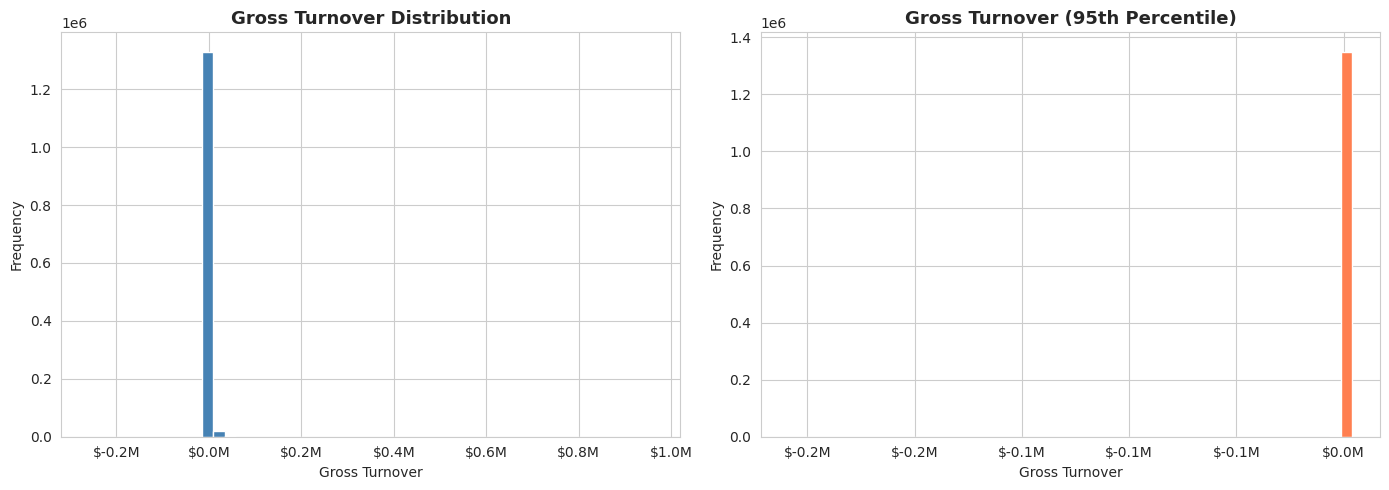

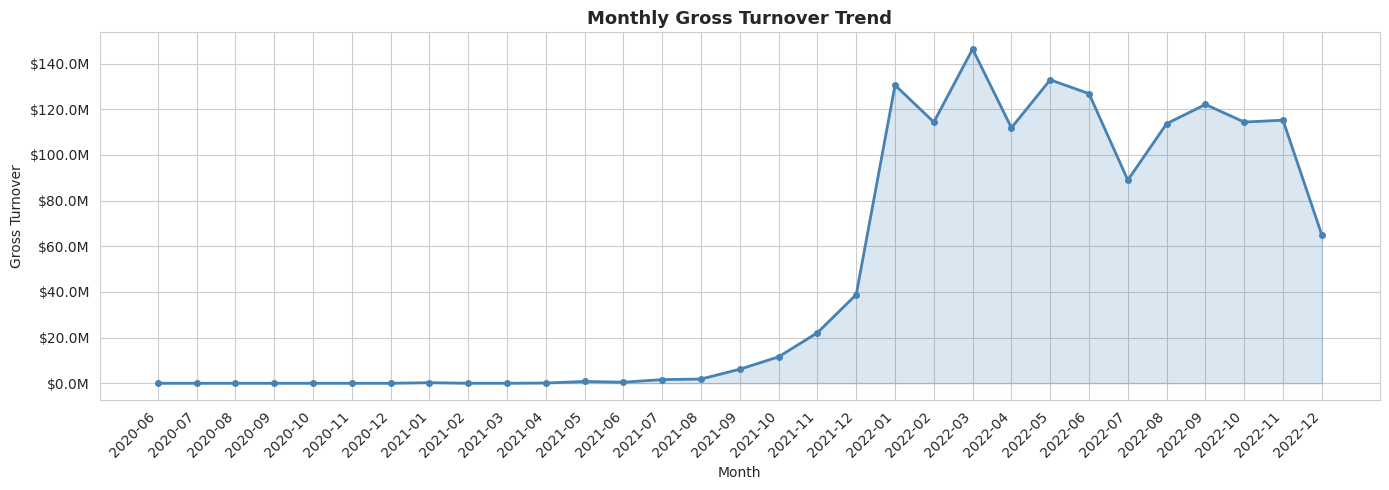

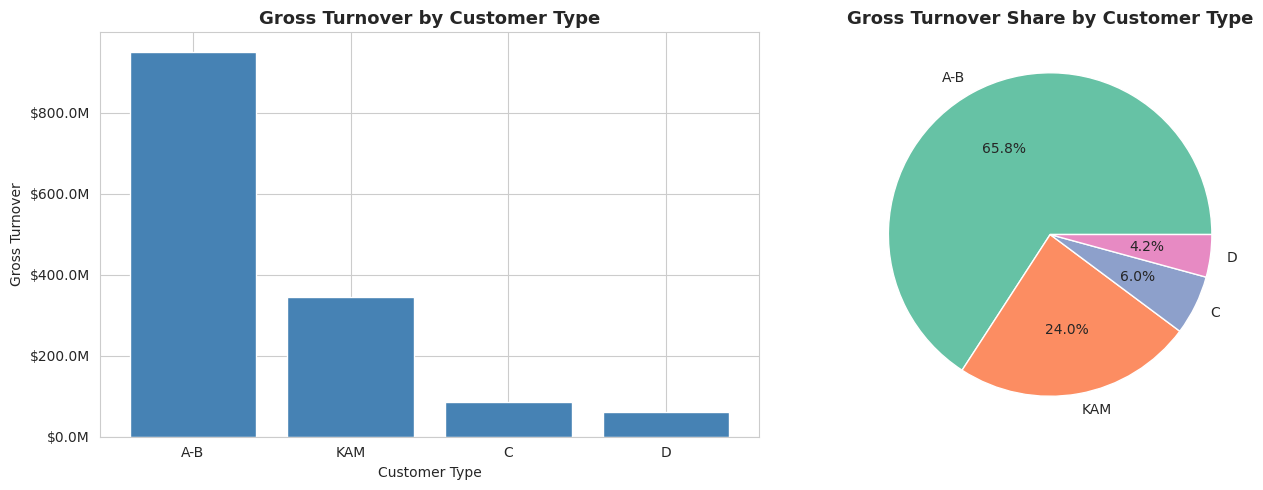

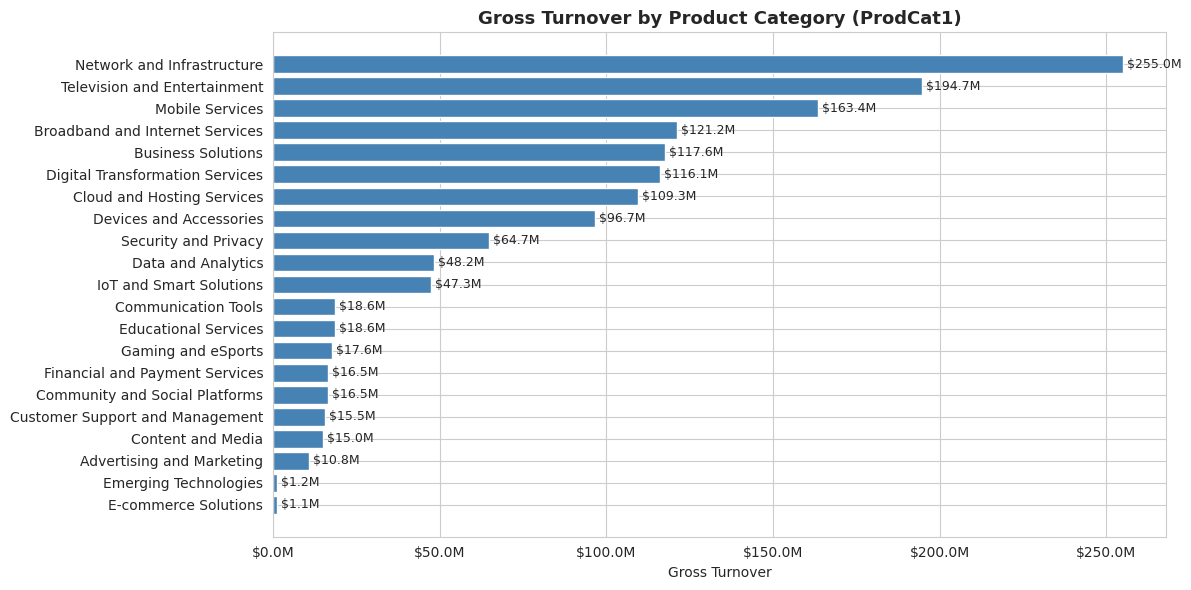

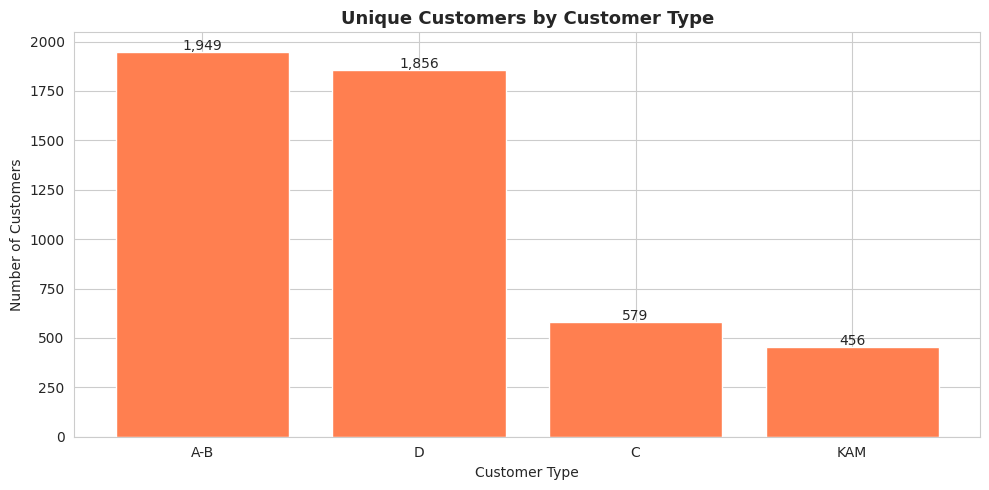

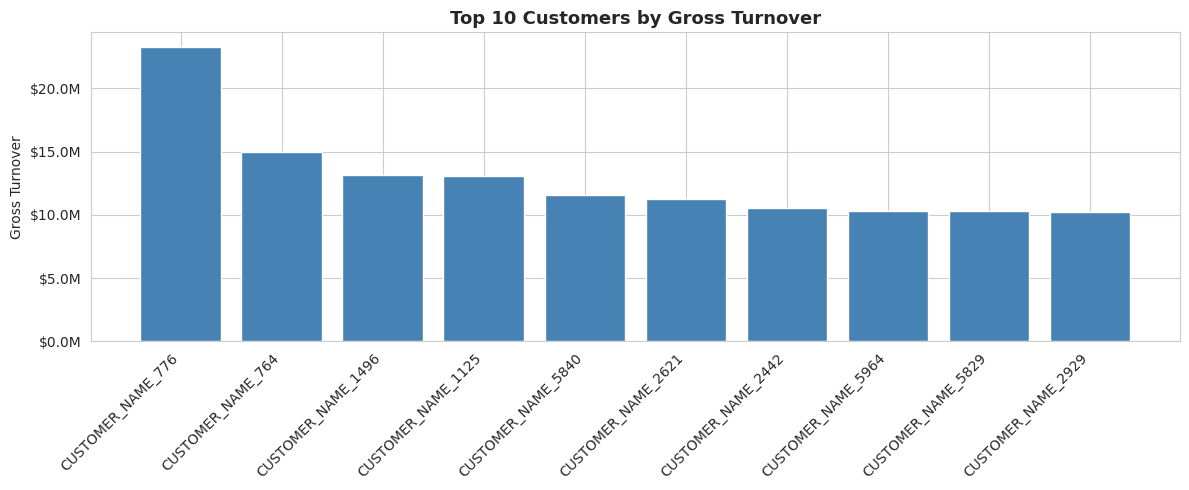


✓ Task 2.1 EDA complete!


In [48]:
# ============================================================
# TASK 2.1: EDA - Fixed
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100
sns.set_style("whitegrid")

# ← Add these formatter functions
def millions(x, pos): return f'${x/1e6:.1f}M'
def thousands(x, pos): return f'{x/1e3:.0f}K'

# ============================================================
# 1. Dataset Overview
# ============================================================
print("=" * 60)
print("1. DATASET OVERVIEW")
print("=" * 60)
print(f"  Total Rows             : {df_Txn_full.shape[0]:>10,}")
print(f"  Total Columns          : {df_Txn_full.shape[1]:>10,}")
print(f"  Date Range             : {df_Master['DOCUMENT_DATE'].min()} to {df_Master['DOCUMENT_DATE'].max()}")
print(f"  Unique Customers       : {df_Master['CUSTOMER_NUMBER'].nunique():>10,}")
print(f"  Total Gross Turnover   : ${df_Master['GROSS_TURNOVER'].sum():>14,.2f}")
print(f"\n  Null Values per Column:")
print(df_Master.isnull().sum()[df_Master.isnull().sum() > 0])
print(f"\n  Descriptive Statistics:")
print(df_Master[['GROSS_TURNOVER', 'AMOUNT']].describe())

# ============================================================
# 2. Gross Turnover Distribution
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df_Master['GROSS_TURNOVER'], bins=50,
             color='steelblue', edgecolor='white')
axes[0].set_title('Gross Turnover Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Gross Turnover')
axes[0].set_ylabel('Frequency')
axes[0].xaxis.set_major_formatter(FuncFormatter(millions))

axes[1].hist(df_Master['GROSS_TURNOVER'].clip(
             upper=df_Master['GROSS_TURNOVER'].quantile(0.95)),
             bins=50, color='coral', edgecolor='white')
axes[1].set_title('Gross Turnover (95th Percentile)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Gross Turnover')
axes[1].set_ylabel('Frequency')
axes[1].xaxis.set_major_formatter(FuncFormatter(millions))
plt.tight_layout()
plt.show()

# ============================================================
# 3. Monthly Gross Turnover Trend
# ============================================================
df_Master['DOCUMENT_DATE'] = pd.to_datetime(df_Master['DOCUMENT_DATE'])
df_Master['YearMonth'] = df_Master['DOCUMENT_DATE'].dt.to_period('M')
monthly_turnover = df_Master.groupby('YearMonth')['GROSS_TURNOVER'].sum().reset_index()
monthly_turnover['YearMonth_str'] = monthly_turnover['YearMonth'].astype(str)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_turnover['YearMonth_str'], monthly_turnover['GROSS_TURNOVER'],
        marker='o', color='steelblue', linewidth=2, markersize=4)
ax.fill_between(monthly_turnover['YearMonth_str'],
                monthly_turnover['GROSS_TURNOVER'], alpha=0.2, color='steelblue')
ax.set_title('Monthly Gross Turnover Trend', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Gross Turnover')
ax.yaxis.set_major_formatter(FuncFormatter(millions))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ============================================================
# 4. Gross Turnover by Customer Type
# ============================================================
cust_type_turnover = (df_Master.groupby('Customer_type')['GROSS_TURNOVER']
                      .sum().sort_values(ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(cust_type_turnover.index, cust_type_turnover.values,
            color='steelblue', edgecolor='white')
axes[0].set_title('Gross Turnover by Customer Type', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Customer Type')
axes[0].set_ylabel('Gross Turnover')
axes[0].yaxis.set_major_formatter(FuncFormatter(millions))

pie_colors = sns.color_palette('Set2', len(cust_type_turnover))
axes[1].pie(cust_type_turnover.values,
            labels=cust_type_turnover.index,
            autopct='%1.1f%%',
            colors=pie_colors)
axes[1].set_title('Gross Turnover Share by Customer Type',
                  fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================
# 5. Gross Turnover by Product Category
# ============================================================
prodcat_turnover = (df_Master.groupby('ProdCat1')['GROSS_TURNOVER']
                    .sum().sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(prodcat_turnover.index, prodcat_turnover.values,
               color='steelblue', edgecolor='white')
ax.set_title('Gross Turnover by Product Category (ProdCat1)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Gross Turnover')
ax.xaxis.set_major_formatter(FuncFormatter(millions))
for bar, val in zip(bars, prodcat_turnover.values):
    ax.text(val, bar.get_y() + bar.get_height()/2,
            f' ${val/1e6:.1f}M', va='center', fontsize=9)
plt.tight_layout()
plt.show()

# ============================================================
# 6. Customer Type Distribution
# ============================================================
cust_count = (df_Master.groupby('Customer_type')['CUSTOMER_NUMBER']
              .nunique().sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(cust_count.index, cust_count.values, color='coral', edgecolor='white')
ax.set_title('Unique Customers by Customer Type', fontsize=13, fontweight='bold')
ax.set_xlabel('Customer Type')
ax.set_ylabel('Number of Customers')
for i, (idx, val) in enumerate(cust_count.items()):
    ax.text(i, val + 10, f'{val:,}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

# ============================================================
# 7. Top 10 Customers by Gross Turnover
# ============================================================
top_customers = (df_Master.groupby(['CUSTOMER_NUMBER', 'CUSTOMER_NAME'])['GROSS_TURNOVER']
                 .sum().sort_values(ascending=False).head(10))

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(len(top_customers)), top_customers.values,
       color='steelblue', edgecolor='white')
ax.set_xticks(range(len(top_customers)))
ax.set_xticklabels([name for _, name in top_customers.index],
                   rotation=45, ha='right')
ax.set_title('Top 10 Customers by Gross Turnover', fontsize=13, fontweight='bold')
ax.set_ylabel('Gross Turnover')
ax.yaxis.set_major_formatter(FuncFormatter(millions))
plt.tight_layout()
plt.show()

print("\n✓ Task 2.1 EDA complete!")

## Pareto Analysis

**Pareto Analysis** is a strategic decision-making tool used to prioritize actions based on the principle that a small number of causes typically lead to a large portion of the effects. Known as the 80/20 rule or the Pareto Principle, this concept is highly applicable in customer and product management, helping businesses focus on the most impactful areas to maximize efficiency and profitability.

## Key Concepts


**i) Pareto Principle (80/20 Rule):**

In the context of customers and products, this principle suggests that roughly 80% of a company’s revenue comes from 20% of its customers or products. Understanding this can help businesses focus their efforts on the most valuable segments.

**ii) Pareto Chart:**

A Pareto chart is a graphical tool that helps visualize and prioritize the most significant factors among a set. It combines a bar graph and a line graph, where bars represent individual values in descending order, and the line shows the cumulative total.

***An example of Pareto Chart and Pareto Analysis:***

![image-2.png](attachment:image-2.png)

Here is the Pareto chart for products and their corresponding revenues. The chart consists of two key elements:

**Bar Chart:** The blue bars represent the individual revenue contributions of each product, sorted in descending order.

**Line Chart:** The red line shows the cumulative percentage of the total revenue contributed by the products. The horizontal
gray dashed line indicates the 80% mark.

***Analysis***

- Product Contribution: The first few products (A, B, and C) generate a significant portion of the revenue, highlighting the "vital few" that follow the Pareto Principle.
- Cumulative Percentage: By the time we include Product E, the cumulative revenue reaches around 80% of the total, illustrating that a small number of products contribute to the majority of the revenue.

***Implications***

- Focus on Key Products: Efforts should be concentrated on optimizing and promoting these top-performing products to maximize revenue.
- Resource Allocation: Inventory, marketing, and development resources should be prioritized for these high-impact products to enhance business efficiency and profitability.
- Customer Strategies: Understanding which products are most valued by customers can help in tailoring marketing and customer engagement strategies.


Using Pareto analysis helps businesses identify and focus on the most impactful products, ensuring efficient use of resources and targeted efforts towards driving revenue growth.

To execute the pareto analysis, you must create the required dataset. There are two levels of Product category in this dataset, use ProdCat2 for this analysis.

***Task 2.2: Create a new dataframe df_Pareto with the columns: ProdCat2, Gross_Turnover, Cumulative_GT, Cumulative_GT%***

*Hint: Cumulative_GT is Cumulative Gross Turnover which you can get by doing a cumulative sum on the Gross Turnover.*



In [49]:
# ============================================================
# TASK 2.2: Create df_Pareto for Pareto Analysis
# ============================================================

# --- Step 1: Aggregate Gross Turnover by ProdCat2 ---
df_Pareto = (df_Filtered.groupby('ProdCat2')['GROSS_TURNOVER']
             .sum()
             .reset_index()
             .rename(columns={'GROSS_TURNOVER': 'Gross_Turnover'}))

# --- Step 2: Sort descending by Gross Turnover ---
df_Pareto = df_Pareto.sort_values('Gross_Turnover', ascending=False).reset_index(drop=True)

# --- Step 3: Cumulative Gross Turnover ---
df_Pareto['Cumulative_GT'] = df_Pareto['Gross_Turnover'].cumsum()

# --- Step 4: Cumulative Gross Turnover % ---
df_Pareto['Cumulative_GT%'] = (df_Pareto['Cumulative_GT'] / df_Pareto['Gross_Turnover'].sum()) * 100

# --- Step 5: Verify ---
print("=" * 60)
print("df_Pareto - Overview")
print("=" * 60)
print(f"  Shape          : {df_Pareto.shape}")
print(f"  Total ProdCat2 : {df_Pareto['ProdCat2'].nunique()}")
print(f"  Total GT       : ${df_Pareto['Gross_Turnover'].sum():,.2f}")
print(f"  Max Cum GT%    : {df_Pareto['Cumulative_GT%'].max():.2f}%")

print(f"\n  Products reaching 80% cumulative revenue:")
at_80 = df_Pareto[df_Pareto['Cumulative_GT%'] <= 80]
print(f"  → {len(at_80)} out of {len(df_Pareto)} ProdCat2 categories ({len(at_80)/len(df_Pareto)*100:.1f}%)")

print(f"\nTop 10 rows of df_Pareto:")
df_Pareto.head(10)

df_Pareto - Overview
  Shape          : (219, 4)
  Total ProdCat2 : 219
  Total GT       : $934,607,058.55
  Max Cum GT%    : 100.00%

  Products reaching 80% cumulative revenue:
  → 64 out of 219 ProdCat2 categories (29.2%)

Top 10 rows of df_Pareto:


,ProdCat2,Gross_Turnover,Cumulative_GT,Cumulative_GT%
0,Mobile Plans (Postpaid),55933321.88,55933321.88,5.98
1,Network Infrastructure Services,41102764.85,97036086.73,10.38
2,Broadband Internet (Fiber),40566291.33,137602378.06,14.72
3,Mobile Plans (Prepaid),31679833.62,169282211.68,18.11
4,Wholesale Telecom Services,26025525.49,195307737.17,20.90
5,Enterprise networking equipment,25397447.36,220705184.54,23.61
6,Cloud and Hosting Services,23835336.45,244540520.99,26.17
7,5G Services,22063456.60,266603977.59,28.53
8,4G Services,20647561.17,287251538.77,30.74
9,Carrier Services,20209544.55,307461083.31,32.90


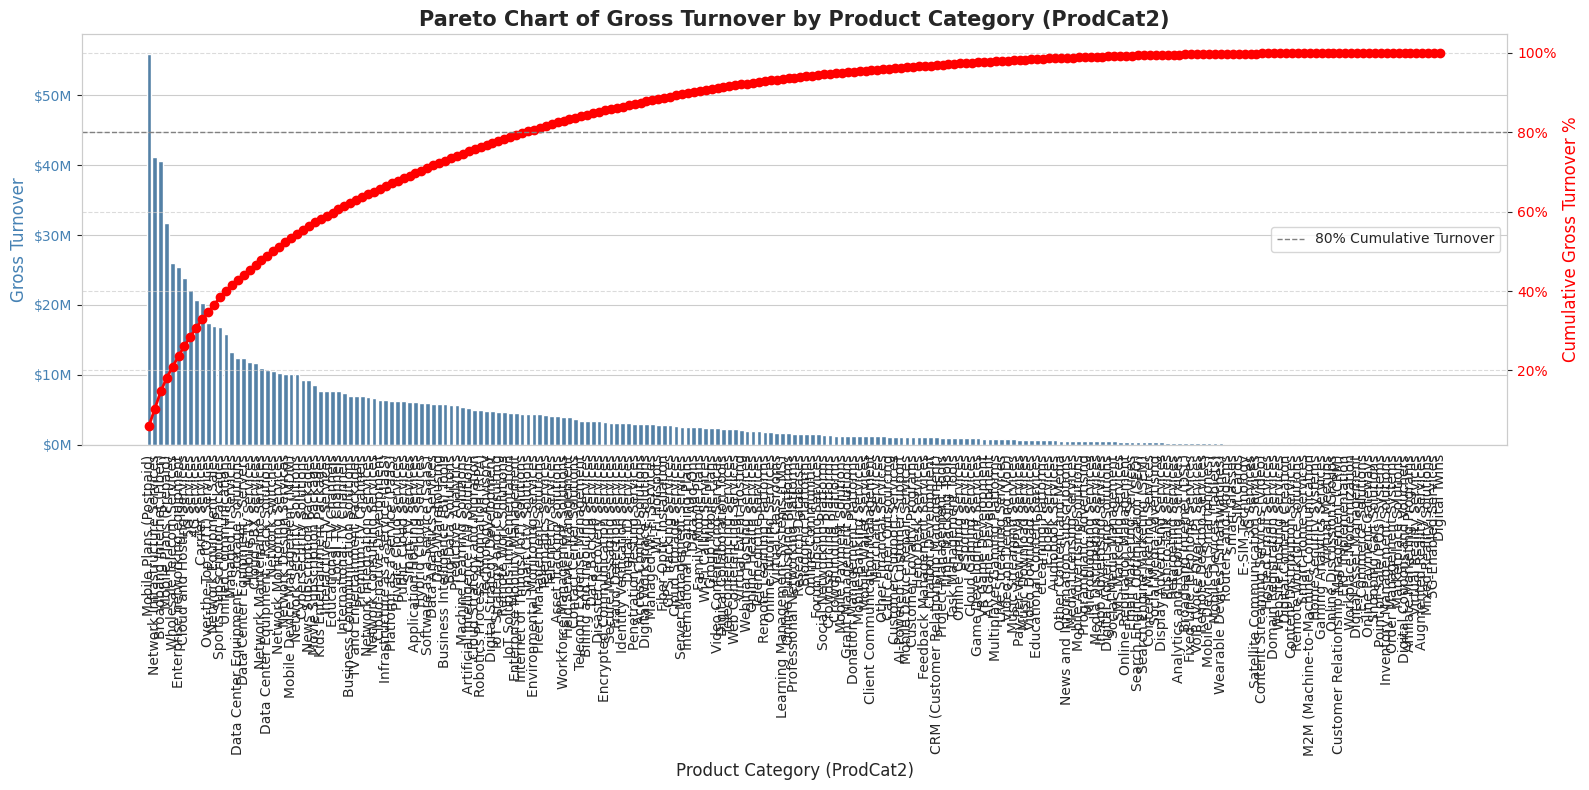

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

# Create a figure and a primary axis
fig, ax1 = plt.subplots(figsize=(16, 8))

# Bar plot for Gross Turnover
sns.barplot(x='ProdCat2', y='Gross_Turnover', data=df_Pareto, ax=ax1, color='steelblue')
ax1.set_xlabel('Product Category (ProdCat2)', fontsize=12)
ax1.set_ylabel('Gross Turnover', color='steelblue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'${x/1e6:,.0f}M')) # Format y-axis as millions
ax1.set_xticklabels(df_Pareto['ProdCat2'], rotation=90, fontsize=10) # Rotate x-axis labels

# Create a secondary y-axis for cumulative percentage
ax2 = ax1.twinx()
ax2.plot(df_Pareto['ProdCat2'], df_Pareto['Cumulative_GT%'], color='red', marker='o', linestyle='-', linewidth=2)
ax2.set_ylabel('Cumulative Gross Turnover %', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')
ax2.yaxis.set_major_formatter(PercentFormatter())

# Add 80% line for Pareto principle
ax2.axhline(80, color='gray', linestyle='--', linewidth=1, label='80% Cumulative Turnover')
ax2.legend(loc='center right')

# Add title
plt.title('Pareto Chart of Gross Turnover by Product Category (ProdCat2)', fontsize=15, fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

***Task 2.3: Arrive at a "Pareto filtered" dataset df_Pareto_80 with the top product categories that contribute to 80% of the Gross Turnover***

*Hint: There are 64 products that contribute to 80% of Gross Revenue turnover*

df_Pareto_80 - Overview
  Total ProdCat2 categories : 65 out of 219
  Gross Turnover covered    : $749,668,211.10
  % of Total GT             : 80.21%

Top 10 ProdCat2 in df_Pareto_80:
                       ProdCat2  Gross_Turnover  Cumulative_GT  Cumulative_GT%
        Mobile Plans (Postpaid)     55933321.88    55933321.88            5.98
Network Infrastructure Services     41102764.85    97036086.73           10.38
     Broadband Internet (Fiber)     40566291.33   137602378.06           14.72
         Mobile Plans (Prepaid)     31679833.62   169282211.68           18.11
     Wholesale Telecom Services     26025525.49   195307737.17           20.90
Enterprise networking equipment     25397447.36   220705184.54           23.61
     Cloud and Hosting Services     23835336.45   244540520.99           26.17
                    5G Services     22063456.60   266603977.59           28.53
                    4G Services     20647561.17   287251538.77           30.74
               Carrier Se

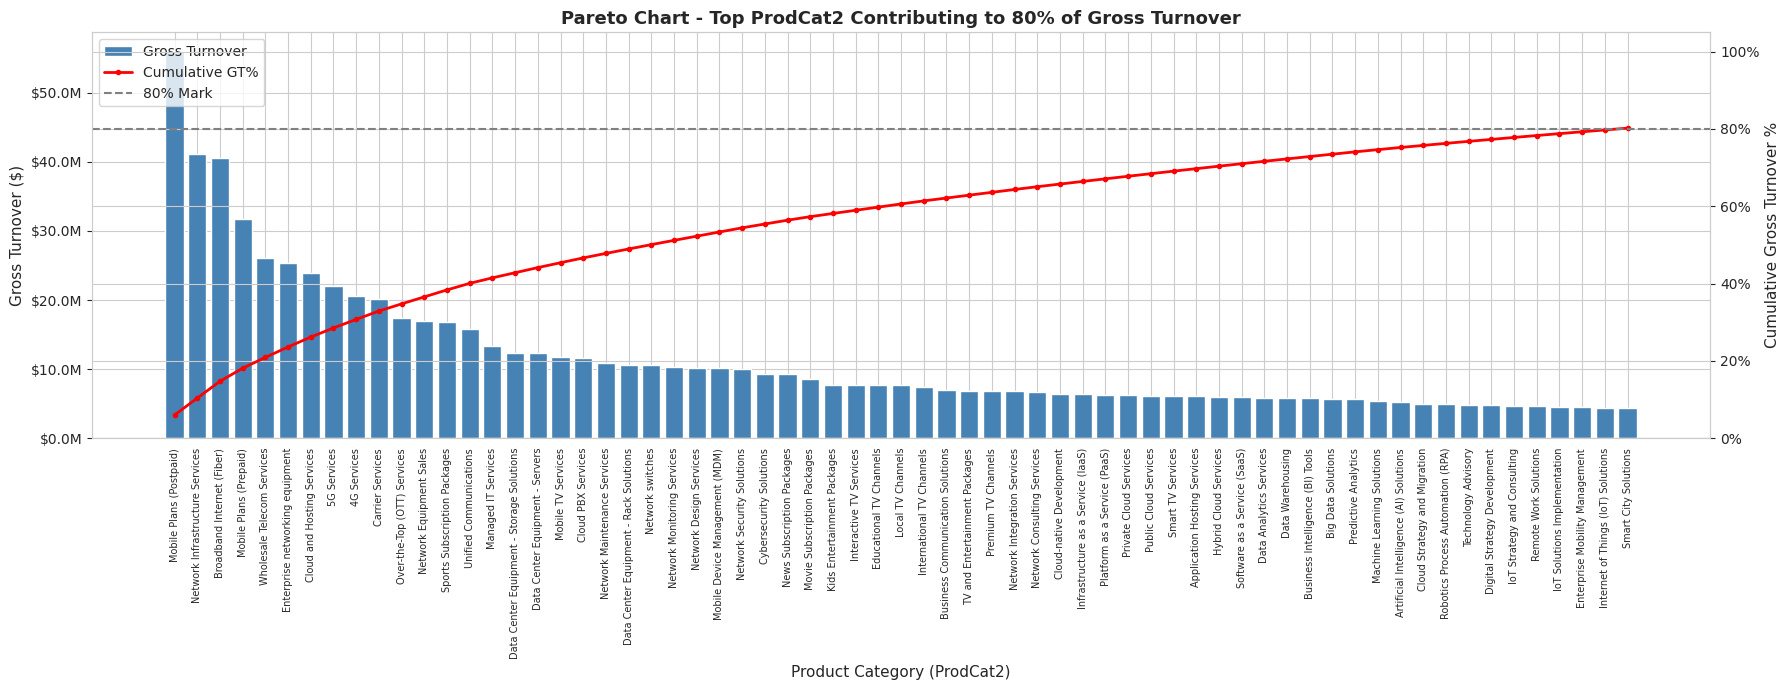


Pareto Insight:
  65 ProdCat2 categories (29.7% of all categories)
  contribute to 80% of total Gross Turnover of $934,607,058.55


In [51]:
# ============================================================
# TASK 2.3: Create df_Pareto_80 - Top ProdCat2 contributing 80% GT
# ============================================================

# --- Step 1: Filter ProdCat2 categories up to 80% cumulative GT ---
df_Pareto_80 = df_Pareto[df_Pareto['Cumulative_GT%'] <= 80].reset_index(drop=True)

# Edge case: include the category that crosses 80% threshold
if df_Pareto_80['Cumulative_GT%'].max() < 80:
    next_idx = len(df_Pareto_80)
    df_Pareto_80 = pd.concat([df_Pareto_80, df_Pareto.iloc[[next_idx]]]).reset_index(drop=True)

# --- Step 2: Verify ---
print("=" * 60)
print("df_Pareto_80 - Overview")
print("=" * 60)
print(f"  Total ProdCat2 categories : {len(df_Pareto_80)} out of {len(df_Pareto)}")
print(f"  Gross Turnover covered    : ${df_Pareto_80['Gross_Turnover'].sum():,.2f}")
print(f"  % of Total GT             : {df_Pareto_80['Cumulative_GT%'].max():.2f}%")

print(f"\nTop 10 ProdCat2 in df_Pareto_80:")
print(df_Pareto_80.head(10).to_string(index=False))

print(f"\nBottom 5 ProdCat2 in df_Pareto_80 (near 80% threshold):")
print(df_Pareto_80.tail(5).to_string(index=False))

# --- Step 3: Plot Pareto Chart ---
fig, ax1 = plt.subplots(figsize=(18, 7))

# Bar chart - Gross Turnover per ProdCat2
ax1.bar(df_Pareto_80.index, df_Pareto_80['Gross_Turnover'],
        color='steelblue', edgecolor='white', label='Gross Turnover')
ax1.set_xlabel('Product Category (ProdCat2)', fontsize=11)
ax1.set_ylabel('Gross Turnover ($)', fontsize=11)
ax1.yaxis.set_major_formatter(FuncFormatter(millions))
ax1.set_xticks(df_Pareto_80.index)
ax1.set_xticklabels(df_Pareto_80['ProdCat2'], rotation=90, fontsize=7)
ax1.set_title('Pareto Chart - Top ProdCat2 Contributing to 80% of Gross Turnover',
              fontsize=13, fontweight='bold')

# Line chart - Cumulative GT% on secondary axis
ax2 = ax1.twinx()
ax2.plot(df_Pareto_80.index, df_Pareto_80['Cumulative_GT%'],
         color='red', marker='o', linewidth=2, markersize=3, label='Cumulative GT%')
ax2.axhline(y=80, color='gray', linestyle='--', linewidth=1.5, label='80% Mark')
ax2.set_ylabel('Cumulative Gross Turnover %', fontsize=11)
ax2.set_ylim(0, 105)
ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.0f}%'))

# Legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

print(f"\nPareto Insight:")
print(f"  {len(df_Pareto_80)} ProdCat2 categories ({len(df_Pareto_80)/len(df_Pareto)*100:.1f}% of all categories)")
print(f"  contribute to 80% of total Gross Turnover of ${df_Pareto['Gross_Turnover'].sum():,.2f}")

***Task 2.3: Display the Pareto Chart***

*Hint: Your Pareto Chart will look something like this*

![image.png](attachment:image.png)


***Task 2.4: Perform the necessary action to map the top products from Pareto Analysis to the previously created master dataframe df_Filtered and store this in a new dataframe df_Filtered_Pareto.***

*Hint: Think Joins?*

In [52]:
# ============================================================
# TASK 2.4: Map Pareto top products to df_Filtered
# → df_Filtered_Pareto
# ============================================================

# --- Step 1: Get list of top ProdCat2 from df_Pareto_80 ---
top_prodcat2 = df_Pareto_80['ProdCat2'].tolist()
print(f"Number of top ProdCat2 categories : {len(top_prodcat2)}")

# --- Step 2: Filter df_Filtered to only keep top ProdCat2 ---
df_Filtered_Pareto = df_Filtered[
    df_Filtered['ProdCat2'].isin(top_prodcat2)
].reset_index(drop=True)

# --- Step 3: Verify ---
print("\n" + "=" * 60)
print("df_Filtered_Pareto - Overview")
print("=" * 60)
print(f"  df_Filtered shape        : {df_Filtered.shape}")
print(f"  df_Filtered_Pareto shape : {df_Filtered_Pareto.shape}")
print(f"  Rows removed             : {df_Filtered.shape[0] - df_Filtered_Pareto.shape[0]:,}")

# --- Step 4: Validate key metrics ---
gross_turnover  = df_Filtered_Pareto['GROSS_TURNOVER'].sum()
total_customers = df_Filtered_Pareto['CUSTOMER_NUMBER'].nunique()
total_products  = df_Filtered_Pareto['ProdCat2'].nunique()

print(f"\n  Gross Turnover      : ${gross_turnover:,.2f}")
print(f"  % of Total GT       : {gross_turnover / df_Filtered['GROSS_TURNOVER'].sum() * 100:.2f}%")
print(f"  Unique Customers    : {total_customers:,}")
print(f"  Unique ProdCat2     : {total_products:,}")
print(f"  Date Range          : {df_Filtered_Pareto['DOCUMENT_DATE'].min()} to {df_Filtered_Pareto['DOCUMENT_DATE'].max()}")

print(f"\n  ProdCat2 in df_Filtered_Pareto:")
print(df_Filtered_Pareto['ProdCat2'].value_counts().head(10))

print(f"\nColumns in df_Filtered_Pareto:")
print(df_Filtered_Pareto.columns.tolist())

print(f"\nFirst 3 rows:")
df_Filtered_Pareto.head(3)

Number of top ProdCat2 categories : 65

df_Filtered_Pareto - Overview
  df_Filtered shape        : (842348, 25)
  df_Filtered_Pareto shape : (652910, 25)
  Rows removed             : 189,438

  Gross Turnover      : $749,668,211.10
  % of Total GT       : 80.21%
  Unique Customers    : 4,888
  Unique ProdCat2     : 65
  Date Range          : 2020-07-29 00:00:00 to 2022-12-30 00:00:00

  ProdCat2 in df_Filtered_Pareto:
ProdCat2
Mobile Plans (Prepaid)             71585
Mobile TV Services                 36857
Managed IT Services                34235
Network Infrastructure Services    34104
Premium TV Channels                29701
Wholesale Telecom Services         23634
Mobile Device Management (MDM)     22548
Network Equipment Sales            20140
Cloud-native Development           18286
Smart TV Services                  17297
Name: count, dtype: int64

Columns in df_Filtered_Pareto:
['INDEX', 'INVOICE_NUMBER', 'INVOICE_ITEM', 'DOCUMENT_DATE', 'CUSTOMER_NUMBER', 'Main_account', 'Main

,INDEX,INVOICE_NUMBER,INVOICE_ITEM,DOCUMENT_DATE,CUSTOMER_NUMBER,Main_account,Main_account_name,Main_resposible_employee_name,PRODUCT,Position_type_order_line,...,Main_account_ID,Customer_type,ProductID,ProductCategoryID,ProdCat2,ProdCat1,Txn_Count,Invoice_flag,SKU_Count,SKU_flag
0,47154,124195645,10,2022-09-09,15082,103350,Customer Group_24,Responsible Employee_17,5737657492,ZLAG,...,103350,A-B,5737657492,605.00,Cloud Strategy and Migration,Digital Transformation Services,4100,1,2009,1
1,47184,124167744,70,2022-09-07,15082,103350,Customer Group_24,Responsible Employee_17,4441429746,ZLAG,...,103350,A-B,4441429746,686.00,Predictive Analytics,Data and Analytics,4100,1,2009,1
2,48255,124385024,480,2022-10-10,15082,103350,Customer Group_24,Responsible Employee_17,31592006,ZLAG,...,103350,A-B,31592006,756.00,Mobile TV Services,Television and Entertainment,4100,1,2009,1


In the above dataset, you will notice that there are some columns that are repititive and redundant.

***Task 2.5: Remove the redundant columns and give a meaningful name to the repititive columns***

In [53]:
# ============================================================
# Check redundant/repetitive columns
# ============================================================

print("All columns in df_Filtered_Pareto:")
for i, col in enumerate(df_Filtered_Pareto.columns.tolist()):
    print(f"  {i:>3} : '{col}'")

print("\nSample values to identify redundancy:")
print(f"\n  CUSTOMER_NUMBER vs Main_account:")
print(df_Filtered_Pareto[['CUSTOMER_NUMBER', 'Main_account', 'Main_account_ID']].head(5))

print(f"\n  PRODUCT vs ProductID:")
print(df_Filtered_Pareto[['PRODUCT', 'ProductID']].head(5))

print(f"\n  Are CUSTOMER_NUMBER & Main_account_ID always equal?")
print((df_Filtered_Pareto['CUSTOMER_NUMBER'] == df_Filtered_Pareto['Main_account_ID']).value_counts())

print(f"\n  Are PRODUCT & ProductID always equal?")
print((df_Filtered_Pareto['PRODUCT'] == df_Filtered_Pareto['ProductID']).value_counts())

All columns in df_Filtered_Pareto:
    0 : 'INDEX'
    1 : 'INVOICE_NUMBER'
    2 : 'INVOICE_ITEM'
    3 : 'DOCUMENT_DATE'
    4 : 'CUSTOMER_NUMBER'
    5 : 'Main_account'
    6 : 'Main_account_name'
    7 : 'Main_resposible_employee_name'
    8 : 'PRODUCT'
    9 : 'Position_type_order_line'
   10 : 'GROSS_TURNOVER'
   11 : 'AMOUNT'
   12 : 'CUSTOMER_NAME'
   13 : 'ACCOUNT_GROUP_TXT'
   14 : 'CVR_Company_status'
   15 : 'Main_account_ID'
   16 : 'Customer_type'
   17 : 'ProductID'
   18 : 'ProductCategoryID'
   19 : 'ProdCat2'
   20 : 'ProdCat1'
   21 : 'Txn_Count'
   22 : 'Invoice_flag'
   23 : 'SKU_Count'
   24 : 'SKU_flag'

Sample values to identify redundancy:

  CUSTOMER_NUMBER vs Main_account:
  CUSTOMER_NUMBER Main_account Main_account_ID
0           15082       103350          103350
1           15082       103350          103350
2           15082       103350          103350
3           15082       103350          103350
4           15082       103350          103350

  PRODUC

**This analysis gives an understanding of the top product portfolio of the company. This will be further used to perform customer segmentation.**

### 3. Customer Segmentation

The next part in this analysis is to find meaningful customer segments from the product purchase behaviour.

You will use **KMeans Clustering Algorithm** for this.

### KMeans Algorithm
The KMeans algorithm is a popular clustering technique used to partition a dataset into K clusters, where each data point belongs to the cluster with the nearest mean. Here are the steps involved in the KMeans algorithm:

**Initialization:**

- Choose the optimal number of clusters K, say 3 in this case.
- Randomly select K data points from the dataset as the initial centroids (cluster centers).

![image-2.png](attachment:image-2.png)

**Assignment Step:**

- Assign each data point to the nearest centroid. This is usually done by calculating the Euclidean distance between each data point and the centroids.
- Each data point is assigned to the cluster whose centroid is closest to it.

**Update Step:**

- Recalculate the centroids as the mean of all data points assigned to each cluster.
- The new centroid for each cluster is the average of the positions of all the data points in that cluster.

![image-3.png](attachment:image-3.png)

**Repeat:**

- Repeat the Assignment and Update steps until the centroids no longer change significantly or a specified number of iterations is reached.
- This convergence indicates that the clusters are stable, and the algorithm has found the optimal clustering.

![image-4.png](attachment:image-4.png)

**Termination:**

- The algorithm terminates when the centroids have stabilized (i.e., they do not change significantly between iterations) or after a pre-defined number of iterations.



To execute this analysis, **Main Account** and **ProdCat1** (is a broader product category and is at the highest level in the product hierarchy) data will be used.

*Note: ProdCat2 level data is at a very granular level and performing clustering analysis on this might not give meaningful clusters.*

To proceed with the customer segmentation analysis, you need to menaingfully prepare the data.

***Task 3.1: Transform the data to feed to the clustering algorithm***

- Create a copy of the above dataframe and save it as **df_segment**
- Create a Primary Key: Concatenate the Main Account (ID) and Main Account Name
- Execute a groupby operation to calculate the annual turnover of each customer for each product (ProdCat1)
- Calculate the % spend by each customer across different product categories

The resultant dataframe will have the following columns:
- Primary Key
- ProdCat1
- Gross_Turnover
- Customer Spend %

In [54]:
# ============================================================
# TASK 2.5: Remove redundant columns & rename repetitive ones
# ============================================================

# --- Step 1: Drop redundant columns ---
cols_to_drop = ['INDEX', 'ProductID', 'Main_account_ID']

df_Filtered_Pareto = df_Filtered_Pareto.drop(columns=cols_to_drop)
print(f"Dropped columns: {cols_to_drop}")

# --- Step 2: Rename columns to meaningful names ---
df_Filtered_Pareto = df_Filtered_Pareto.rename(columns={
    'INVOICE_NUMBER'                 : 'Invoice_Number',
    'INVOICE_ITEM'                   : 'Invoice_Item',
    'DOCUMENT_DATE'                  : 'Document_Date',
    'CUSTOMER_NUMBER'                : 'Customer_Number',
    'Main_account'                   : 'Main_Account_ID',
    'Main_account_name'              : 'Main_Account_Name',
    'Main_resposible_employee_name'  : 'Responsible_Employee',
    'PRODUCT'                        : 'Product_ID',
    'Position_type_order_line'       : 'Position_Type',
    'GROSS_TURNOVER'                 : 'Gross_Turnover',
    'AMOUNT'                         : 'Amount',
    'CUSTOMER_NAME'                  : 'Customer_Name',
    'ACCOUNT_GROUP_TXT'              : 'Account_Group',
    'CVR_Company_status'             : 'Company_Status',
    'ProductCategoryID'              : 'Product_Category_ID',
})

# --- Step 3: Verify ---
print("\nFinal columns in df_Filtered_Pareto:")
for i, col in enumerate(df_Filtered_Pareto.columns.tolist()):
    print(f"  {i:>3} : '{col}'")

print(f"\n  Shape : {df_Filtered_Pareto.shape}")
print(f"\nFirst 3 rows:")
df_Filtered_Pareto.head(3)

Dropped columns: ['INDEX', 'ProductID', 'Main_account_ID']

Final columns in df_Filtered_Pareto:
    0 : 'Invoice_Number'
    1 : 'Invoice_Item'
    2 : 'Document_Date'
    3 : 'Customer_Number'
    4 : 'Main_Account_ID'
    5 : 'Main_Account_Name'
    6 : 'Responsible_Employee'
    7 : 'Product_ID'
    8 : 'Position_Type'
    9 : 'Gross_Turnover'
   10 : 'Amount'
   11 : 'Customer_Name'
   12 : 'Account_Group'
   13 : 'Company_Status'
   14 : 'Customer_type'
   15 : 'Product_Category_ID'
   16 : 'ProdCat2'
   17 : 'ProdCat1'
   18 : 'Txn_Count'
   19 : 'Invoice_flag'
   20 : 'SKU_Count'
   21 : 'SKU_flag'

  Shape : (652910, 22)

First 3 rows:


,Invoice_Number,Invoice_Item,Document_Date,Customer_Number,Main_Account_ID,Main_Account_Name,Responsible_Employee,Product_ID,Position_Type,Gross_Turnover,...,Account_Group,Company_Status,Customer_type,Product_Category_ID,ProdCat2,ProdCat1,Txn_Count,Invoice_flag,SKU_Count,SKU_flag
0,124195645,10,2022-09-09,15082,103350,Customer Group_24,Responsible Employee_17,5737657492,ZLAG,3870.22,...,Debtors,Active,A-B,605.00,Cloud Strategy and Migration,Digital Transformation Services,4100,1,2009,1
1,124167744,70,2022-09-07,15082,103350,Customer Group_24,Responsible Employee_17,4441429746,ZLAG,286.81,...,Debtors,Active,A-B,686.00,Predictive Analytics,Data and Analytics,4100,1,2009,1
2,124385024,480,2022-10-10,15082,103350,Customer Group_24,Responsible Employee_17,31592006,ZLAG,52.31,...,Debtors,Active,A-B,756.00,Mobile TV Services,Television and Entertainment,4100,1,2009,1


In [55]:
# ============================================================
# TASK 3.1: Transform data for clustering
# ============================================================

# --- Step 1: Create a copy as df_segment ---
df_segment = df_Filtered_Pareto.copy()
print(f"✓ df_segment created: {df_segment.shape}")

# --- Step 2: Create Primary Key ---
# Concatenate Main_Account_ID and Main_Account_Name
df_segment['Primary_Key'] = (
    df_segment['Main_Account_ID'].astype(str)
    + '_'
    + df_segment['Main_Account_Name'].astype(str)
)
print(f"✓ Primary_Key created")
print(f"  Sample: {df_segment['Primary_Key'].head(3).tolist()}")
print(f"  Unique Primary Keys: {df_segment['Primary_Key'].nunique():,}")

# --- Step 3: Groupby to calculate annual Gross Turnover
#             per customer (Primary_Key) per ProdCat1 ---
df_segment = (df_segment.groupby(['Primary_Key', 'ProdCat1'])['Gross_Turnover']
              .sum()
              .reset_index()
              .rename(columns={'Gross_Turnover': 'Gross_Turnover'}))

print(f"\n✓ After groupby: {df_segment.shape}")
print(f"  Unique Primary Keys : {df_segment['Primary_Key'].nunique():,}")
print(f"  Unique ProdCat1     : {df_segment['ProdCat1'].nunique():,}")

# --- Step 4: Calculate % spend per customer across ProdCat1 ---
# Total spend per customer
total_spend = df_segment.groupby('Primary_Key')['Gross_Turnover'].transform('sum')

# % spend per ProdCat1 per customer
df_segment['Customer_Spend%'] = (df_segment['Gross_Turnover'] / total_spend * 100).round(2)

# --- Step 5: Reorder columns ---
df_segment = df_segment[['Primary_Key', 'ProdCat1', 'Gross_Turnover', 'Customer_Spend%']]

# --- Step 6: Verify ---
print("\n" + "=" * 60)
print("df_segment - Overview")
print("=" * 60)
print(f"  Shape               : {df_segment.shape}")
print(f"  Unique Primary Keys : {df_segment['Primary_Key'].nunique():,}")
print(f"  Unique ProdCat1     : {df_segment['ProdCat1'].nunique():,}")
print(f"  Customer_Spend% sum check (should be ~100 per customer):")
spend_check = df_segment.groupby('Primary_Key')['Customer_Spend%'].sum()
print(f"    Min : {spend_check.min():.2f}%")
print(f"    Max : {spend_check.max():.2f}%")
print(f"    Mean: {spend_check.mean():.2f}%")

print(f"\nFirst 10 rows of df_segment:")
df_segment.head(10)

✓ df_segment created: (652910, 22)
✓ Primary_Key created
  Sample: ['103350_Customer Group_24', '103350_Customer Group_24', '103350_Customer Group_24']
  Unique Primary Keys: 4,452

✓ After groupby: (24634, 3)
  Unique Primary Keys : 4,452
  Unique ProdCat1     : 11

df_segment - Overview
  Shape               : (24634, 4)
  Unique Primary Keys : 4,452
  Unique ProdCat1     : 11
  Customer_Spend% sum check (should be ~100 per customer):
    Min : 99.97%
    Max : 100.03%
    Mean: 100.00%

First 10 rows of df_segment:


,Primary_Key,ProdCat1,Gross_Turnover,Customer_Spend%
0,100015_Customer Group_2149,Broadband and Internet Services,9250.04,44.25
1,100015_Customer Group_2149,Cloud and Hosting Services,124.69,0.60
2,100015_Customer Group_2149,Devices and Accessories,132.17,0.63
3,100015_Customer Group_2149,Digital Transformation Services,4106.33,19.65
4,100015_Customer Group_2149,Mobile Services,123.71,0.59
5,100015_Customer Group_2149,Network and Infrastructure,4982.87,23.84
6,100015_Customer Group_2149,Television and Entertainment,2182.68,10.44
7,100020_Customer Group_1816,Cloud and Hosting Services,312.20,23.78
8,100020_Customer Group_1816,Mobile Services,1000.50,76.22
9,100022_Customer Group_1631,Business Solutions,3266.52,16.45


***Task 3.2: Pivot the dataset to create a matrix view of spend % of all customers on all products (ProdCat1). Save the dataframe as df_pivot. Create another dataframe df_clustering removing the primary key from the df_pivot dataframe.***

In [56]:
# ============================================================
# TASK 3.2: Pivot df_segment & create df_clustering
# ============================================================

# --- Step 1: Pivot table ---
# Rows = Primary_Key, Columns = ProdCat1, Values = Customer_Spend%
df_pivot = df_segment.pivot_table(
    index='Primary_Key',
    columns='ProdCat1',
    values='Customer_Spend%',
    aggfunc='sum'
).fillna(0)  # Fill NaN with 0 (customer didn't spend in that category)

# Reset column name label
df_pivot.columns.name = None
df_pivot = df_pivot.reset_index()

print("=" * 60)
print("df_pivot - Overview")
print("=" * 60)
print(f"  Shape               : {df_pivot.shape}")
print(f"  Unique Primary Keys : {df_pivot['Primary_Key'].nunique():,}")
print(f"  Columns             : {df_pivot.columns.tolist()}")
print(f"\n  Row spend % sum check (should be ~100 per customer):")
spend_check = df_pivot.drop(columns='Primary_Key').sum(axis=1)
print(f"    Min : {spend_check.min():.2f}%")
print(f"    Max : {spend_check.max():.2f}%")
print(f"    Mean: {spend_check.mean():.2f}%")

print(f"\nFirst 3 rows of df_pivot:")
df_pivot.head(3)

df_pivot - Overview
  Shape               : (4452, 12)
  Unique Primary Keys : 4,452
  Columns             : ['Primary_Key', 'Broadband and Internet Services', 'Business Solutions', 'Cloud and Hosting Services', 'Data and Analytics', 'Devices and Accessories', 'Digital Transformation Services', 'IoT and Smart Solutions', 'Mobile Services', 'Network and Infrastructure', 'Security and Privacy', 'Television and Entertainment']

  Row spend % sum check (should be ~100 per customer):
    Min : 99.97%
    Max : 100.03%
    Mean: 100.00%

First 3 rows of df_pivot:


,Primary_Key,Broadband and Internet Services,Business Solutions,Cloud and Hosting Services,Data and Analytics,Devices and Accessories,Digital Transformation Services,IoT and Smart Solutions,Mobile Services,Network and Infrastructure,Security and Privacy,Television and Entertainment
0,100015_Customer Group_2149,44.25,0.00,0.60,0.00,0.63,19.65,0.00,0.59,23.84,0.00,10.44
1,100020_Customer Group_1816,0.00,0.00,23.78,0.00,0.00,0.00,0.00,76.22,0.00,0.00,0.00
2,100022_Customer Group_1631,0.00,16.45,5.92,0.00,10.94,0.00,12.84,4.73,9.02,38.89,1.21


In [57]:
# --- Step 2: Create df_clustering (remove Primary_Key) ---
df_clustering = df_pivot.drop(columns='Primary_Key').reset_index(drop=True)

print("=" * 60)
print("df_clustering - Overview")
print("=" * 60)
print(f"  Shape    : {df_clustering.shape}")
print(f"  Columns  : {df_clustering.columns.tolist()}")
print(f"\n  Descriptive Statistics:")
print(df_clustering.describe().round(2))

print(f"\nFirst 3 rows of df_clustering:")
df_clustering.head(3)

df_clustering - Overview
  Shape    : (4452, 11)
  Columns  : ['Broadband and Internet Services', 'Business Solutions', 'Cloud and Hosting Services', 'Data and Analytics', 'Devices and Accessories', 'Digital Transformation Services', 'IoT and Smart Solutions', 'Mobile Services', 'Network and Infrastructure', 'Security and Privacy', 'Television and Entertainment']

  Descriptive Statistics:
       Broadband and Internet Services  Business Solutions  \
count                          4452.00             4452.00   
mean                              5.81                4.00   
std                              16.02               11.99   
min                               0.00                0.00   
25%                               0.00                0.00   
50%                               0.00                0.00   
75%                               1.69                1.61   
max                             100.00              100.00   

       Cloud and Hosting Services  Data and Anal

,Broadband and Internet Services,Business Solutions,Cloud and Hosting Services,Data and Analytics,Devices and Accessories,Digital Transformation Services,IoT and Smart Solutions,Mobile Services,Network and Infrastructure,Security and Privacy,Television and Entertainment
0,44.25,0.00,0.60,0.00,0.63,19.65,0.00,0.59,23.84,0.00,10.44
1,0.00,0.00,23.78,0.00,0.00,0.00,0.00,76.22,0.00,0.00,0.00
2,0.00,16.45,5.92,0.00,10.94,0.00,12.84,4.73,9.02,38.89,1.21


### The Elbow Method in KMeans Clustering

The Elbow Method is a commonly used technique to determine the optimal number of clusters (K) in KMeans clustering. It helps to balance between underfitting and overfitting by finding a point where adding more clusters doesn’t significantly improve the model performance.

![image.png](attachment:image.png)

***Explanation of the Plot***

**WCSS (Within Cluster Sum of Squares) vs. Number of Clusters:**

- The x-axis represents the number of clusters (K).
- The y-axis represents the Within-Cluster Sum of Squares (WCSS), which measures the variance within each cluster.

**Plotting WCSS for Different K Values:**

- For each value of K (from 1 to 10), the KMeans algorithm is run, and the corresponding WCSS is calculated.
- The plot shows how WCSS decreases as the number of clusters increases.

**Elbow Point:**

- The red point marked on the plot indicates the "elbow point" where the rate of decrease in WCSS slows down.
- In this example, the elbow point is at K = 3. This suggests that 3 clusters are optimal for this dataset, as adding more clusters beyond this point results in only a marginal reduction in WCSS.

**Interpretation:**

- Before the Elbow Point: Adding more clusters significantly reduces WCSS, indicating that the clusters are becoming more defined and compact.
- After the Elbow Point: The reduction in WCSS slows down, meaning that adding more clusters doesn’t significantly improve the clustering.

**Conclusion**

The Elbow Method helps to identify the optimal number of clusters by looking for the point where the WCSS starts to decrease at a slower rate, balancing model complexity and performance. In this case, the plot suggests that using 3 clusters is a good choice for the dataset.

***Task 3.3: Run K-Means clustering algorithm and identify the optimal number of clusters using Elbow Method***

✓ Data scaled using StandardScaler
  Shape: (4452, 11)

Running KMeans for K = 1 to 10...
  K=1 | WCSS:    48,972.00 | Silhouette: N/A
  K=2 | WCSS:    44,881.63 | Silhouette: 0.0441
  K=3 | WCSS:    41,325.19 | Silhouette: 0.1182
  K=4 | WCSS:    37,524.28 | Silhouette: 0.1345
  K=5 | WCSS:    33,858.78 | Silhouette: 0.1447
  K=6 | WCSS:    30,760.39 | Silhouette: 0.1703
  K=7 | WCSS:    27,204.70 | Silhouette: 0.2363
  K=8 | WCSS:    23,575.54 | Silhouette: 0.2726
  K=9 | WCSS:    20,528.59 | Silhouette: 0.3073
  K=10 | WCSS:    17,412.80 | Silhouette: 0.3261


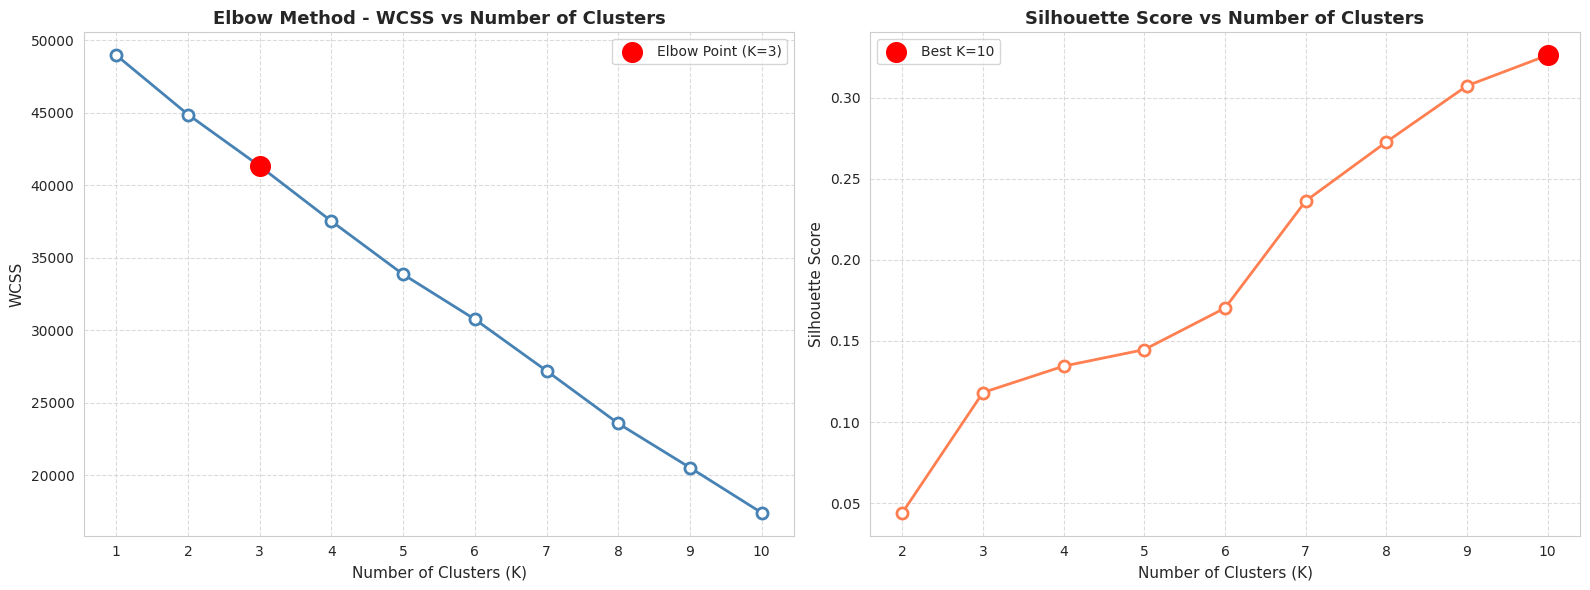


ELBOW METHOD SUMMARY
    K |            WCSS |   Silhouette
----------------------------------------
    1 |       48,972.00 |          N/A
    2 |       44,881.63 |       0.0441
    3 |       41,325.19 |       0.1182
    4 |       37,524.28 |       0.1345
    5 |       33,858.78 |       0.1447
    6 |       30,760.39 |       0.1703
    7 |       27,204.70 |       0.2363
    8 |       23,575.54 |       0.2726
    9 |       20,528.59 |       0.3073
   10 |       17,412.80 |       0.3261

✓ Optimal K by Elbow Method    : 3
✓ Optimal K by Silhouette Score: 10


In [58]:
# ============================================================
# TASK 3.3: KMeans Clustering - Elbow Method
# ============================================================
from sklearn.cluster import KMeans
from sklearn import preprocessing
from sklearn.metrics import silhouette_score

# --- Step 1: Scale the data ---
scaler = preprocessing.StandardScaler()
df_clustering_scaled = scaler.fit_transform(df_clustering)
print("✓ Data scaled using StandardScaler")
print(f"  Shape: {df_clustering_scaled.shape}")

# --- Step 2: Run KMeans for K = 1 to 10 & calculate WCSS ---
wcss = []
silhouette_scores = []
K_range = range(1, 11)

print("\nRunning KMeans for K = 1 to 10...")
for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', max_iter=300,
                    n_init=10, random_state=42)
    kmeans.fit(df_clustering_scaled)
    wcss.append(kmeans.inertia_)

    if k >= 2:
        score = silhouette_score(df_clustering_scaled, kmeans.labels_)
        silhouette_scores.append(score)
        print(f"  K={k} | WCSS: {kmeans.inertia_:>12,.2f} | Silhouette: {score:.4f}")
    else:
        print(f"  K={k} | WCSS: {kmeans.inertia_:>12,.2f} | Silhouette: N/A")

# --- Step 3: Plot Elbow Curve + Silhouette Score ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Elbow plot
axes[0].plot(list(K_range), wcss, marker='o', color='steelblue',
             linewidth=2, markersize=8, markerfacecolor='white', markeredgewidth=2)
axes[0].scatter(3, wcss[2], color='red', s=200, zorder=5, label='Elbow Point (K=3)')
axes[0].set_title('Elbow Method - WCSS vs Number of Clusters',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)', fontsize=11)
axes[0].set_ylabel('WCSS', fontsize=11)
axes[0].set_xticks(list(K_range))
axes[0].legend(fontsize=10)
axes[0].grid(True, linestyle='--', alpha=0.7)

# Silhouette Score plot
best_k = silhouette_scores.index(max(silhouette_scores)) + 2
axes[1].plot(list(range(2, 11)), silhouette_scores, marker='o', color='coral',
             linewidth=2, markersize=8, markerfacecolor='white', markeredgewidth=2)
axes[1].scatter(best_k, max(silhouette_scores), color='red', s=200,
                zorder=5, label=f'Best K={best_k}')
axes[1].set_title('Silhouette Score vs Number of Clusters',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)', fontsize=11)
axes[1].set_ylabel('Silhouette Score', fontsize=11)
axes[1].set_xticks(list(range(2, 11)))
axes[1].legend(fontsize=10)
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# --- Step 4: Summary Table ---
print("\n" + "=" * 60)
print("ELBOW METHOD SUMMARY")
print("=" * 60)
print(f"{'K':>5} | {'WCSS':>15} | {'Silhouette':>12}")
print("-" * 40)
for i in range(len(list(K_range))):
    k = i + 1
    sil = f"{silhouette_scores[i-1]:.4f}" if k >= 2 else "N/A"
    print(f"{k:>5} | {wcss[i]:>15,.2f} | {sil:>12}")

print(f"\n✓ Optimal K by Elbow Method    : 3")
print(f"✓ Optimal K by Silhouette Score: {best_k}")

The Elbow Curve provides an optimal value for 'k' that is the number of clusters to be generated in the output. This value can be used as a guideline for the actual clustering run; one may vary the number of clusers in the output based on business need.

***Task 3.4: Run the KMeans algorithm with optimal number of clusters***

✓ KMeans fitted with K=3
  Iterations to converge : 8
  Final WCSS (Inertia)   : 41,325.19
  Silhouette Score       : 0.1182

✓ Cluster labels assigned to df_pivot
✓ Cluster labels assigned to df_clustering

CLUSTER DISTRIBUTION
  Cluster 0 :  2,166 customers (48.7%)
  Cluster 1 :    608 customers (13.7%)
  Cluster 2 :  1,678 customers (37.7%)

CLUSTER PROFILING - Mean Customer Spend % per ProdCat1
         Broadband and Internet Services  Business Solutions  Cloud and Hosting Services  Data and Analytics  Devices and Accessories  Digital Transformation Services  IoT and Smart Solutions  Mobile Services  Network and Infrastructure  Security and Privacy  Television and Entertainment
Cluster                                                                                                                                                                                                                                                                                         
0                   

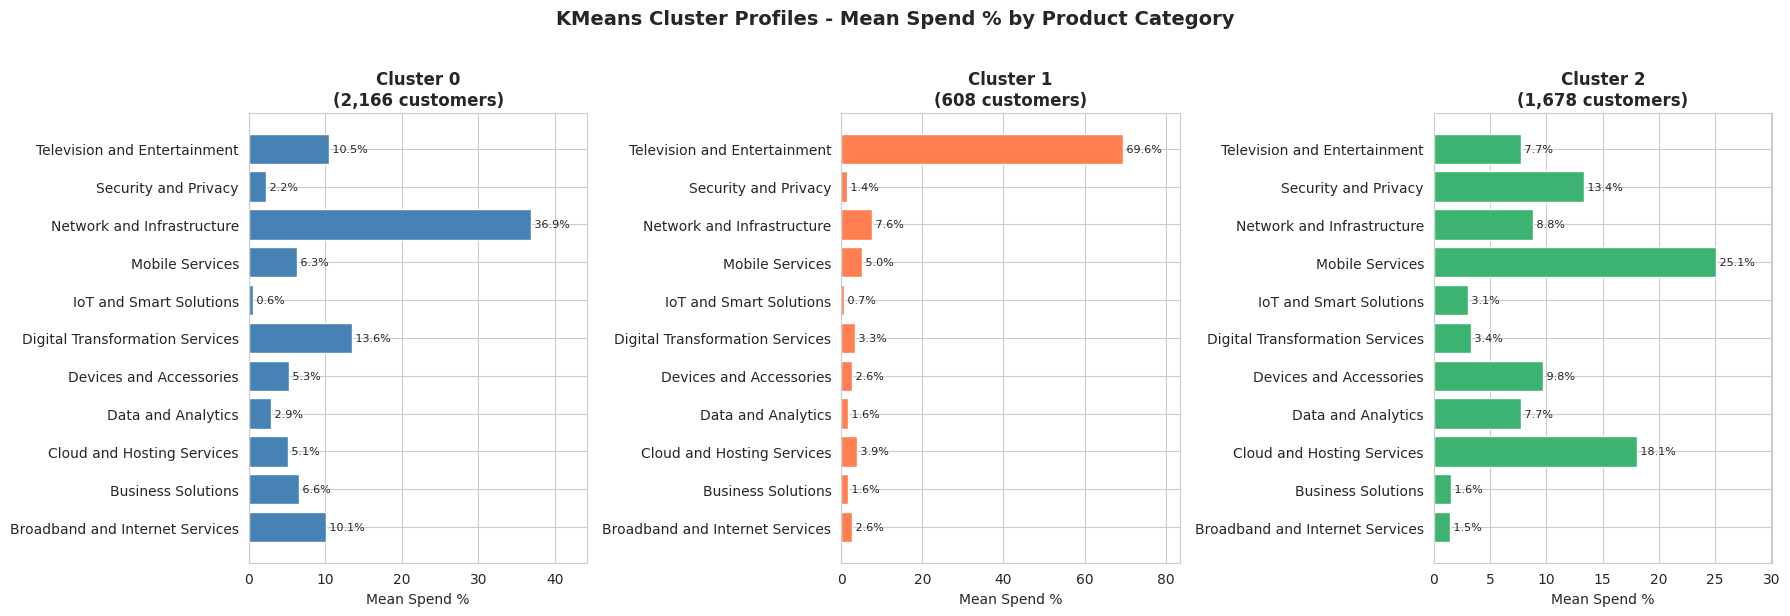

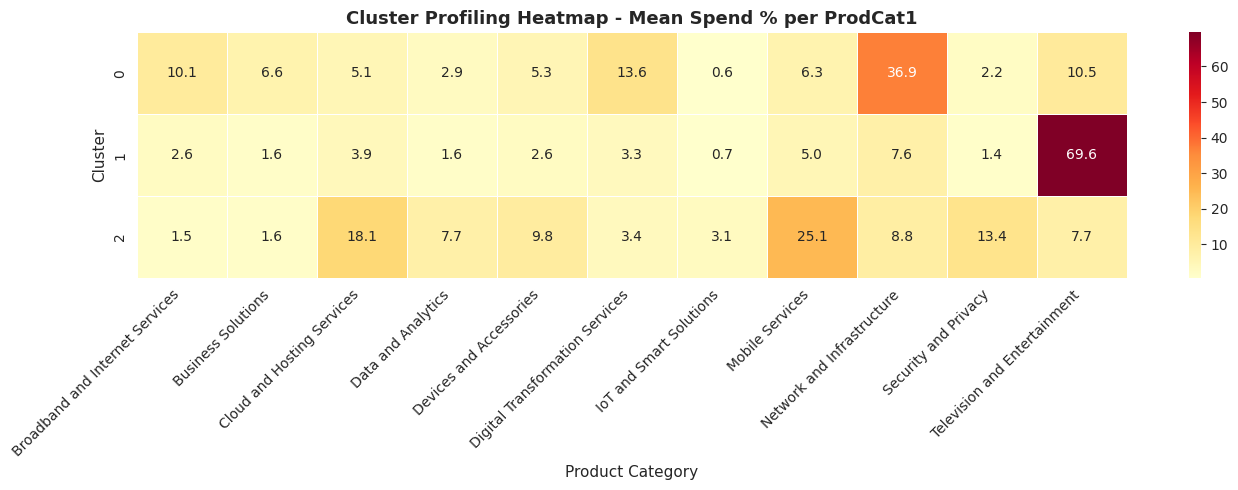


df_pivot with Cluster labels:


,Primary_Key,Broadband and Internet Services,Business Solutions,Cloud and Hosting Services,Data and Analytics,Devices and Accessories,Digital Transformation Services,IoT and Smart Solutions,Mobile Services,Network and Infrastructure,Security and Privacy,Television and Entertainment,Cluster
0,100015_Customer Group_2149,44.25,0.00,0.60,0.00,0.63,19.65,0.00,0.59,23.84,0.00,10.44,0
1,100020_Customer Group_1816,0.00,0.00,23.78,0.00,0.00,0.00,0.00,76.22,0.00,0.00,0.00,2
2,100022_Customer Group_1631,0.00,16.45,5.92,0.00,10.94,0.00,12.84,4.73,9.02,38.89,1.21,2
3,100027_Customer Group_2392,34.30,0.00,1.03,1.42,0.00,0.00,0.00,35.76,4.64,0.00,22.84,0
4,100040_Customer Group_2150,0.00,5.05,4.29,0.00,0.00,0.00,0.00,0.66,89.41,0.00,0.59,0


In [59]:
# ============================================================
# TASK 3.4: Run KMeans with Optimal Number of Clusters (K=3)
# ============================================================

# --- Step 1: Run KMeans with K=3 ---
optimal_k = 3

kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++',
                      max_iter=300, n_init=10, random_state=42)
kmeans_final.fit(df_clustering_scaled)

print(f"✓ KMeans fitted with K={optimal_k}")
print(f"  Iterations to converge : {kmeans_final.n_iter_}")
print(f"  Final WCSS (Inertia)   : {kmeans_final.inertia_:,.2f}")
print(f"  Silhouette Score       : {silhouette_score(df_clustering_scaled, kmeans_final.labels_):.4f}")

# --- Step 2: Assign cluster labels to df_pivot ---
df_pivot['Cluster'] = kmeans_final.labels_
print(f"\n✓ Cluster labels assigned to df_pivot")

# --- Step 3: Assign cluster labels to df_clustering ---
df_clustering['Cluster'] = kmeans_final.labels_
print(f"✓ Cluster labels assigned to df_clustering")

# --- Step 4: Cluster distribution ---
print("\n" + "=" * 60)
print("CLUSTER DISTRIBUTION")
print("=" * 60)
cluster_dist = df_pivot['Cluster'].value_counts().sort_index()
for cluster, count in cluster_dist.items():
    print(f"  Cluster {cluster} : {count:>6,} customers ({count/len(df_pivot)*100:.1f}%)")

# --- Step 5: Cluster profiling - mean spend % per ProdCat1 ---
print("\n" + "=" * 60)
print("CLUSTER PROFILING - Mean Customer Spend % per ProdCat1")
print("=" * 60)
cluster_profile = df_clustering.groupby('Cluster').mean().round(2)
print(cluster_profile.to_string())

# --- Step 6: Visualize cluster profiles ---
fig, axes = plt.subplots(1, optimal_k, figsize=(18, 6), sharey=False)
colors = ['steelblue', 'coral', 'mediumseagreen']

for cluster in range(optimal_k):
    cluster_data = cluster_profile.loc[cluster].drop('Cluster', errors='ignore')
    axes[cluster].barh(cluster_data.index, cluster_data.values,
                       color=colors[cluster], edgecolor='white')
    axes[cluster].set_title(f'Cluster {cluster}\n({cluster_dist[cluster]:,} customers)',
                            fontsize=12, fontweight='bold')
    axes[cluster].set_xlabel('Mean Spend %', fontsize=10)
    axes[cluster].set_xlim(0, cluster_data.values.max() * 1.2)
    for i, val in enumerate(cluster_data.values):
        if val > 0.5:
            axes[cluster].text(val, i, f' {val:.1f}%', va='center', fontsize=8)

plt.suptitle('KMeans Cluster Profiles - Mean Spend % by Product Category',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# --- Step 7: Heatmap of cluster profiles ---
fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(cluster_profile.drop(columns='Cluster', errors='ignore'),
            annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax)
ax.set_title('Cluster Profiling Heatmap - Mean Spend % per ProdCat1',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Product Category', fontsize=11)
ax.set_ylabel('Cluster', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\ndf_pivot with Cluster labels:")
df_pivot.head(5)

***Task 3.5: From the above clusters, create cluster profile***

***Task 3.5.1: Map each customers to their respective cluster in df_segment dataset***

In [60]:
# ============================================================
# TASK 3.5.1: Map cluster labels to df_segment
# ============================================================

# --- Step 1: Extract Primary_Key & Cluster from df_pivot ---
df_cluster_map = df_pivot[['Primary_Key', 'Cluster']].copy()
print(f"✓ Cluster mapping extracted")
print(f"  Shape : {df_cluster_map.shape}")
print(f"  Sample:")
print(df_cluster_map.head(5))

# --- Step 2: Merge cluster labels into df_segment ---
df_segment = pd.merge(
    df_segment,
    df_cluster_map,
    on='Primary_Key',
    how='left'
)

# --- Step 3: Verify ---
print("\n" + "=" * 60)
print("df_segment with Cluster Labels")
print("=" * 60)
print(f"  Shape               : {df_segment.shape}")
print(f"  Columns             : {df_segment.columns.tolist()}")
print(f"  Null Cluster values : {df_segment['Cluster'].isna().sum()}")

print(f"\n  Cluster distribution in df_segment:")
print(df_segment['Cluster'].value_counts().sort_index())

print(f"\n  Cluster distribution by ProdCat1:")
print(df_segment.groupby(['Cluster', 'ProdCat1'])['Customer_Spend%'].mean().round(2).unstack())

print(f"\nFirst 10 rows of df_segment:")
df_segment.head(10)

✓ Cluster mapping extracted
  Shape : (4452, 2)
  Sample:
                  Primary_Key  Cluster
0  100015_Customer Group_2149        0
1  100020_Customer Group_1816        2
2  100022_Customer Group_1631        2
3  100027_Customer Group_2392        0
4  100040_Customer Group_2150        0

df_segment with Cluster Labels
  Shape               : (24634, 5)
  Columns             : ['Primary_Key', 'ProdCat1', 'Gross_Turnover', 'Customer_Spend%', 'Cluster']
  Null Cluster values : 0

  Cluster distribution in df_segment:
Cluster
0    13640
1     2338
2     8656
Name: count, dtype: int64

  Cluster distribution by ProdCat1:
ProdCat1  Broadband and Internet Services  Business Solutions  \
Cluster                                                         
0                                   23.74               14.38   
1                                   13.34                8.40   
2                                    7.71                5.98   

ProdCat1  Cloud and Hosting Services  Data and

,Primary_Key,ProdCat1,Gross_Turnover,Customer_Spend%,Cluster
0,100015_Customer Group_2149,Broadband and Internet Services,9250.04,44.25,0
1,100015_Customer Group_2149,Cloud and Hosting Services,124.69,0.60,0
2,100015_Customer Group_2149,Devices and Accessories,132.17,0.63,0
3,100015_Customer Group_2149,Digital Transformation Services,4106.33,19.65,0
4,100015_Customer Group_2149,Mobile Services,123.71,0.59,0
5,100015_Customer Group_2149,Network and Infrastructure,4982.87,23.84,0
6,100015_Customer Group_2149,Television and Entertainment,2182.68,10.44,0
7,100020_Customer Group_1816,Cloud and Hosting Services,312.20,23.78,2
8,100020_Customer Group_1816,Mobile Services,1000.50,76.22,2
9,100022_Customer Group_1631,Business Solutions,3266.52,16.45,2


***Task 3.5.2: Create a cluster profile table with the cluster label, Gross Turnover for each cluster, Number of unique customers in each cluster, % share of Gross Turnover of each cluster for each product.***

*Illustrative: Here is a snapshot of the desired cluster profile:*
![image-2.png](attachment:image-2.png)

CLUSTER PROFILE TABLE

Shape: (3, 16)

Cluster Summary:
 Cluster  Num_Customers  Customer_Share%  Total_Gross_Turnover  GT_Share%
       0           2166            48.65          501803513.29      66.94
       1            608            13.66           55024542.99       7.34
       2           1678            37.69          192840154.81      25.72

Cluster Spend % by ProdCat1:
 Cluster  Broadband and Internet Services  Business Solutions  Cloud and Hosting Services  Data and Analytics  Devices and Accessories  Digital Transformation Services  IoT and Smart Solutions  Mobile Services  Network and Infrastructure  Security and Privacy  Television and Entertainment
       0                            23.74               14.38                        8.33                5.66                    10.00                            19.81                     2.09             9.50                       42.61                  4.47                         13.68
       1                            13

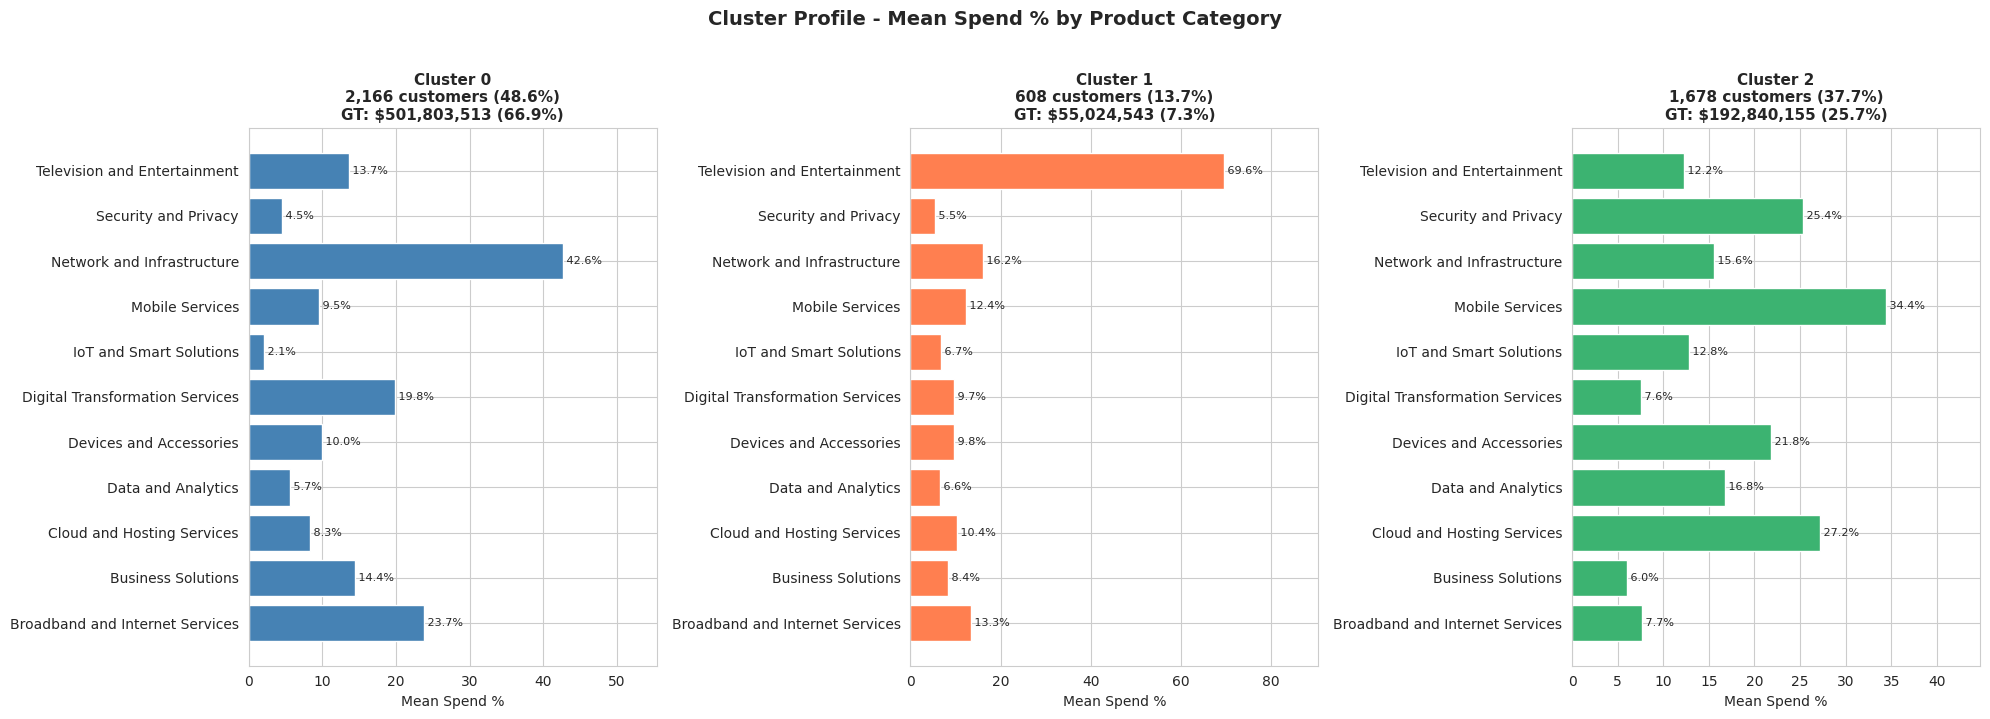

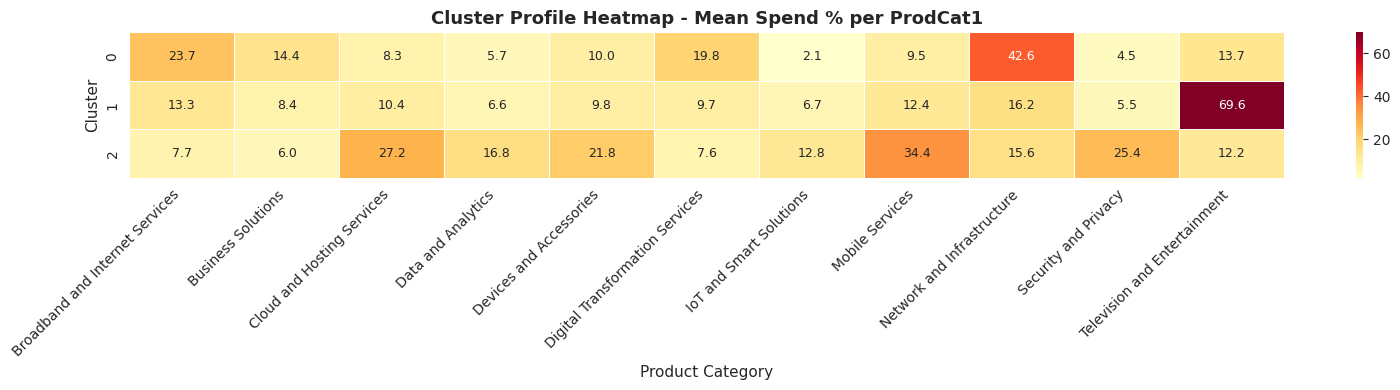


Full df_cluster_profile:


,Cluster,Num_Customers,Customer_Share%,Total_Gross_Turnover,GT_Share%,Broadband and Internet Services,Business Solutions,Cloud and Hosting Services,Data and Analytics,Devices and Accessories,Digital Transformation Services,IoT and Smart Solutions,Mobile Services,Network and Infrastructure,Security and Privacy,Television and Entertainment
0,0,2166,48.65,501803513.29,66.94,23.74,14.38,8.33,5.66,10.00,19.81,2.09,9.50,42.61,4.47,13.68
1,1,608,13.66,55024542.99,7.34,13.34,8.40,10.39,6.57,9.78,9.69,6.72,12.43,16.17,5.50,69.60
2,2,1678,37.69,192840154.81,25.72,7.71,5.98,27.18,16.75,21.84,7.61,12.84,34.40,15.55,25.37,12.22


In [61]:
# ============================================================
# TASK 3.5.2: Create Cluster Profile Table
# ============================================================

# --- Step 1: Gross Turnover per Cluster ---
cluster_gt = (df_segment.groupby('Cluster')['Gross_Turnover']
              .sum()
              .reset_index()
              .rename(columns={'Gross_Turnover': 'Total_Gross_Turnover'}))

# --- Step 2: Number of Unique Customers per Cluster ---
cluster_customers = (df_pivot.groupby('Cluster')['Primary_Key']
                     .nunique()
                     .reset_index()
                     .rename(columns={'Primary_Key': 'Num_Customers'}))

# --- Step 3: Mean Customer Spend % per ProdCat1 per Cluster ---
cluster_spend = (df_segment.groupby(['Cluster', 'ProdCat1'])['Customer_Spend%']
                 .mean()
                 .round(2)
                 .unstack()
                 .reset_index())
cluster_spend.columns.name = None

# --- Step 4: Merge all together ---
df_cluster_profile = pd.merge(cluster_gt, cluster_customers, on='Cluster')
df_cluster_profile = pd.merge(df_cluster_profile, cluster_spend, on='Cluster')

# --- Step 5: Add % share of total Gross Turnover per cluster ---
total_gt = df_cluster_profile['Total_Gross_Turnover'].sum()
df_cluster_profile['GT_Share%'] = (
    df_cluster_profile['Total_Gross_Turnover'] / total_gt * 100
).round(2)

# --- Step 6: Add % share of customers per cluster ---
total_customers = df_cluster_profile['Num_Customers'].sum()
df_cluster_profile['Customer_Share%'] = (
    df_cluster_profile['Num_Customers'] / total_customers * 100
).round(2)

# --- Step 7: Reorder columns ---
prodcat1_cols = sorted([col for col in df_cluster_profile.columns
                        if col not in ['Cluster', 'Total_Gross_Turnover',
                                       'Num_Customers', 'GT_Share%', 'Customer_Share%']])

df_cluster_profile = df_cluster_profile[
    ['Cluster', 'Num_Customers', 'Customer_Share%',
     'Total_Gross_Turnover', 'GT_Share%'] + prodcat1_cols
]

# --- Step 8: Display ---
print("=" * 60)
print("CLUSTER PROFILE TABLE")
print("=" * 60)
print(f"\nShape: {df_cluster_profile.shape}")

print(f"\nCluster Summary:")
print(df_cluster_profile[['Cluster', 'Num_Customers', 'Customer_Share%',
                           'Total_Gross_Turnover', 'GT_Share%']].to_string(index=False))

print(f"\nCluster Spend % by ProdCat1:")
print(df_cluster_profile[['Cluster'] + prodcat1_cols].to_string(index=False))

# --- Step 9: Visualize Cluster Profile ---
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
colors = ['steelblue', 'coral', 'mediumseagreen']
cluster_labels = {0: 'Cluster 0', 1: 'Cluster 1', 2: 'Cluster 2'}

for i, cluster in enumerate([0, 1, 2]):
    row = df_cluster_profile[df_cluster_profile['Cluster'] == cluster].iloc[0]
    spend_vals = row[prodcat1_cols]

    bars = axes[i].barh(prodcat1_cols, spend_vals.values,
                        color=colors[i], edgecolor='white')
    axes[i].set_title(
        f'Cluster {cluster}\n'
        f'{int(row["Num_Customers"]):,} customers ({row["Customer_Share%"]:.1f}%)\n'
        f'GT: ${row["Total_Gross_Turnover"]:,.0f} ({row["GT_Share%"]:.1f}%)',
        fontsize=11, fontweight='bold'
    )
    axes[i].set_xlabel('Mean Spend %', fontsize=10)
    axes[i].set_xlim(0, max(spend_vals.values) * 1.3)
    for bar, val in zip(bars, spend_vals.values):
        if val > 0.5:
            axes[i].text(val, bar.get_y() + bar.get_height()/2,
                         f' {val:.1f}%', va='center', fontsize=8)

plt.suptitle('Cluster Profile - Mean Spend % by Product Category',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# --- Step 10: Heatmap ---
fig, ax = plt.subplots(figsize=(16, 4))
heatmap_data = df_cluster_profile.set_index('Cluster')[prodcat1_cols]
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Cluster Profile Heatmap - Mean Spend % per ProdCat1',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Product Category', fontsize=11)
ax.set_ylabel('Cluster', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nFull df_cluster_profile:")
df_cluster_profile

### 4. Prepare data for Tableau Dashboard

From here, you will be creating the visualizations in Tableau. But before, creating the required visualizations in Tableau, you should prepare the data.

Here is a reference of how data for visualizations for **Customer Segmentation** looks like:

![image-5.png](attachment:image-5.png)






Here is a reference of how data for visualizations for **Product Categorization** looks like:

![image-4.png](attachment:image-4.png)

where:

- Product ID: SKU ID
- Gross Turnover (sum), Amount (sum), Invoice_count (distinct count of invoices), Main_account_count (distinct count of main accounts): fields aggregated at SKU level
- Above columns with _percluster: fields aggregated at cluster level
- Frequency (%) : number of transactions the SKU appeared on, when compared to all transactions in a cluster
- Customer Prevalence (%) within cluster : Percentage of customers within a cluster who purchase the SKU



In [62]:
# ============================================================
# TASK 4: Prepare & Export Data for Tableau Dashboard
# ============================================================

# ============================================================
# PART A: Customer Segmentation Table
# ============================================================

print("Building Customer Segmentation table...")

# --- Step 1: Base aggregation at Main_Account_ID level ---
df_customer_seg = df_Filtered_Pareto.groupby(
    ['Main_Account_ID', 'Main_Account_Name', 'Customer_type', 'Company_Status']
).agg(
    Gross_Turnover     = ('Gross_Turnover', 'sum'),
    Amount             = ('Amount',         'sum'),
    Invoice_count      = ('Invoice_Number', 'nunique'),
    Main_account_count = ('Main_Account_ID','nunique'),
    SKU_count          = ('Product_ID',     'nunique')
).reset_index()

# --- Step 2: Map Cluster labels ---
df_cluster_map = df_pivot[['Primary_Key', 'Cluster']].copy()
df_cluster_map['Main_Account_ID'] = df_cluster_map['Primary_Key'].str.split('_').str[0]

df_customer_seg = pd.merge(
    df_customer_seg,
    df_cluster_map[['Main_Account_ID', 'Cluster']],
    on='Main_Account_ID', how='left'
)

# --- Step 3: Cluster-level aggregates ---
cluster_agg = df_customer_seg.groupby('Cluster').agg(
    Gross_Turnover_percluster     = ('Gross_Turnover',     'sum'),
    Amount_percluster             = ('Amount',             'sum'),
    Invoice_count_percluster      = ('Invoice_count',      'sum'),
    Customer_count_percluster     = ('Main_Account_ID', 'nunique')
).reset_index()

df_customer_seg = pd.merge(df_customer_seg, cluster_agg, on='Cluster', how='left')

# --- Step 4: GT share % within cluster ---
df_customer_seg['GT_share%_incluster'] = (
    df_customer_seg['Gross_Turnover'] /
    df_customer_seg['Gross_Turnover_percluster'] * 100
).round(2)

# --- Step 5: Add cluster spend % per ProdCat1 ---
df_customer_seg = pd.merge(
    df_customer_seg,
    df_cluster_profile[['Cluster'] + prodcat1_cols],
    on='Cluster', how='left'
)

# --- Step 6: Add cluster name label ---
df_customer_seg['Cluster_Label'] = df_customer_seg['Cluster'].map({
    0: 'Network Focus',
    1: 'TV Focus',
    2: 'Cloud & Mobile'
})

print(f"✓ df_customer_seg shape : {df_customer_seg.shape}")
print(f"  Columns: {df_customer_seg.columns.tolist()}")
print(f"\n  Cluster distribution:")
print(df_customer_seg['Cluster'].value_counts().sort_index())
df_customer_seg.head(3)

Building Customer Segmentation table...
✓ df_customer_seg shape : (3732, 27)
  Columns: ['Main_Account_ID', 'Main_Account_Name', 'Customer_type', 'Company_Status', 'Gross_Turnover', 'Amount', 'Invoice_count', 'Main_account_count', 'SKU_count', 'Cluster', 'Gross_Turnover_percluster', 'Amount_percluster', 'Invoice_count_percluster', 'Customer_count_percluster', 'GT_share%_incluster', 'Broadband and Internet Services', 'Business Solutions', 'Cloud and Hosting Services', 'Data and Analytics', 'Devices and Accessories', 'Digital Transformation Services', 'IoT and Smart Solutions', 'Mobile Services', 'Network and Infrastructure', 'Security and Privacy', 'Television and Entertainment', 'Cluster_Label']

  Cluster distribution:
Cluster
0    1887
1     439
2    1406
Name: count, dtype: int64


,Main_Account_ID,Main_Account_Name,Customer_type,Company_Status,Gross_Turnover,Amount,Invoice_count,Main_account_count,SKU_count,Cluster,...,Cloud and Hosting Services,Data and Analytics,Devices and Accessories,Digital Transformation Services,IoT and Smart Solutions,Mobile Services,Network and Infrastructure,Security and Privacy,Television and Entertainment,Cluster_Label
0,100015,Customer Group_2149,C,Normal,20902.49,765,15,1,28,0,...,8.33,5.66,10.00,19.81,2.09,9.50,42.61,4.47,13.68,Network Focus
1,100022,Customer Group_1631,A-B,Normal,19854.41,2185,23,1,54,2,...,27.18,16.75,21.84,7.61,12.84,34.40,15.55,25.37,12.22,Cloud & Mobile
2,100027,Customer Group_2392,D,Active,45232.89,529,9,1,37,0,...,8.33,5.66,10.00,19.81,2.09,9.50,42.61,4.47,13.68,Network Focus


In [63]:
# ============================================================
# PART B: Product Categorization Table
# ============================================================

print("Building Product Categorization table...")

# --- Step 1: Map cluster to df_Filtered_Pareto ---
df_fp_clustered = pd.merge(
    df_Filtered_Pareto,
    df_cluster_map[['Main_Account_ID', 'Cluster']],
    on='Main_Account_ID', how='left'
)

# --- Step 2: SKU level aggregates OVERALL ---
df_sku_overall = df_fp_clustered.groupby('Product_ID').agg(
    Gross_Turnover     = ('Gross_Turnover', 'sum'),
    Amount             = ('Amount',         'sum'),
    Invoice_count      = ('Invoice_Number', 'nunique'),
    Main_account_count = ('Main_Account_ID','nunique')
).reset_index()

# --- Step 3: SKU level aggregates PER CLUSTER ---
df_sku_cluster = df_fp_clustered.groupby(['Product_ID', 'Cluster']).agg(
    Gross_Turnover_percluster     = ('Gross_Turnover', 'sum'),
    Amount_percluster             = ('Amount',         'sum'),
    Invoice_count_percluster      = ('Invoice_Number', 'nunique'),
    Main_account_count_percluster = ('Main_Account_ID','nunique'),
    Txn_count_percluster          = ('Invoice_Number', 'count')
).reset_index()

# --- Step 4: Total txn & customers per cluster ---
cluster_txn_total = (df_fp_clustered.groupby('Cluster')['Invoice_Number']
                     .count().reset_index()
                     .rename(columns={'Invoice_Number': 'Total_Txn_percluster'}))

cluster_cust_total = (df_fp_clustered.groupby('Cluster')['Main_Account_ID']
                      .nunique().reset_index()
                      .rename(columns={'Main_Account_ID': 'Total_Cust_percluster'}))

df_sku_cluster = pd.merge(df_sku_cluster, cluster_txn_total,  on='Cluster', how='left')
df_sku_cluster = pd.merge(df_sku_cluster, cluster_cust_total, on='Cluster', how='left')

# --- Step 5: Frequency % & Customer Prevalence % ---
df_sku_cluster['Frequency(%)'] = (
    df_sku_cluster['Txn_count_percluster'] /
    df_sku_cluster['Total_Txn_percluster'] * 100
).round(4)

df_sku_cluster['Customer_Prevalence(%)_within_cluster'] = (
    df_sku_cluster['Main_account_count_percluster'] /
    df_sku_cluster['Total_Cust_percluster'] * 100
).round(4)

# --- Step 6: Merge overall + per cluster ---
df_product_cat = pd.merge(df_sku_overall, df_sku_cluster, on='Product_ID', how='left')

# --- Step 7: Add product category info ---
prod_info = (df_Filtered_Pareto[['Product_ID', 'ProdCat1', 'ProdCat2', 'Product_Category_ID']]
             .drop_duplicates(subset='Product_ID'))
df_product_cat = pd.merge(df_product_cat, prod_info, on='Product_ID', how='left')

# --- Step 8: Add cluster name label ---
df_product_cat['Cluster_Label'] = df_product_cat['Cluster'].map({
    0: 'Network Focus',
    1: 'TV Focus',
    2: 'Cloud & Mobile'
})

print(f"✓ df_product_cat shape : {df_product_cat.shape}")
print(f"  Columns: {df_product_cat.columns.tolist()}")
print(f"\n  Cluster distribution:")
print(df_product_cat['Cluster'].value_counts().sort_index())
df_product_cat.head(3)

Building Product Categorization table...
✓ df_product_cat shape : (106802, 19)
  Columns: ['Product_ID', 'Gross_Turnover', 'Amount', 'Invoice_count', 'Main_account_count', 'Cluster', 'Gross_Turnover_percluster', 'Amount_percluster', 'Invoice_count_percluster', 'Main_account_count_percluster', 'Txn_count_percluster', 'Total_Txn_percluster', 'Total_Cust_percluster', 'Frequency(%)', 'Customer_Prevalence(%)_within_cluster', 'ProdCat1', 'ProdCat2', 'Product_Category_ID', 'Cluster_Label']

  Cluster distribution:
Cluster
0    58793
1    14208
2    33801
Name: count, dtype: int64


,Product_ID,Gross_Turnover,Amount,Invoice_count,Main_account_count,Cluster,Gross_Turnover_percluster,Amount_percluster,Invoice_count_percluster,Main_account_count_percluster,Txn_count_percluster,Total_Txn_percluster,Total_Cust_percluster,Frequency(%),Customer_Prevalence(%)_within_cluster,ProdCat1,ProdCat2,Product_Category_ID,Cluster_Label
0,1,71.70,4,2,2,2,71.70,4,2,2,2,156253,1678,0.00,0.12,Data and Analytics,Data Analytics Services,676.00,Cloud & Mobile
1,1000,11480.11,800,23,19,0,9568.63,664,18,15,18,454552,2166,0.00,0.69,Data and Analytics,Data Analytics Services,676.00,Network Focus
2,1000,11480.11,800,23,19,1,1017.41,76,2,2,2,42105,608,0.00,0.33,Data and Analytics,Data Analytics Services,676.00,TV Focus


In [64]:
# ============================================================
# PART C: Validate before export
# ============================================================

print("=" * 60)
print("VALIDATION BEFORE EXPORT")
print("=" * 60)

# Customer Segmentation checks
print(f"\nCustomer Segmentation Table:")
print(f"  Rows                     : {df_customer_seg.shape[0]:>10,}")
print(f"  Unique customers         : {df_customer_seg['Main_Account_ID'].nunique():>10,}")
print(f"  Total Gross Turnover     : ${df_customer_seg['Gross_Turnover'].sum():>14,.2f}")
print(f"  Null Cluster             : {df_customer_seg['Cluster'].isna().sum():>10,}")
print(f"  Cluster distribution:")
for c, n in df_customer_seg['Cluster'].value_counts().sort_index().items():
    print(f"    Cluster {c} ({df_customer_seg[df_customer_seg['Cluster']==c]['Cluster_Label'].iloc[0]}): {n:,} customers")

# Product Categorization checks
print(f"\nProduct Categorization Table:")
print(f"  Rows                     : {df_product_cat.shape[0]:>10,}")
print(f"  Unique SKUs              : {df_product_cat['Product_ID'].nunique():>10,}")
print(f"  Total Gross Turnover     : ${df_product_cat['Gross_Turnover'].sum():>14,.2f}")
print(f"  Null Cluster             : {df_product_cat['Cluster'].isna().sum():>10,}")
print(f"  Frequency% range         : {df_product_cat['Frequency(%)'].min():.4f}% - {df_product_cat['Frequency(%)'].max():.4f}%")
print(f"  Cust Prevalence% range   : {df_product_cat['Customer_Prevalence(%)_within_cluster'].min():.4f}% - {df_product_cat['Customer_Prevalence(%)_within_cluster'].max():.4f}%")

VALIDATION BEFORE EXPORT

Customer Segmentation Table:
  Rows                     :      3,732
  Unique customers         :      3,730
  Total Gross Turnover     : $726,480,368.45
  Null Cluster             :          0
  Cluster distribution:
    Cluster 0 (Network Focus): 1,887 customers
    Cluster 1 (TV Focus): 439 customers
    Cluster 2 (Cloud & Mobile): 1,406 customers

Product Categorization Table:
  Rows                     :    106,802
  Unique SKUs              :     67,926
  Total Gross Turnover     : $1,559,864,279.03
  Null Cluster             :          0
  Frequency% range         : 0.0002% - 0.5368%
  Cust Prevalence% range   : 0.0462% - 18.3749%


In [65]:
# ============================================================
# PART D: Export for Tableau
# ============================================================
from google.colab import files

# Save
df_customer_seg.to_csv('Customer_Segmentation_Tableau.csv', index=False)
df_product_cat.to_csv('Product_Categorization_Tableau.csv',  index=False)

print("=" * 60)
print("FILES EXPORTED")
print("=" * 60)
print(f"✓ Customer_Segmentation_Tableau.csv  : {df_customer_seg.shape}")
print(f"✓ Product_Categorization_Tableau.csv : {df_product_cat.shape}")

# Download
files.download('Customer_Segmentation_Tableau.csv')
files.download('Product_Categorization_Tableau.csv')
print("\n✓ Both files ready to import into Tableau!")

FILES EXPORTED
✓ Customer_Segmentation_Tableau.csv  : (3732, 27)
✓ Product_Categorization_Tableau.csv : (106802, 19)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✓ Both files ready to import into Tableau!


Upload Customer_Segmentation_Tableau.csv


Saving Customer_Segmentation_Tableau.csv to Customer_Segmentation_Tableau (1).csv
✓ Loaded: (3732, 27)


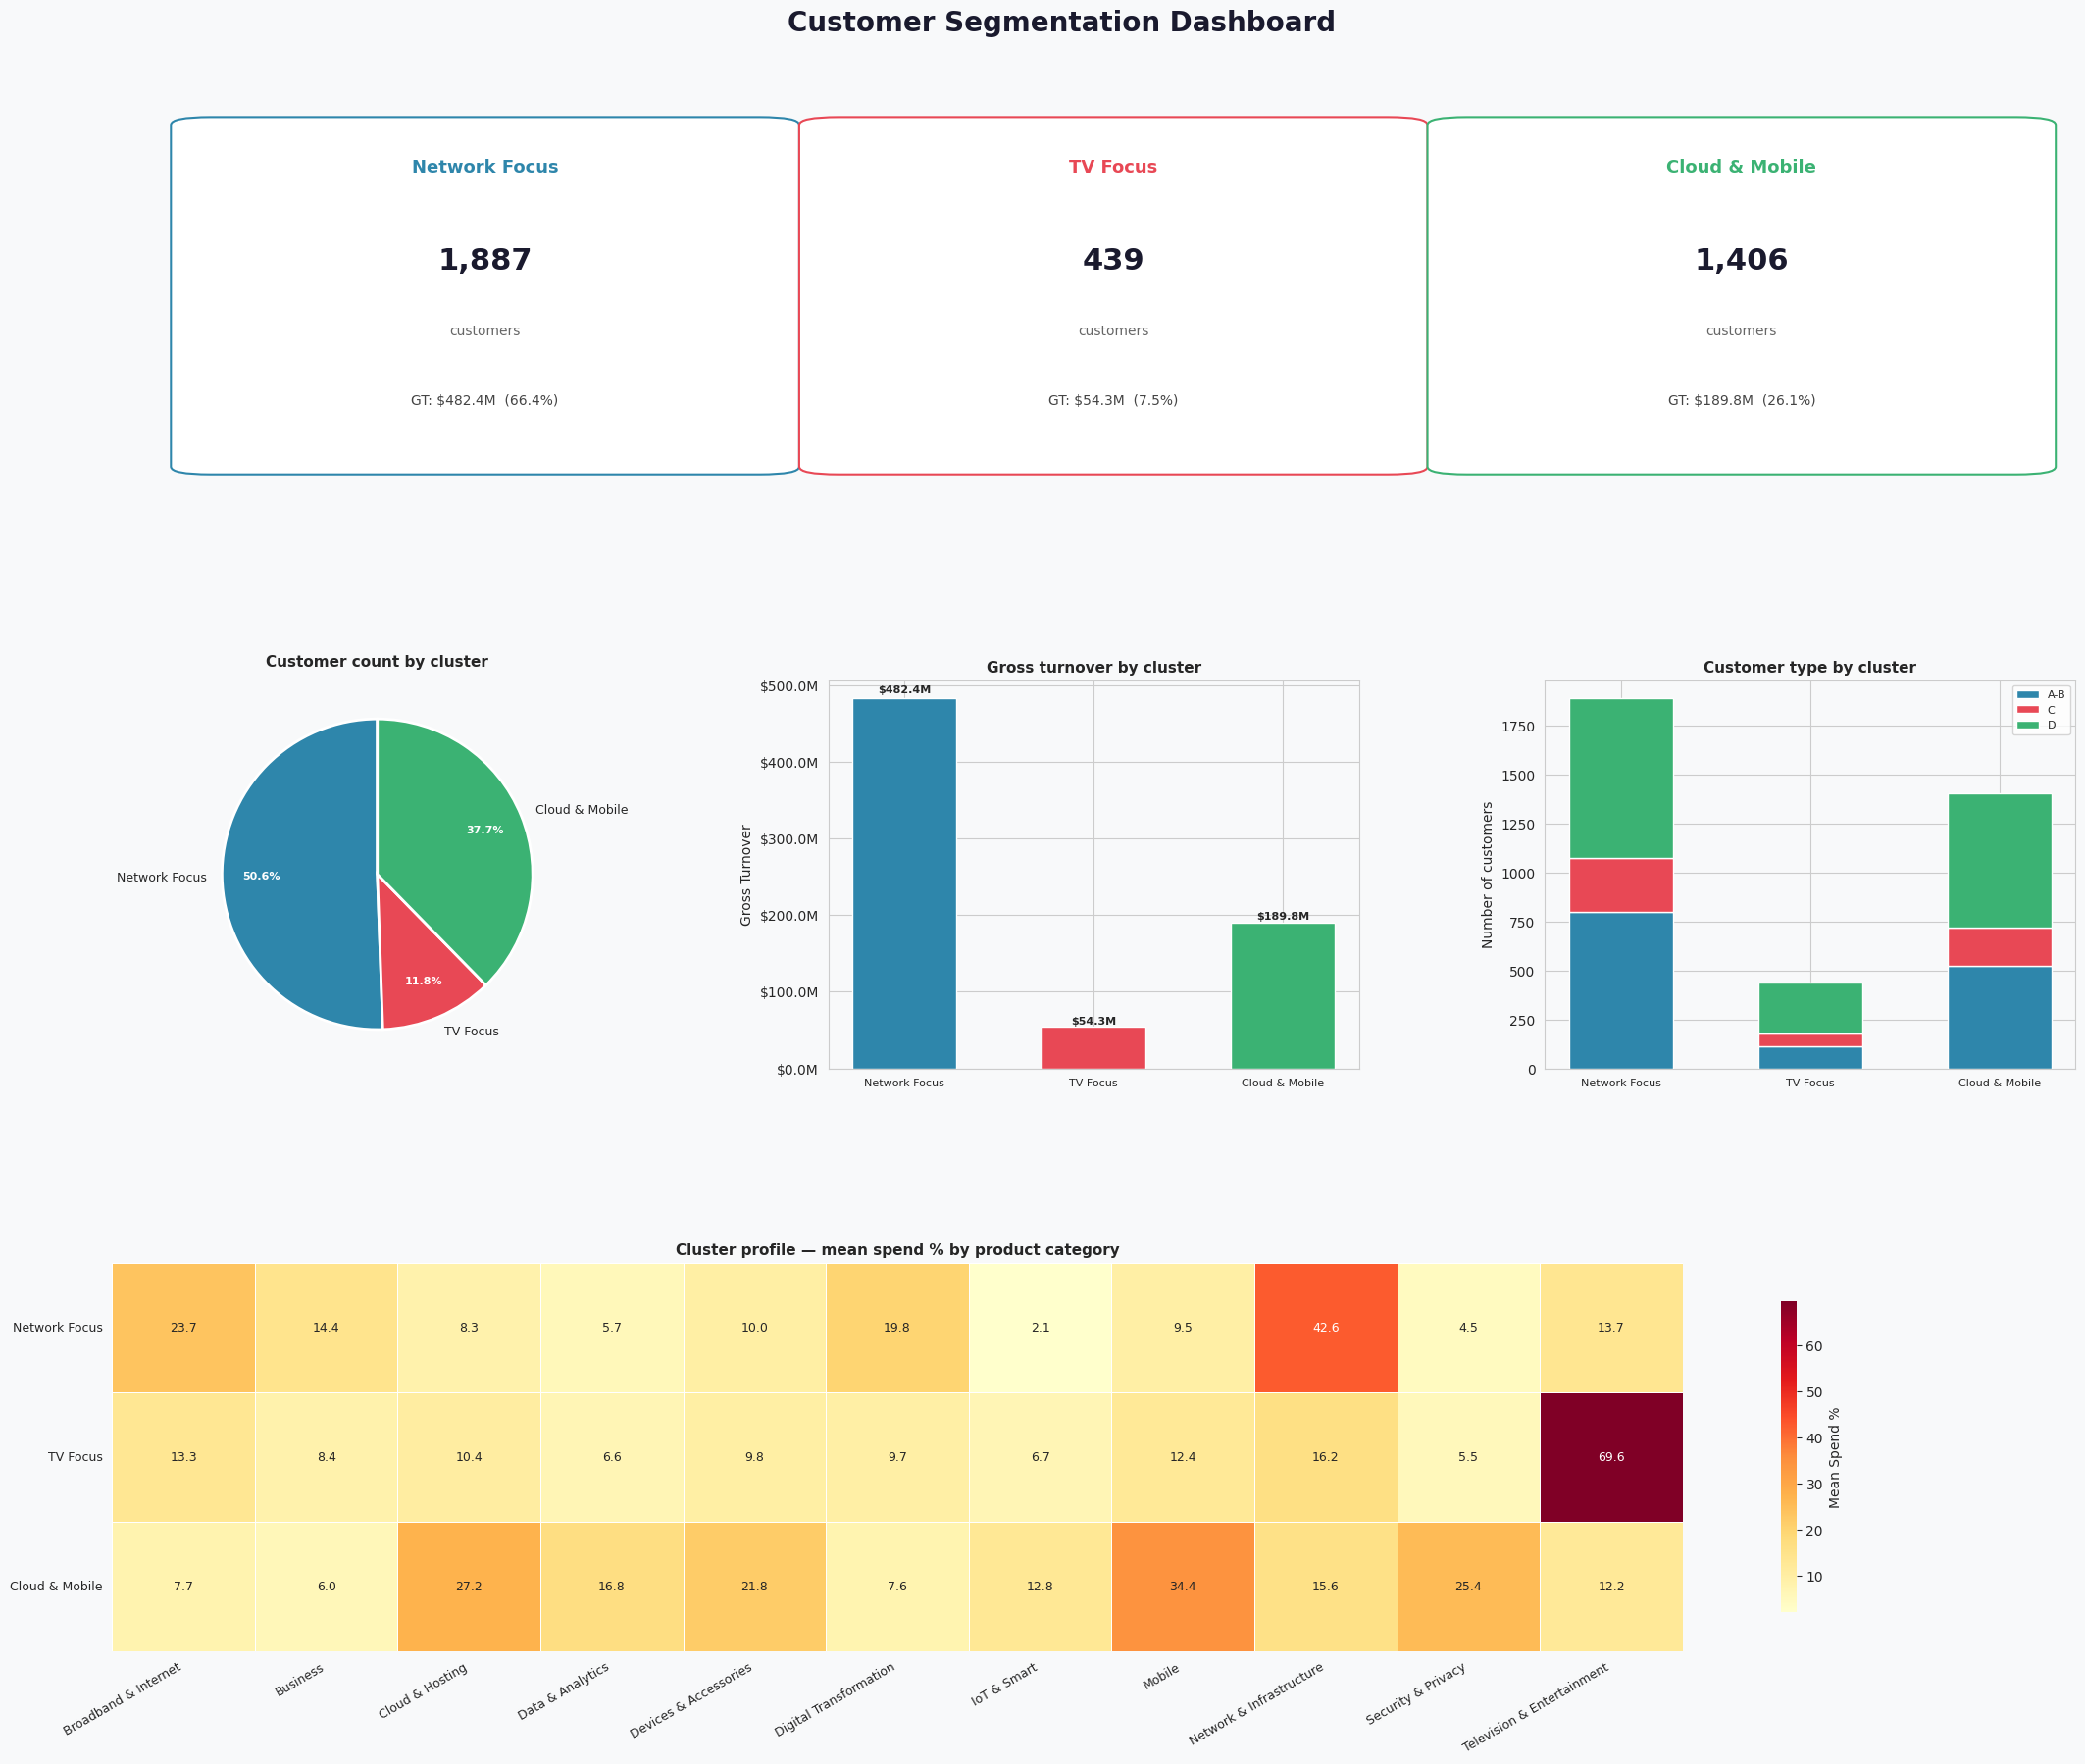

✓ Customer Segmentation Dashboard complete!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [66]:
# ============================================================
# DASHBOARD 1: CUSTOMER SEGMENTATION
# Run this cell in Google Colab
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from google.colab import files

# --- Upload Customer Segmentation CSV ---
print("Upload Customer_Segmentation_Tableau.csv")
uploaded_cs = files.upload()
cs_fname = list(uploaded_cs.keys())[0]
df_cs = pd.read_csv(cs_fname)
print(f"✓ Loaded: {df_cs.shape}")

# --- Settings ---
colors       = {'Network Focus': '#2E86AB', 'TV Focus': '#E84855', 'Cloud & Mobile': '#3BB273'}
cluster_order = ['Network Focus', 'TV Focus', 'Cloud & Mobile']
prodcat1_cols = ['Broadband and Internet Services','Business Solutions',
                 'Cloud and Hosting Services','Data and Analytics',
                 'Devices and Accessories','Digital Transformation Services',
                 'IoT and Smart Solutions','Mobile Services',
                 'Network and Infrastructure','Security and Privacy',
                 'Television and Entertainment']
short_cols = [c.replace(' and ',' & ').replace(' Services','').replace(' Solutions','')
              for c in prodcat1_cols]

def millions(x, pos): return f'${x/1e6:.1f}M'

# ============================================================
# Build Dashboard
# ============================================================
fig = plt.figure(figsize=(22, 18), facecolor='#F8F9FA')
fig.suptitle('Customer Segmentation Dashboard',
             fontsize=20, fontweight='bold', y=0.98, color='#1a1a2e')
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.35,
                       top=0.93, bottom=0.05, left=0.06, right=0.97)

# --- KPI Cards ---
ax_kpi = fig.add_subplot(gs[0, :])
ax_kpi.axis('off')
kpi_data = df_cs.groupby('Cluster_Label').agg(
    Customers = ('Main_Account_ID', 'count'),
    GT        = ('Gross_Turnover',  'sum')
).reindex(cluster_order)
kpi_data['GT_Share']   = kpi_data['GT']        / kpi_data['GT'].sum()        * 100
kpi_data['Cust_Share'] = kpi_data['Customers'] / kpi_data['Customers'].sum() * 100

for i, (cluster, row) in enumerate(kpi_data.iterrows()):
    x = 0.05 + i * 0.32
    rect = mpatches.FancyBboxPatch((x, 0.05), 0.28, 0.88,
        boxstyle="round,pad=0.02", linewidth=1.5,
        edgecolor=colors[cluster], facecolor='white',
        transform=ax_kpi.transAxes, zorder=2)
    ax_kpi.add_patch(rect)
    ax_kpi.text(x+0.14, 0.82, cluster, ha='center', va='center',
               fontsize=13, fontweight='bold', color=colors[cluster],
               transform=ax_kpi.transAxes)
    ax_kpi.text(x+0.14, 0.58, f"{int(row['Customers']):,}", ha='center', va='center',
               fontsize=22, fontweight='bold', color='#1a1a2e',
               transform=ax_kpi.transAxes)
    ax_kpi.text(x+0.14, 0.40, 'customers', ha='center', va='center',
               fontsize=10, color='#666', transform=ax_kpi.transAxes)
    ax_kpi.text(x+0.14, 0.22,
               f"GT: ${row['GT']/1e6:.1f}M  ({row['GT_Share']:.1f}%)",
               ha='center', va='center', fontsize=10,
               color='#444', transform=ax_kpi.transAxes)

# --- Chart 1: Customer Count Pie ---
ax1 = fig.add_subplot(gs[1, 0])
counts = df_cs['Cluster_Label'].value_counts().reindex(cluster_order)
wedge_colors = [colors[c] for c in counts.index]
wedges, texts, autotexts = ax1.pie(
    counts.values, labels=counts.index, autopct='%1.1f%%',
    colors=wedge_colors, startangle=90, pctdistance=0.75,
    textprops={'fontsize': 9},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2})
for at in autotexts:
    at.set_fontsize(8); at.set_color('white'); at.set_fontweight('bold')
ax1.set_title('Customer count by cluster', fontsize=11, fontweight='bold', pad=10)

# --- Chart 2: GT by Cluster Bar ---
ax2 = fig.add_subplot(gs[1, 1])
gt_cluster  = df_cs.groupby('Cluster_Label')['Gross_Turnover'].sum().reindex(cluster_order)
bar_colors  = [colors[c] for c in gt_cluster.index]
bars = ax2.bar(range(len(gt_cluster)), gt_cluster.values,
               color=bar_colors, edgecolor='white', width=0.55)
ax2.set_xticks(range(len(gt_cluster)))
ax2.set_xticklabels(gt_cluster.index, fontsize=8)
ax2.set_title('Gross turnover by cluster', fontsize=11, fontweight='bold')
ax2.set_ylabel('Gross Turnover')
ax2.yaxis.set_major_formatter(FuncFormatter(millions))
ax2.set_facecolor('#F8F9FA')
for bar, val in zip(bars, gt_cluster.values):
    ax2.text(bar.get_x()+bar.get_width()/2, val*1.01,
             f'${val/1e6:.1f}M', ha='center', va='bottom',
             fontsize=8, fontweight='bold')

# --- Chart 3: Customer Type Stacked Bar ---
ax3 = fig.add_subplot(gs[1, 2])
ct = (df_cs.groupby(['Cluster_Label','Customer_type'])
      .size().unstack(fill_value=0).reindex(cluster_order))
ct_colors = ['#2E86AB', '#E84855', '#3BB273']
bottom    = np.zeros(len(ct))
for i, col in enumerate(ct.columns):
    ax3.bar(range(len(ct)), ct[col].values, bottom=bottom,
            label=col, color=ct_colors[i], edgecolor='white', width=0.55)
    bottom += ct[col].values
ax3.set_xticks(range(len(ct)))
ax3.set_xticklabels(ct.index, fontsize=8)
ax3.set_title('Customer type by cluster', fontsize=11, fontweight='bold')
ax3.set_ylabel('Number of customers')
ax3.legend(fontsize=8, loc='upper right')
ax3.set_facecolor('#F8F9FA')

# --- Chart 4: Heatmap Cluster vs ProdCat1 ---
ax4 = fig.add_subplot(gs[2, :])
hmap = (df_cs.groupby('Cluster_Label')[prodcat1_cols]
        .mean().round(1).reindex(cluster_order))
hmap.columns = short_cols
sns.heatmap(hmap, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax4,
            linewidths=0.5, annot_kws={'size': 9},
            cbar_kws={'label': 'Mean Spend %', 'shrink': 0.8})
ax4.set_title('Cluster profile — mean spend % by product category',
              fontsize=11, fontweight='bold')
ax4.set_xlabel(''); ax4.set_ylabel('')
plt.setp(ax4.get_xticklabels(), rotation=30, ha='right', fontsize=9)
plt.setp(ax4.get_yticklabels(), rotation=0, fontsize=9)

plt.savefig('Customer_Segmentation_Dashboard.png', bbox_inches='tight',
            dpi=150, facecolor='#F8F9FA')
plt.show()
print("✓ Customer Segmentation Dashboard complete!")
files.download('Customer_Segmentation_Dashboard.png')

Upload Product_Categorization_Tableau.csv


Saving Product_Categorization_Tableau.csv to Product_Categorization_Tableau (1).csv
✓ Loaded: (106802, 19)


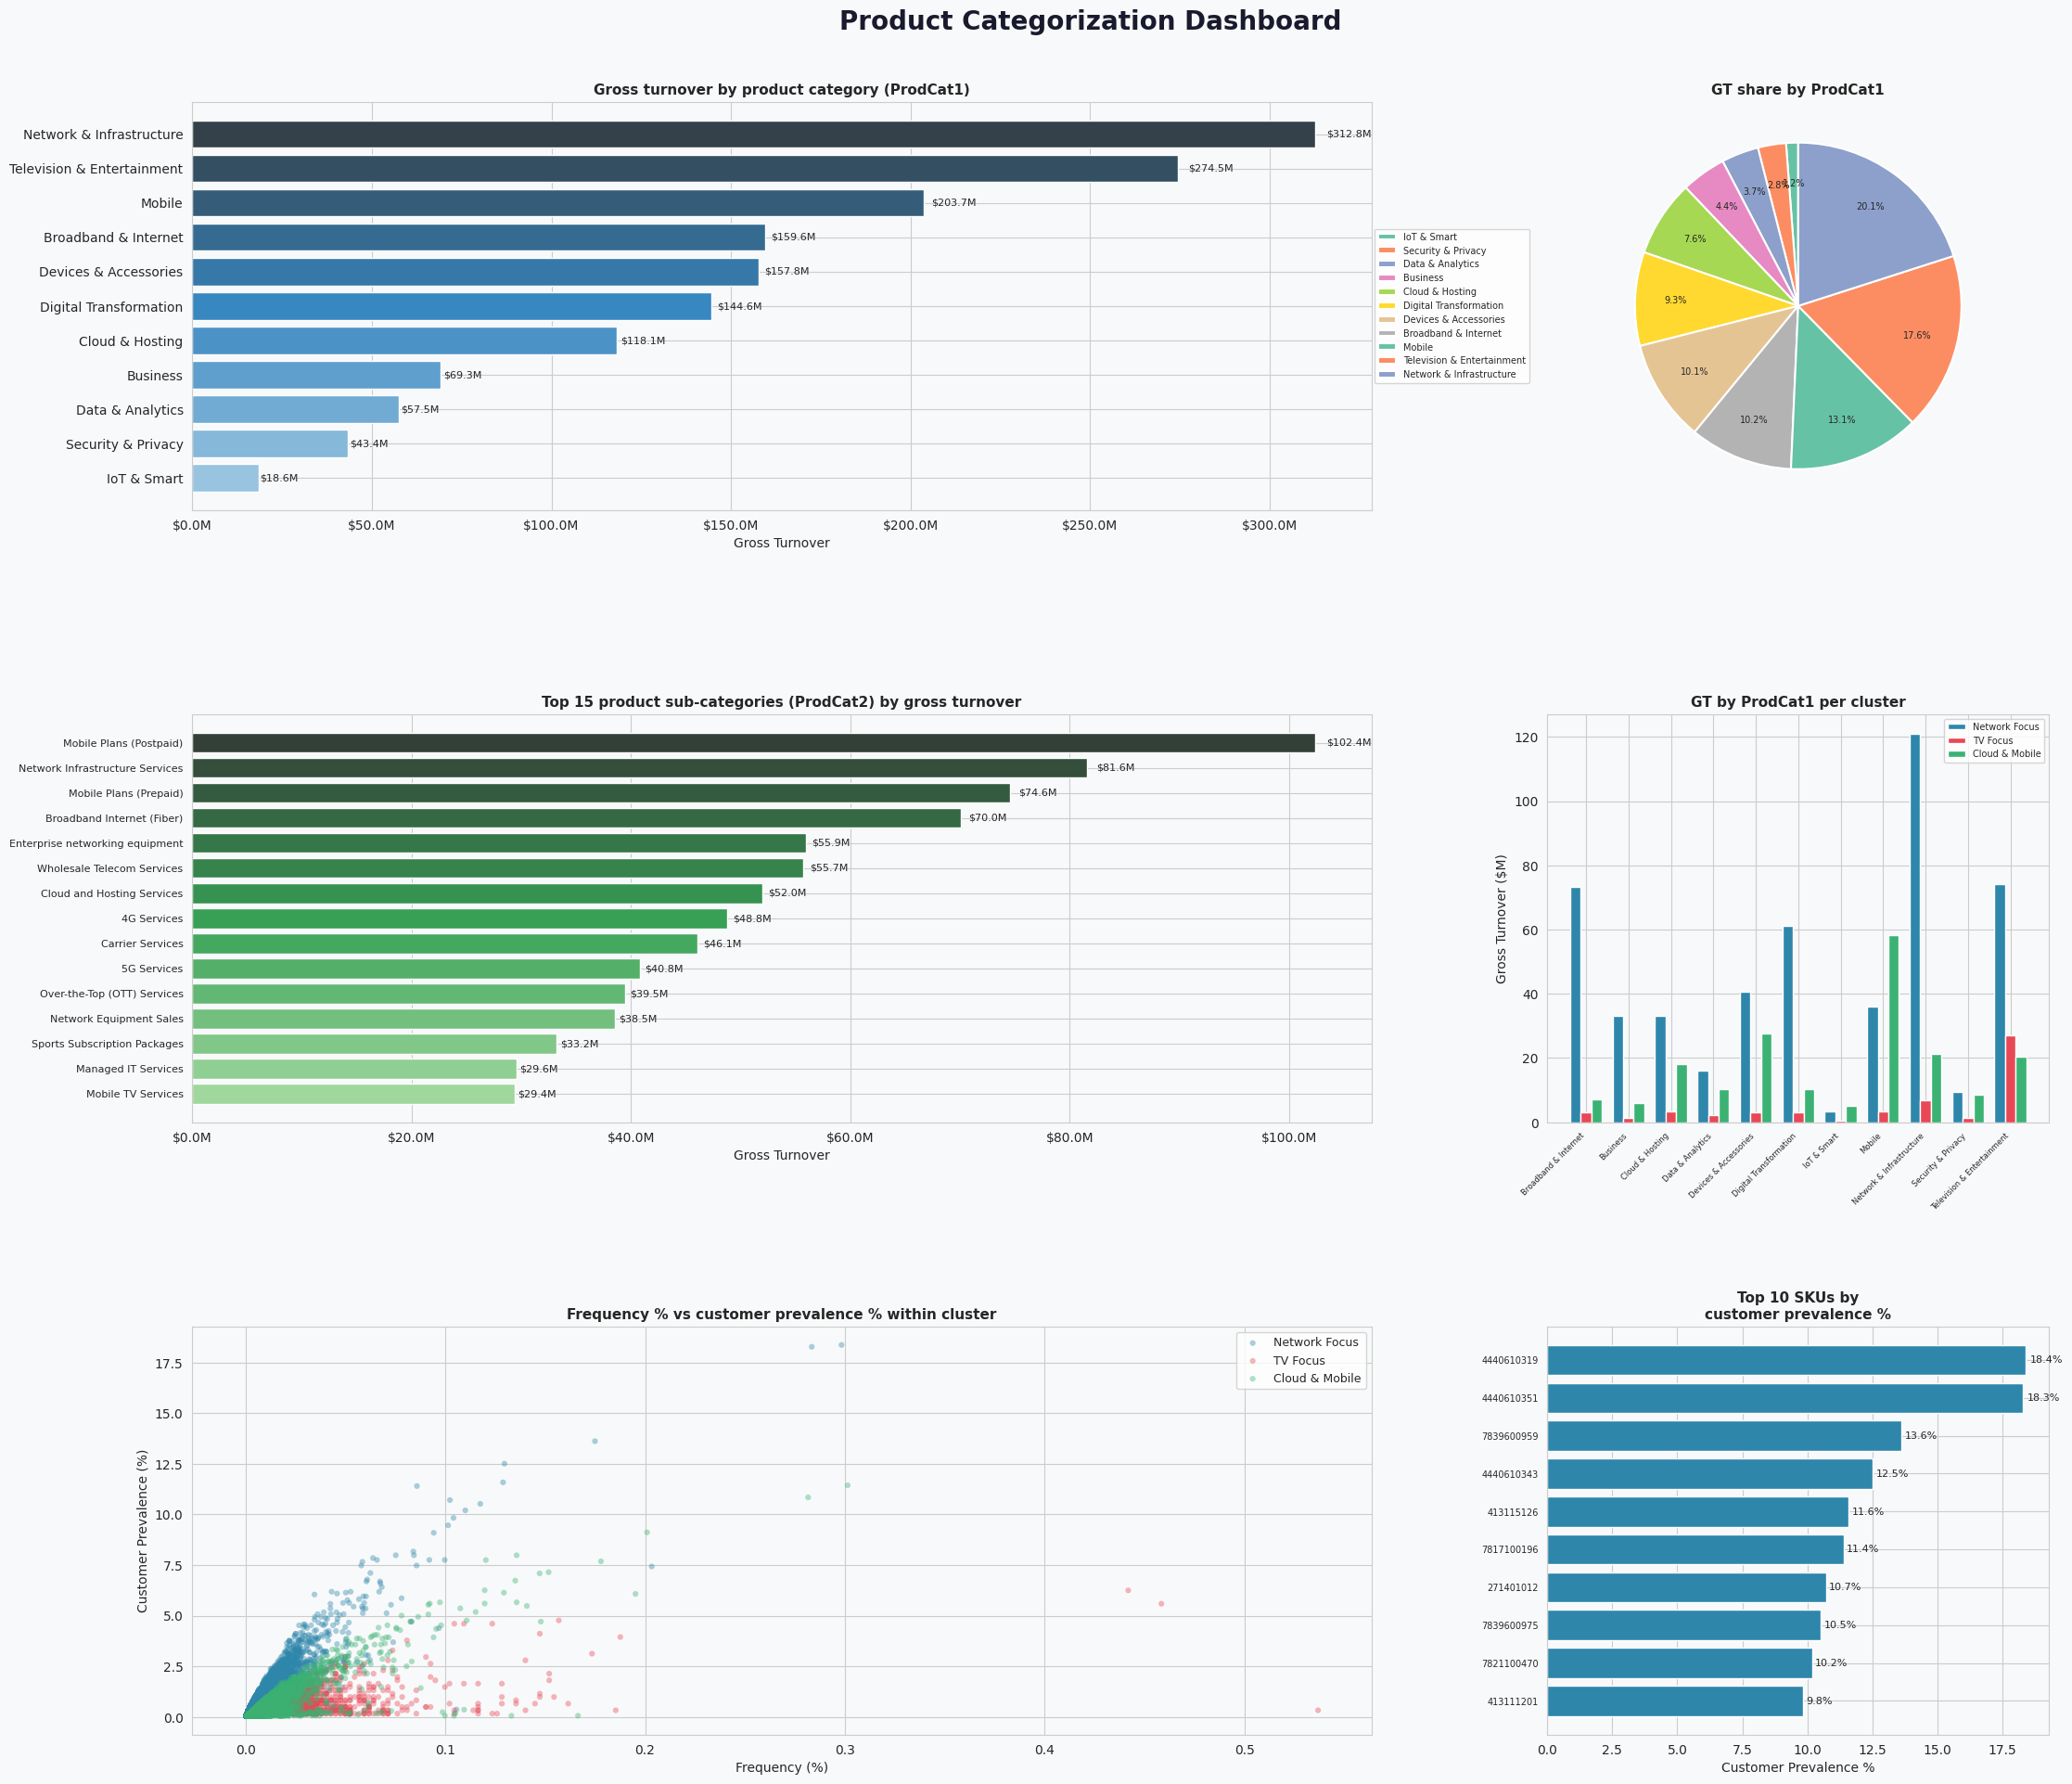

✓ Product Categorization Dashboard complete!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [67]:
# ============================================================
# DASHBOARD 2: PRODUCT CATEGORIZATION
# Run this cell in Google Colab
# ============================================================

# --- Upload Product Categorization CSV ---
print("Upload Product_Categorization_Tableau.csv")
uploaded_pc = files.upload()
pc_fname = list(uploaded_pc.keys())[0]
df_pc = pd.read_csv(pc_fname, low_memory=False)
print(f"✓ Loaded: {df_pc.shape}")

# ============================================================
# Build Dashboard
# ============================================================
fig2 = plt.figure(figsize=(22, 20), facecolor='#F8F9FA')
fig2.suptitle('Product Categorization Dashboard',
              fontsize=20, fontweight='bold', y=0.98, color='#1a1a2e')
gs2 = gridspec.GridSpec(3, 3, figure=fig2, hspace=0.5, wspace=0.35,
                        top=0.93, bottom=0.05, left=0.06, right=0.97)

def shorten(name):
    return (name.replace(' and ',' & ')
                .replace(' Services','')
                .replace(' Solutions',''))

# --- Chart 1: GT by ProdCat1 Horizontal Bar ---
ax1 = fig2.add_subplot(gs2[0, :2])
prodcat1_gt = df_pc.groupby('ProdCat1')['Gross_Turnover'].sum().sort_values()
short_names = [shorten(c) for c in prodcat1_gt.index]
bar_pal     = sns.color_palette('Blues_d', len(prodcat1_gt))
bars = ax1.barh(short_names, prodcat1_gt.values, color=bar_pal, edgecolor='white')
ax1.set_title('Gross turnover by product category (ProdCat1)',
              fontsize=11, fontweight='bold')
ax1.set_xlabel('Gross Turnover')
ax1.xaxis.set_major_formatter(FuncFormatter(millions))
ax1.set_facecolor('#F8F9FA')
for bar, val in zip(bars, prodcat1_gt.values):
    ax1.text(val*1.01, bar.get_y()+bar.get_height()/2,
             f'${val/1e6:.1f}M', va='center', fontsize=8)

# --- Chart 2: GT by ProdCat1 Pie ---
ax2 = fig2.add_subplot(gs2[0, 2])
pie_colors = sns.color_palette('Set2', len(prodcat1_gt))
wedges, texts, autotexts = ax2.pie(
    prodcat1_gt.values, labels=None, autopct='%1.1f%%',
    colors=pie_colors, startangle=90, pctdistance=0.75,
    wedgeprops={'edgecolor':'white','linewidth':1.5})
for at in autotexts: at.set_fontsize(7)
ax2.legend(short_names, loc='center left',
           bbox_to_anchor=(-0.55, 0.5), fontsize=7)
ax2.set_title('GT share by ProdCat1', fontsize=11, fontweight='bold')

# --- Chart 3: Top 15 ProdCat2 by GT ---
ax3 = fig2.add_subplot(gs2[1, :2])
top15    = df_pc.groupby('ProdCat2')['Gross_Turnover'].sum().nlargest(15).sort_values()
bar_pal2 = sns.color_palette('Greens_d', len(top15))
bars = ax3.barh(top15.index, top15.values, color=bar_pal2, edgecolor='white')
ax3.set_title('Top 15 product sub-categories (ProdCat2) by gross turnover',
              fontsize=11, fontweight='bold')
ax3.set_xlabel('Gross Turnover')
ax3.xaxis.set_major_formatter(FuncFormatter(millions))
ax3.tick_params(axis='y', labelsize=8)
ax3.set_facecolor('#F8F9FA')
for bar, val in zip(bars, top15.values):
    ax3.text(val*1.01, bar.get_y()+bar.get_height()/2,
             f'${val/1e6:.1f}M', va='center', fontsize=8)

# --- Chart 4: GT per ProdCat1 per Cluster Grouped Bar ---
ax4 = fig2.add_subplot(gs2[1, 2])
pc1_cluster = (df_pc.groupby(['ProdCat1','Cluster_Label'])['Gross_Turnover_percluster']
               .sum().unstack(fill_value=0)[cluster_order])
short_p = [shorten(c) for c in pc1_cluster.index]
x, w    = np.arange(len(pc1_cluster)), 0.25
for i, cluster in enumerate(cluster_order):
    ax4.bar(x + i*w, pc1_cluster[cluster].values/1e6,
            width=w, label=cluster, color=colors[cluster], edgecolor='white')
ax4.set_xticks(x + w)
ax4.set_xticklabels(short_p, rotation=45, ha='right', fontsize=6)
ax4.set_title('GT by ProdCat1 per cluster', fontsize=11, fontweight='bold')
ax4.set_ylabel('Gross Turnover ($M)')
ax4.legend(fontsize=7, loc='upper right')
ax4.set_facecolor('#F8F9FA')

# --- Chart 5: Frequency % vs Customer Prevalence % Scatter ---
ax5 = fig2.add_subplot(gs2[2, :2])
sample = df_pc[df_pc['Gross_Turnover'] > 0].copy()
for cluster in cluster_order:
    sub = sample[sample['Cluster_Label'] == cluster]
    ax5.scatter(sub['Frequency(%)'],
                sub['Customer_Prevalence(%)_within_cluster'],
                c=colors[cluster], label=cluster,
                alpha=0.4, s=20, edgecolors='none')
ax5.set_title('Frequency % vs customer prevalence % within cluster',
              fontsize=11, fontweight='bold')
ax5.set_xlabel('Frequency (%)')
ax5.set_ylabel('Customer Prevalence (%)')
ax5.legend(fontsize=9)
ax5.set_facecolor('#F8F9FA')

# --- Chart 6: Top 10 SKUs by Customer Prevalence % ---
ax6 = fig2.add_subplot(gs2[2, 2])
top_prev = (df_pc.groupby('Product_ID')['Customer_Prevalence(%)_within_cluster']
            .max().nlargest(10).sort_values())
ax6.barh(top_prev.index.astype(str), top_prev.values,
         color='#2E86AB', edgecolor='white')
ax6.set_title('Top 10 SKUs by\ncustomer prevalence %',
              fontsize=11, fontweight='bold')
ax6.set_xlabel('Customer Prevalence %')
ax6.tick_params(axis='y', labelsize=7)
ax6.set_facecolor('#F8F9FA')
for i, val in enumerate(top_prev.values):
    ax6.text(val*1.01, i, f'{val:.1f}%', va='center', fontsize=8)

plt.savefig('Product_Categorization_Dashboard.png', bbox_inches='tight',
            dpi=150, facecolor='#F8F9FA')
plt.show()
print("✓ Product Categorization Dashboard complete!")
files.download('Product_Categorization_Dashboard.png')

***The End***